# ADI/CV-Based Sequential Training for Hybrid Forecasting Models

This notebook reads a sales CSV or Excel file, classifies each product using **ADI / CV² demand classification**, then trains the correct hybrid forecasting model:

- `ARIMA + XGBoost` for `SMOOTH` and `ERRATIC` demand
- `TSB + XGBoost` for `INTERMITTENT` and `LUMPY` demand

Training schedule used in this notebook:
- `ARIMA` and `TSB` use **rolling walk-forward epochs** because they are statistical time-series models, not neural networks
- The notebook evaluates up to the last `12` monthly observations per product as the recommended walk-forward window for these models
- `XGBoost` training rounds are taken from the actual model configuration via `n_estimators`
- Current configured XGBoost rounds in this project are `200` for the initial fit and `400` for the retraining/extended setup

Recommended metric priority for training accuracy:
- Primary: sequential walk-forward holdout `WAPE`, because it is scale-normalized and remains usable when individual months have zero demand
- Secondary: `MAE` for unit-level error, `RMSE` for large-error sensitivity, and `sMAPE` for percentage-style comparison across intermittent/lumpy series
- Supporting only: `MAPE`, because it ignores zero-actual months and can explode on very small demand values
- Demand/no-demand diagnostics: confusion-matrix accuracy, precision, recall, and F1; treat MLogLoss as diagnostic only unless demand probabilities are calibrated

Parameter conclusion for the current saved run:
- The initial parameters are a reasonable default, but they are not universally ideal
- This notebook imports `train_model`, so saved artifacts use the initial parameter setup unless alternate grids/params are explicitly passed
- ARIMA+XGB product mean WAPE was `31.17` with the initial setup versus `33.93` with the extended/regularized setup; initial remains the safer default, although some smooth parts improved under the extended setup
- TSB+XGB product mean WAPE was nearly tied: `105.90` initial versus `105.34` extended/regularized; extended helped one lumpy item but worsened most intermittent/lumpy items, so tune per series instead of treating either setup as globally ideal

In [13]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve().parents[1]
PYTHON_ROOT = PROJECT_ROOT / "python"
MODELS_DIR = PYTHON_ROOT / "models"
UTILS_DIR = PYTHON_ROOT / "utils"
OUTPUT_DIR = PYTHON_ROOT / "trained_models"
TRAINED_MODELS_DIR = PYTHON_ROOT / "trained_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAINED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

for path in [MODELS_DIR, UTILS_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from arima_xgb_model import train_model as train_arima_xgb, save_trained_model as save_arima_xgb_model
from arima_xgb_model import forecast_from_artifact as forecast_arima_xgb
from arima_xgb_model import XGB_PARAMS_INITIAL as ARIMA_XGB_PARAMS_INITIAL, XGB_PARAMS_RETRAIN as ARIMA_XGB_PARAMS_RETRAIN
from arima_xgb_model import ARIMA_ORDERS_INITIAL, ARIMA_ORDERS_EXTENDED
from tsb_xgb_model import train_model as train_tsb_xgb, save_trained_model as save_tsb_xgb_model
from tsb_xgb_model import forecast_from_artifact as forecast_tsb_xgb
from tsb_xgb_model import XGB_PARAMS_INITIAL as TSB_XGB_PARAMS_INITIAL, XGB_PARAMS_RETRAIN as TSB_XGB_PARAMS_RETRAIN
from tsb_xgb_model import ALPHA_GRID_INITIAL, BETA_GRID_INITIAL, ALPHA_GRID_EXTENDED, BETA_GRID_EXTENDED
from demand_classifier import classify

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
METRIC_COLUMNS = ["RMSE", "MSE", "MAE", "MAPE"]
LOG_LOSS_COLUMN = "LogLoss"

## Configure Data Source

Point these settings to your sales file. If `TARGET_PRODUCTS = None`, the notebook will classify and train **all products** found in the file.

In [14]:
DATA_PATH = PROJECT_ROOT / "python" / "data" / "revised_sales_2.csv"
SHEET_NAME = 0

DATE_COLUMN = "reportDate"
QUANTITY_COLUMN = "quantity"
PRODUCT_COLUMN = "productName"
TOTAL_AMOUNT_COLUMN = "totalAmount"

TARGET_PRODUCTS = None
INCLUDE_BUSINESS_REVENUE = True
BUSINESS_ID = 1
BUSINESS_REVENUE_NAME = "Business Total Revenue"
BUSINESS_REVENUE_ARTIFACT_NAME = "monthly_total_revenue"

# Example: TARGET_PRODUCTS = ["Brake Pad", "Oil Filter"]

MIN_TRAIN_SIZE = 12
MAX_WALK_FORWARD_EPOCHS = 12
FORECAST_HORIZON = 6
TOP_PRODUCTS_TO_PLOT = 5

# Rolling-window candidates for sequential validation. None means use all available history.
# Shorter windows help erratic/intermittent/lumpy series adapt to recent demand shifts.
TRAINING_WINDOW_CANDIDATES_BY_DEMAND_TYPE = {
    "SMOOTH": [None, 48, 36, 24],
    "ERRATIC": [None, 48, 36, 24, 18],
    "INTERMITTENT": [None, 36, 24, 18, 12],
    "LUMPY": [None, 36, 24, 18, 12],
}
TRAINING_WINDOW_CANDIDATES_BY_SERIES_KIND = {
    "business_revenue": [None, 48, 36, 24],
}
WINDOW_SELECTION_METRIC = "WAPE"
WINDOW_SELECTION_TIEBREAKERS = ["MAPE", "RMSE"]

DATA_PATH

WindowsPath('C:/Users/Joem Inciong/automotive-spare-parts-dss-thesis/autoparts-backend/python/data/revised_sales_2.csv')

In [15]:
def slugify_name(value):
    slug = re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")
    return slug or "forecast_model"

def recommended_walk_forward_epochs(n_observations, min_train_size=12, max_walk_forward_epochs=12):
    available = max(0, int(n_observations) - int(min_train_size))
    return max(1, min(available, int(max_walk_forward_epochs)))

def load_sales_data(data_path, sheet_name=0):
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Sales data file not found: {data_path}")

    if data_path.suffix.lower() == ".csv":
        df = pd.read_csv(data_path)
    elif data_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(data_path, sheet_name=sheet_name)
    else:
        raise ValueError("DATA_PATH must be a CSV or Excel file.")

    required_columns = [DATE_COLUMN, QUANTITY_COLUMN, PRODUCT_COLUMN]
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    working = df.copy()
    if TARGET_PRODUCTS is not None:
        target_set = {str(item) for item in TARGET_PRODUCTS}
        working = working[working[PRODUCT_COLUMN].astype(str).isin(target_set)]

    if working.empty:
        raise ValueError("No sales rows matched the current product filter.")

    working[DATE_COLUMN] = pd.to_datetime(working[DATE_COLUMN])
    working[QUANTITY_COLUMN] = pd.to_numeric(working[QUANTITY_COLUMN], errors="coerce").fillna(0.0)
    working[PRODUCT_COLUMN] = working[PRODUCT_COLUMN].astype(str).str.strip()
    working["period"] = working[DATE_COLUMN].dt.to_period("M")

    monthly = (
        working.groupby([PRODUCT_COLUMN, "period"], as_index=False)[QUANTITY_COLUMN]
        .sum()
        .sort_values([PRODUCT_COLUMN, "period"])
        .reset_index(drop=True)
    )

    monthly["period_str"] = monthly["period"].astype(str)
    monthly[QUANTITY_COLUMN] = monthly[QUANTITY_COLUMN].astype(float)
    return monthly


def load_business_revenue_series(data_path, sheet_name=0):
    data_path = Path(data_path)
    if data_path.suffix.lower() == ".csv":
        df = pd.read_csv(data_path)
    elif data_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(data_path, sheet_name=sheet_name)
    else:
        raise ValueError("DATA_PATH must be a CSV or Excel file.")

    required_columns = [DATE_COLUMN, TOTAL_AMOUNT_COLUMN]
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for company revenue: {missing}")

    working = df.copy()
    working[DATE_COLUMN] = pd.to_datetime(working[DATE_COLUMN])
    working[TOTAL_AMOUNT_COLUMN] = pd.to_numeric(working[TOTAL_AMOUNT_COLUMN], errors="coerce").fillna(0.0)
    working["period"] = working[DATE_COLUMN].dt.to_period("M")

    revenue = (
        working.groupby("period", as_index=False)[TOTAL_AMOUNT_COLUMN]
        .sum()
        .sort_values("period")
        .reset_index(drop=True)
    )

    revenue[PRODUCT_COLUMN] = BUSINESS_REVENUE_NAME
    revenue[QUANTITY_COLUMN] = revenue[TOTAL_AMOUNT_COLUMN].astype(float)
    revenue["period_str"] = revenue["period"].astype(str)
    return revenue[[PRODUCT_COLUMN, "period", QUANTITY_COLUMN, "period_str", TOTAL_AMOUNT_COLUMN]]


def compute_log_loss(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    valid_mask = np.isfinite(actual) & np.isfinite(predicted)
    if not np.any(valid_mask):
        return np.nan

    actual = np.clip(actual[valid_mask], 0.0, None)
    predicted = np.clip(predicted[valid_mask], 0.0, None)
    return float(np.mean(np.square(np.log1p(actual) - np.log1p(predicted))))


def compute_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted

    mse = float(np.mean(np.square(errors)))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(errors)))
    log_loss = compute_log_loss(actual, predicted)

    non_zero_mask = actual != 0
    if np.any(non_zero_mask):
        mape = float(np.mean(np.abs(errors[non_zero_mask] / actual[non_zero_mask])) * 100)
    else:
        mape = np.nan

    # sMAPE
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0
    valid_smape = denominator != 0
    if np.any(valid_smape):
        smape = float(np.mean(np.abs(errors[valid_smape]) / denominator[valid_smape]) * 100)
    else:
        smape = 0.0

    # WAPE
    actual_sum = np.sum(np.abs(actual))
    if actual_sum != 0:
        wape = float(np.sum(np.abs(errors)) / actual_sum * 100)
    else:
        wape = np.nan

    return {"RMSE": rmse, "MSE": mse, "MAE": mae, "MAPE": mape, "sMAPE": smape, "WAPE": wape, LOG_LOSS_COLUMN: log_loss}


def summarize_epochs(epoch_frame, product_name, model_name, demand_type, adi, cv2, saved_model_path, walk_forward_epochs, xgb_rounds_initial, xgb_rounds_retrain, selected_training_window=None, training_window_candidates=None):
    metrics = compute_metrics(epoch_frame["actual"], epoch_frame["predicted"])
    avg_training_log_loss = epoch_frame["training_log_loss"].mean() if "training_log_loss" in epoch_frame.columns else np.nan
    return {
        "product_name": product_name,
        "algorithm": model_name,
        "demand_type": demand_type,
        "adi": adi,
        "cv2": cv2,
        "walk_forward_epochs": int(walk_forward_epochs),
        "xgb_rounds_initial": int(xgb_rounds_initial),
        "xgb_rounds_retrain": int(xgb_rounds_retrain),
        "selected_training_window": training_window_label(selected_training_window) if selected_training_window is not None else "All History",
        "epochs": int(len(epoch_frame)),
        "avg_train_size": float(epoch_frame["train_size"].mean()),
        "avg_training_log_loss": float(avg_training_log_loss) if pd.notna(avg_training_log_loss) else np.nan,
        "saved_model_path": str(saved_model_path),
        **metrics,
    }


def build_epoch_metric_frame(epoch_frame):
    rows = []
    for end_index in range(1, len(epoch_frame) + 1):
        metrics = compute_metrics(
            epoch_frame["actual"].iloc[:end_index],
            epoch_frame["predicted"].iloc[:end_index],
        )
        rows.append({
            "epoch": int(epoch_frame["epoch"].iloc[end_index - 1]),
            **metrics,
        })
    return pd.DataFrame(rows)


def _build_residual_feature_frame(residuals, lag_features, rolling_windows):
    df = pd.DataFrame({"v": pd.Series(residuals, dtype=float)})
    for lag in lag_features:
        df[f"lag_{lag}"] = df["v"].shift(lag)
    for window in rolling_windows:
        df[f"rmean_{window}"] = df["v"].shift(1).rolling(window).mean()
        df[f"rstd_{window}"] = df["v"].shift(1).rolling(window).std()
    df = df.dropna()
    return df, [column for column in df.columns if column != "v"]


def _run_tsb_fitted(series, alpha, beta):
    series = np.asarray(series, dtype=float)
    n = len(series)
    z = np.zeros(n)
    p = np.zeros(n)
    non_zero_values = [value for value in series if value > 0]
    z[0] = non_zero_values[0] if non_zero_values else 1.0
    p[0] = len(non_zero_values) / n if n else 0.0
    for t in range(1, n):
        if series[t] > 0:
            z[t] = alpha * series[t] + (1 - alpha) * z[t - 1]
            p[t] = beta + (1 - beta) * p[t - 1]
        else:
            z[t] = z[t - 1]
            p[t] = (1 - beta) * p[t - 1]
    return p * z


def get_artifact_fitted_values(artifact):
    values = np.asarray(artifact.get("series_values", []), dtype=float)
    if values.size == 0:
        return values

    algorithm = artifact.get("algorithm") or artifact.get("meta", {}).get("algorithm")
    lag_features = artifact.get("lag_features") or [1, 2, 3, 6, 12]
    rolling_windows = artifact.get("rolling_windows") or [3, 6]

    if algorithm == "ARIMA_XGB" and artifact.get("arima_result") is not None:
        arima_fitted = np.asarray(artifact["arima_result"].fittedvalues, dtype=float)
        fitted = np.resize(arima_fitted, values.shape).astype(float)
        residuals = values - fitted
    elif algorithm == "TSB_XGB":
        fitted = _run_tsb_fitted(values, float(artifact.get("tsb_alpha", 0.1)), float(artifact.get("tsb_beta", 0.1)))
        residuals = values - fitted
    else:
        fitted = pd.Series(values).shift(1).bfill().fillna(0).to_numpy(dtype=float)
        residuals = values - fitted

    model = artifact.get("xgb_model")
    scaler = artifact.get("xgb_scaler")
    if artifact.get("xgb_enabled") and model is not None and scaler is not None:
        feature_frame, default_feature_columns = _build_residual_feature_frame(residuals, lag_features, rolling_windows)
        feature_columns = artifact.get("feature_columns") or default_feature_columns
        if not feature_frame.empty and all(column in feature_frame.columns for column in feature_columns):
            xgb_predictions = model.predict(scaler.transform(feature_frame[feature_columns]))
            for prediction, original_index in zip(xgb_predictions, feature_frame.index):
                index = int(original_index)
                if 0 <= index < len(fitted):
                    fitted[index] += float(prediction)

    return np.clip(fitted, 0.0, None)


def compute_artifact_training_metrics(artifact):
    values = np.asarray(artifact.get("series_values", []), dtype=float)
    if values.size == 0:
        return {"RMSE": np.nan, "MSE": np.nan, "MAE": np.nan, "MAPE": np.nan, "sMAPE": np.nan, "WAPE": np.nan, LOG_LOSS_COLUMN: np.nan}
    fitted_values = get_artifact_fitted_values(artifact)
    return compute_metrics(values, fitted_values)


def compute_artifact_training_log_loss(artifact):
    return compute_artifact_training_metrics(artifact).get(LOG_LOSS_COLUMN, np.nan)


def run_sequential_epochs(dates, quantities, train_fn, forecast_fn, min_train_size=12, test_size=None, training_window=None):
    test_size = int(test_size or recommended_walk_forward_epochs(len(dates), min_train_size=min_train_size, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS))
    if len(dates) <= min_train_size:
        raise ValueError(f"Need more than {min_train_size} monthly observations.")

    rows = []
    test_start = len(dates) - test_size

    for epoch_index, target_index in enumerate(range(test_start, len(dates)), start=1):
        if training_window is None:
            train_dates = dates[:target_index]
            train_values = quantities[:target_index]
        else:
            start_idx = max(0, target_index - training_window)
            train_dates = dates[start_idx:target_index]
            train_values = quantities[start_idx:target_index]

        target_period = dates[target_index]
        actual_value = float(quantities[target_index])

        artifact, _, meta, _ = train_fn(train_dates, train_values, horizon=1)
        training_log_loss = compute_artifact_training_log_loss(artifact)
        next_step = forecast_fn(artifact, horizon=1)[0]
        predicted_value = float(next_step["predicted"])
        validation_log_loss = compute_log_loss([actual_value], [predicted_value])

        rows.append({
            "epoch": epoch_index,
            "target_period": target_period,
            "train_size": len(train_dates),
            "actual": actual_value,
            "predicted": predicted_value,
            "absolute_error": abs(actual_value - predicted_value),
            "training_log_loss": training_log_loss,
            "validation_log_loss": validation_log_loss,
            "meta": meta,
        })

    return pd.DataFrame(rows)


def get_training_window_candidates(demand_type, series_kind, n_observations):
    if series_kind == "business_revenue":
        candidates = TRAINING_WINDOW_CANDIDATES_BY_SERIES_KIND.get("business_revenue", [None])
    else:
        candidates = TRAINING_WINDOW_CANDIDATES_BY_DEMAND_TYPE.get(demand_type, [None])
    
    valid_candidates = []
    for c in candidates:
        if c is None or n_observations >= c + MIN_TRAIN_SIZE:
            valid_candidates.append(c)
    if not valid_candidates:
        valid_candidates = [None]
    return valid_candidates


def get_training_slice(dates, quantities, training_window):
    if training_window is None:
        return dates, quantities, 0
    start_idx = max(0, len(dates) - training_window)
    return dates[start_idx:], quantities[start_idx:], start_idx


def training_window_label(window):
    return "All History" if window is None else f"{window} Months"


def parse_training_window_label(label):
    if label is None or pd.isna(label):
        return None
    label = str(label)
    if label.lower().startswith("all"):
        return None
    match = re.search(r"\d+", label)
    return int(match.group(0)) if match else None


def make_parameter_train_fn(algorithm, parameter_mode):
    parameter_mode = str(parameter_mode).lower()
    if algorithm == "ARIMA_XGB":
        arima_orders = ARIMA_ORDERS_INITIAL if parameter_mode == "initial" else ARIMA_ORDERS_INITIAL + ARIMA_ORDERS_EXTENDED
        xgb_params = ARIMA_XGB_PARAMS_INITIAL if parameter_mode == "initial" else ARIMA_XGB_PARAMS_RETRAIN

        def train_with_arima_params(dates, quantities, horizon=1):
            return train_arima_xgb(dates, quantities, horizon=horizon, arima_orders=arima_orders, xgb_params=xgb_params)

        return train_with_arima_params

    if algorithm == "TSB_XGB":
        alpha_grid = ALPHA_GRID_INITIAL if parameter_mode == "initial" else ALPHA_GRID_EXTENDED
        beta_grid = BETA_GRID_INITIAL if parameter_mode == "initial" else BETA_GRID_EXTENDED
        xgb_params = TSB_XGB_PARAMS_INITIAL if parameter_mode == "initial" else TSB_XGB_PARAMS_RETRAIN

        def train_with_tsb_params(dates, quantities, horizon=1):
            return train_tsb_xgb(dates, quantities, horizon=horizon, alpha_grid=alpha_grid, beta_grid=beta_grid, xgb_params=xgb_params)

        return train_with_tsb_params

    raise ValueError(f"Unsupported algorithm for parameter comparison: {algorithm}")


def select_best_training_window(dates, quantities, train_fn, forecast_fn, demand_type, series_kind, test_size):
    candidates = get_training_window_candidates(demand_type, series_kind, len(dates))
    
    best_window = None
    best_metrics = None
    best_epoch_frame = None
    candidate_rows = []

    for window in candidates:
        epoch_frame = run_sequential_epochs(
            dates=dates, 
            quantities=quantities, 
            train_fn=train_fn, 
            forecast_fn=forecast_fn, 
            min_train_size=MIN_TRAIN_SIZE, 
            test_size=test_size,
            training_window=window
        )
        metrics = compute_metrics(epoch_frame["actual"], epoch_frame["predicted"])
        candidate_rows.append({
            "training_window": training_window_label(window),
            "window_value": window,
            **metrics
        })

        if best_metrics is None:
            best_window = window
            best_metrics = metrics
            best_epoch_frame = epoch_frame
        else:
            current_val = metrics.get(WINDOW_SELECTION_METRIC, float('inf'))
            best_val = best_metrics.get(WINDOW_SELECTION_METRIC, float('inf'))
            if pd.isna(current_val): current_val = float('inf')
            if pd.isna(best_val): best_val = float('inf')

            if current_val < best_val:
                best_window = window
                best_metrics = metrics
                best_epoch_frame = epoch_frame
            elif current_val == best_val:
                for tiebreaker in WINDOW_SELECTION_TIEBREAKERS:
                    tb_current = metrics.get(tiebreaker, float('inf'))
                    tb_best = best_metrics.get(tiebreaker, float('inf'))
                    if pd.isna(tb_current): tb_current = float('inf')
                    if pd.isna(tb_best): tb_best = float('inf')
                    if tb_current < tb_best:
                        best_window = window
                        best_metrics = metrics
                        best_epoch_frame = epoch_frame
                        break

    candidate_metric_frame = pd.DataFrame(candidate_rows)
    return best_window, best_epoch_frame, candidate_metric_frame




def plot_training(product_name, model_name, product_history, epoch_frame, forecast_rows):
    forecast_frame = pd.DataFrame(forecast_rows)
    epoch_metric_frame = build_epoch_metric_frame(epoch_frame)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # History plot with data labels
    axes[0].plot(product_history["period_str"], product_history[QUANTITY_COLUMN], marker="o")
    axes[0].set_title(f"{product_name} | History")
    axes[0].tick_params(axis="x", rotation=45)
    for x, y in zip(product_history["period_str"], product_history[QUANTITY_COLUMN]):
        axes[0].text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8, rotation=45)

    # Actual vs Predicted with data labels
    axes[1].plot(epoch_frame["target_period"], epoch_frame["actual"], marker="o", label="Actual")
    axes[1].plot(epoch_frame["target_period"], epoch_frame["predicted"], marker="o", label="Predicted")
    axes[1].set_title(f"{product_name} | {model_name} Epoch Output")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()
    for x, y in zip(epoch_frame["target_period"], epoch_frame["actual"]):
        axes[1].text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8, color='tab:blue', rotation=45)
    for x, y in zip(epoch_frame["target_period"], epoch_frame["predicted"]):
        axes[1].text(x, y, f'{y:.0f}', ha='center', va='top', fontsize=8, color='tab:orange', rotation=45)

    # Absolute Error by Epoch with data labels
    axes[2].plot(epoch_frame["epoch"], epoch_frame["absolute_error"], marker="o", color="#c44e52")
    axes[2].set_title(f"{product_name} | Absolute Error by Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Absolute Error")
    for x, y in zip(epoch_frame["epoch"], epoch_frame["absolute_error"]):
        axes[2].text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8, color='#c44e52')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
    for axis, metric_name in zip(axes.flatten(), METRIC_COLUMNS):
        axis.plot(epoch_metric_frame["epoch"], epoch_metric_frame[metric_name], marker="o", linewidth=2)
        axis.set_title(f"{product_name} | {metric_name} by Epoch")
        axis.set_xlabel("Epoch")
        axis.set_ylabel(metric_name)
        for x, y in zip(epoch_metric_frame["epoch"], epoch_metric_frame[metric_name]):
            axis.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(product_history["period_str"], product_history[QUANTITY_COLUMN], marker="o", label="History")
    ax.plot(forecast_frame["period"], forecast_frame["predicted"], marker="o", linestyle="--", label="Forecast")
    ax.fill_between(forecast_frame["period"], forecast_frame["lower"], forecast_frame["upper"], alpha=0.2, label="CI")
    ax.set_title(f"{product_name} | {model_name} Forecast")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    # Data labels for forecast plot
    for x, y in zip(product_history["period_str"], product_history[QUANTITY_COLUMN]):
        ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8, color='tab:blue', rotation=45)
    for x, y in zip(forecast_frame["period"], forecast_frame["predicted"]):
        ax.text(x, y, f'{y:.0f}', ha='center', va='top', fontsize=8, color='tab:orange', rotation=45)
    plt.tight_layout()
    plt.show()

## Load and Aggregate Monthly Sales

In [16]:
monthly_sales = load_sales_data(DATA_PATH, sheet_name=SHEET_NAME)
business_revenue_series = None
if INCLUDE_BUSINESS_REVENUE:
    business_revenue_series = load_business_revenue_series(DATA_PATH, sheet_name=SHEET_NAME)

display(Markdown(f"**Loaded {len(monthly_sales)} monthly product records from:** `{DATA_PATH}`"))
display(monthly_sales.head(10))

if business_revenue_series is not None:
    display(Markdown(f"**Computed {len(business_revenue_series)} monthly business revenue records for:** `{BUSINESS_REVENUE_NAME}`"))
    display(business_revenue_series.head(10))


**Loaded 600 monthly product records from:** `C:\Users\Joem Inciong\automotive-spare-parts-dss-thesis\autoparts-backend\python\data\revised_sales_2.csv`

,productName,period,quantity,period_str
0,Air Filter,2021-01,100.0000,2021-01
1,Air Filter,2021-02,89.0000,2021-02
2,Air Filter,2021-03,84.0000,2021-03
3,Air Filter,2021-04,108.0000,2021-04
4,Air Filter,2021-05,115.0000,2021-05
5,Air Filter,2021-06,134.0000,2021-06
6,Air Filter,2021-07,93.0000,2021-07
7,Air Filter,2021-08,89.0000,2021-08
8,Air Filter,2021-09,118.0000,2021-09
9,Air Filter,2021-10,81.0000,2021-10


**Computed 60 monthly business revenue records for:** `Business Total Revenue`

,productName,period,quantity,period_str,totalAmount
0,Business Total Revenue,2021-01,"5,900,935.4000",2021-01,"5,900,935.4000"
1,Business Total Revenue,2021-02,"11,872,910.0000",2021-02,"11,872,910.0000"
2,Business Total Revenue,2021-03,"14,243,142.6100",2021-03,"14,243,142.6100"
3,Business Total Revenue,2021-04,"6,101,107.4300",2021-04,"6,101,107.4300"
4,Business Total Revenue,2021-05,"1,623,299.5400",2021-05,"1,623,299.5400"
5,Business Total Revenue,2021-06,"2,061,304.2200",2021-06,"2,061,304.2200"
6,Business Total Revenue,2021-07,"1,229,659.1800",2021-07,"1,229,659.1800"
7,Business Total Revenue,2021-08,"408,573.2900",2021-08,"408,573.2900"
8,Business Total Revenue,2021-09,"2,041,258.9300",2021-09,"2,041,258.9300"
9,Business Total Revenue,2021-10,"11,285,846.4400",2021-10,"11,285,846.4400"


## ADI / CV² Classification per Product

,series_kind,product_name,observations,total_quantity,recommended_walk_forward_epochs,adi,cv2,demand_type,algorithm
0,business_revenue,Business Total Revenue,60,"259,508,391.7200",12,1.0000,0.9917,ERRATIC,ARIMA_XGB
1,product,Air Filter,60,"5,924.0000",12,1.0000,0.0170,SMOOTH,ARIMA_XGB
2,product,Brake Pads,60,"8,158.0000",12,1.0000,0.0130,SMOOTH,ARIMA_XGB
3,product,Oil Filter,60,"8,382.0000",12,1.0000,0.0205,SMOOTH,ARIMA_XGB
4,product,Shock Absorber,60,"7,272.0000",12,1.0000,0.6013,ERRATIC,ARIMA_XGB
5,product,Wheel Bearing,60,"4,728.0000",12,1.0000,0.7014,ERRATIC,ARIMA_XGB
6,product,Alternator,60,"2,613.0000",12,1.6216,0.0192,INTERMITTENT,TSB_XGB
7,product,Battery,60,"1,638.0000",12,2.3077,0.0075,INTERMITTENT,TSB_XGB
8,product,Catalytic Converter,60,"2,874.0000",12,2.4000,0.7975,LUMPY,TSB_XGB
9,product,ECU Module,60,"5,047.0000",12,3.1579,0.6965,LUMPY,TSB_XGB


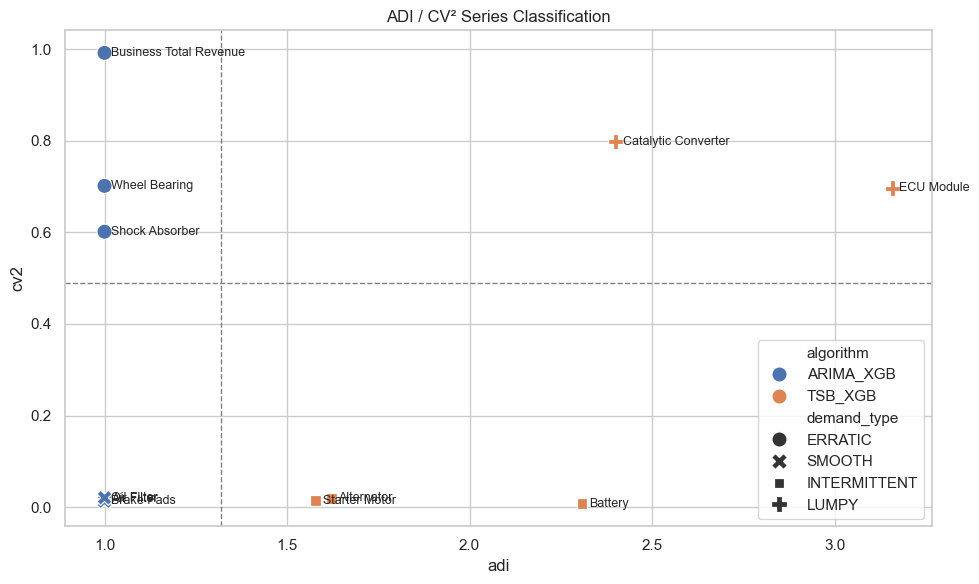

In [17]:
classification_rows = []

for product_name, product_frame in monthly_sales.groupby(PRODUCT_COLUMN, sort=True):
    product_frame = product_frame.sort_values("period").reset_index(drop=True)
    quantities = product_frame[QUANTITY_COLUMN].astype(float).tolist()
    result = classify(quantities)
    classification_rows.append({
        "series_kind": "product",
        "product_name": product_name,
        "observations": len(product_frame),
        "total_quantity": float(product_frame[QUANTITY_COLUMN].sum()),
        "recommended_walk_forward_epochs": recommended_walk_forward_epochs(len(product_frame), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS),
        "adi": result["adi"],
        "cv2": result["cv2"],
        "demand_type": result["demandType"],
        "algorithm": result["algorithm"],
    })

if business_revenue_series is not None and not business_revenue_series.empty:
    revenue_values = business_revenue_series[QUANTITY_COLUMN].astype(float).tolist()
    revenue_result = classify(revenue_values)
    classification_rows.append({
        "series_kind": "business_revenue",
        "product_name": BUSINESS_REVENUE_NAME,
        "observations": len(business_revenue_series),
        "total_quantity": float(business_revenue_series[QUANTITY_COLUMN].sum()),
        "recommended_walk_forward_epochs": recommended_walk_forward_epochs(len(business_revenue_series), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS),
        "adi": revenue_result["adi"],
        "cv2": revenue_result["cv2"],
        "demand_type": revenue_result["demandType"],
        "algorithm": revenue_result["algorithm"],
    })

classification_df = pd.DataFrame(classification_rows).assign(series_priority=lambda df: (df["series_kind"] != "business_revenue").astype(int)).sort_values(["series_priority", "algorithm", "product_name"]).drop(columns=["series_priority"]).reset_index(drop=True)
display(classification_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=classification_df, x="adi", y="cv2", hue="algorithm", style="demand_type", s=120, ax=ax)
for idx, row in classification_df.iterrows():
    ax.annotate(row["product_name"], (row["adi"], row["cv2"]), xytext=(5, 0), textcoords="offset points", fontsize=9, va="center")
ax.axvline(1.32, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.49, color="gray", linestyle="--", linewidth=1)
ax.set_title("ADI / CV² Series Classification")
plt.tight_layout()
plt.show()


## Sequential Training by Classified Model

Each product is routed to the algorithm selected by ADI / CV² classification. Statistical-model walk-forward epochs are determined automatically from the product history length.

c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

### Training Window Candidate Metrics

,training_window,window_value,RMSE,MSE,MAE,MAPE,sMAPE,WAPE,LogLoss,product_name
0,All History,NaN,"5,654,087.6693","31,968,707,371,601.4688","4,581,237.8683",182.1458,88.3225,110.7768,1.4781,Business Total Revenue
1,48 Months,48.0000,"4,523,723.5023","20,464,074,325,328.8477","3,102,862.2467",95.9055,69.0077,75.0289,1.1114,Business Total Revenue
2,36 Months,36.0000,"6,689,928.1076","44,755,138,085,109.6641","4,482,638.5817",135.4990,78.5893,108.3926,1.5528,Business Total Revenue
3,24 Months,24.0000,"6,527,651.0339","42,610,228,020,149.1641","5,212,110.3483",167.1605,93.0255,126.0316,1.4041,Business Total Revenue
4,All History,NaN,14.9300,222.9047,11.3250,11.9292,11.5098,11.4780,0.0231,Air Filter
5,48 Months,48.0000,13.8284,191.2239,10.5233,11.2385,10.7410,10.6655,0.0203,Air Filter
6,36 Months,36.0000,15.2028,231.1239,12.2567,12.7466,12.4944,12.4223,0.0238,Air Filter
7,24 Months,24.0000,15.4776,239.5553,12.5725,13.1811,12.7090,12.7424,0.0246,Air Filter
8,All History,NaN,15.0385,226.1567,11.6808,8.1730,8.4687,8.3634,0.0118,Brake Pads
9,48 Months,48.0000,15.6600,245.2352,13.1508,9.3322,9.5004,9.4159,0.0126,Brake Pads


### Training Summary

,product_name,algorithm,demand_type,adi,cv2,walk_forward_epochs,xgb_rounds_initial,xgb_rounds_retrain,selected_training_window,epochs,avg_train_size,avg_training_log_loss,saved_model_path,RMSE,MSE,MAE,MAPE,sMAPE,WAPE,LogLoss,series_kind,training_start_period,training_end_period,training_observations,artifact_RMSE,artifact_MSE,artifact_MAE,artifact_MAPE,artifact_sMAPE,artifact_WAPE,artifact_log_loss,artifact_accuracy,retrained,retrain_improved,initial_mape,low_accuracy,arima_order,arima_aic,n_train,horizon,xgb_enabled,tsb_alpha,tsb_beta,tsb_mse
0,Business Total Revenue,ARIMA_XGB,ERRATIC,1.0000,0.9917,12,200,400,48 Months,12,48.0000,5.1622,C:\Users\Joem Inciong\automotive-spare-parts-d...,"4,523,723.5023","20,464,074,325,328.8477","3,102,862.2467",95.9055,69.0077,75.0289,1.1114,business_revenue,2022-01,2025-12,48,"3,327,024.9530","11,069,095,037,954.9375","1,527,039.0398",56.5445,29.2638,39.0800,5.9275,43.4555,None,None,None,None,"[0, 1, 1]","1,564.8927",48,6,True,NaN,NaN,NaN
1,Brake Pads,ARIMA_XGB,SMOOTH,1.0000,0.0130,12,200,400,All History,12,53.5000,0.4321,C:\Users\Joem Inciong\automotive-spare-parts-d...,15.0385,226.1567,11.6808,8.1730,8.4687,8.3634,0.0118,product,2021-01,2025-12,60,17.0470,290.6016,4.7109,3.6004,5.3120,3.4647,0.3837,96.3996,None,None,None,None,"[0, 1, 1]",499.0989,60,6,True,NaN,NaN,NaN
2,Air Filter,ARIMA_XGB,SMOOTH,1.0000,0.0170,12,200,400,48 Months,12,48.0000,0.4455,C:\Users\Joem Inciong\automotive-spare-parts-d...,13.8284,191.2239,10.5233,11.2385,10.7410,10.6655,0.0203,product,2022-01,2025-12,48,16.5395,273.5552,5.0986,5.1970,7.1828,5.1544,0.4563,94.8030,None,None,None,None,"[0, 1, 1]",373.0747,48,6,True,NaN,NaN,NaN
3,Oil Filter,ARIMA_XGB,SMOOTH,1.0000,0.0205,12,200,400,All History,12,53.5000,0.4493,C:\Users\Joem Inciong\automotive-spare-parts-d...,20.1918,407.7108,17.5283,13.3685,13.0014,12.9043,0.0230,product,2021-01,2025-12,60,19.3788,375.5389,5.3974,3.7700,5.5594,3.8635,0.3990,96.2300,None,None,None,None,"[0, 1, 1]",529.0147,60,6,True,NaN,NaN,NaN
4,Wheel Bearing,ARIMA_XGB,ERRATIC,1.0000,0.7014,12,200,400,All History,12,53.5000,0.5935,C:\Users\Joem Inciong\automotive-spare-parts-d...,57.3794,"3,292.3954",37.2817,155.8869,47.0574,42.5671,0.9106,product,2021-01,2025-12,60,26.6210,708.6772,10.6832,32.2942,21.2160,13.5574,0.5300,67.7058,None,None,None,None,"[0, 1, 1]",669.8087,60,6,True,NaN,NaN,NaN
5,Shock Absorber,ARIMA_XGB,ERRATIC,1.0000,0.6013,12,200,400,36 Months,12,36.0000,0.8970,C:\Users\Joem Inciong\automotive-spare-parts-d...,72.1964,"5,212.3253",63.6608,420.7250,90.4067,81.3557,2.1864,product,2023-01,2025-12,36,61.5735,"3,791.2987",32.0514,111.2085,33.5566,31.9626,1.3034,0.0000,None,None,None,None,"[0, 1, 1]",405.7241,36,6,True,NaN,NaN,NaN
6,Starter Motor,TSB_XGB,INTERMITTENT,1.5789,0.0142,12,200,400,24 Months,12,24.0000,1.9302,C:\Users\Joem Inciong\automotive-spare-parts-d...,25.6062,655.6778,22.1025,37.0172,89.3142,60.8326,3.7514,product,2024-01,2025-12,24,10.2977,106.0416,6.5372,10.2298,69.3101,20.2965,1.5714,89.7702,None,None,None,None,NaN,NaN,24,6,True,0.5000,0.5000,195.3876
7,Alternator,TSB_XGB,INTERMITTENT,1.6216,0.0192,12,200,400,All History,12,53.5000,1.2066,C:\Users\Joem Inciong\automotive-spare-parts-d...,42.5883,"1,813.7597",38.4742,42.1290,118.8028,99.9329,7.0313,product,2021-01,2025-12,60,10.4257,108.6945,5.2277,5.9589,78.8197,12.0039,1.1431,94.0411,None,None,None,None,NaN,NaN,60,6,True,0.5000,0.5000,481.4525
8,Battery,TSB_XGB,INTERMITTENT,2.3077,0.0075,12,200,400,All History,12,53.5000,1.0305,C:\Users\Joem Inciong\automotive-spare-parts-d...,31.1844,972.4650,24.1792,45.2832,135.1150,93.2958,5.8766,product,2021-01,2025-12,60,7.2715,52.8752,3.4716,5.6164,111.8096,12.7164,1.0194,94.3836,None,None,None,None,NaN,NaN,60,6,True,0.5000,0.5000,342.3161
9,Catalytic Converter,TSB_XGB,LUMPY,2.4000,0.7975,12,200,400,36 Months,12,36.0000,2.4611,C:\Users\Joem Inciong\automotive-spare-parts-d...,95.5822,"9,135.9491",74.1225,77.1074,135.9792,117.9668,9.1643,product,2023-01,2025-12,36,30.5361,932.452

### Sequential Training Performance Graphs

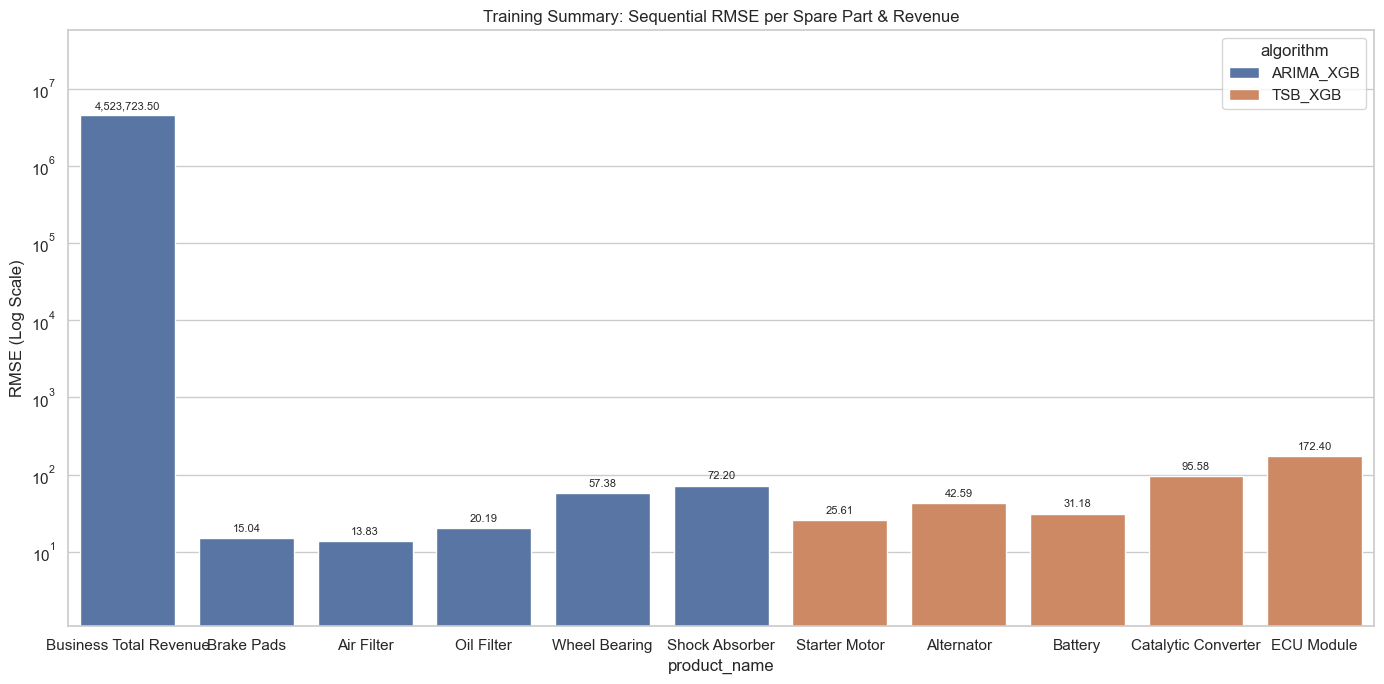

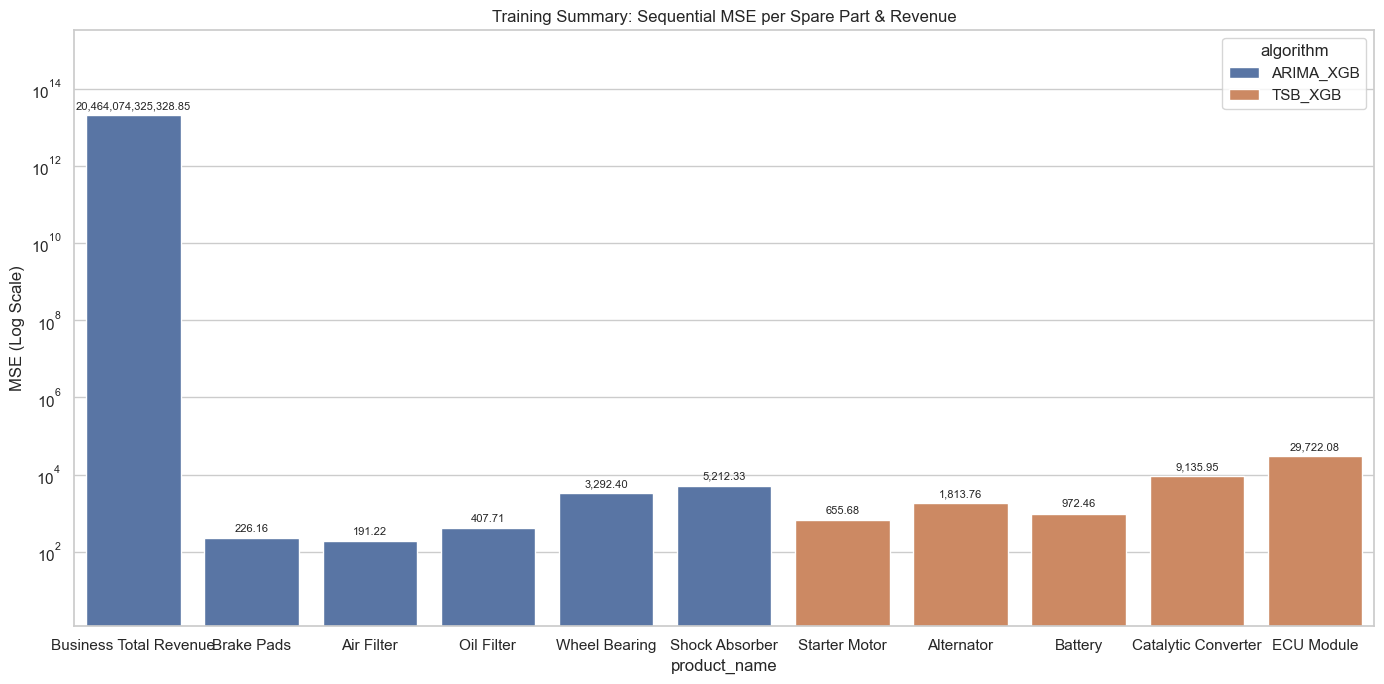

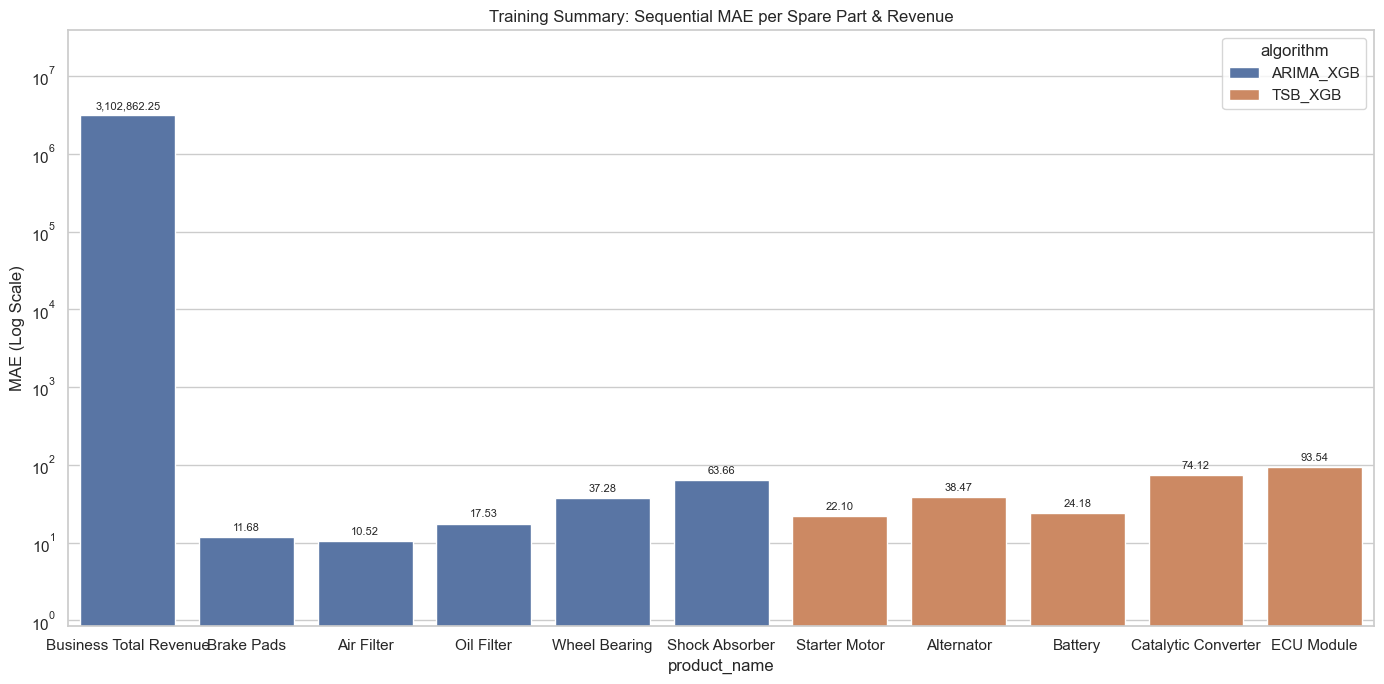

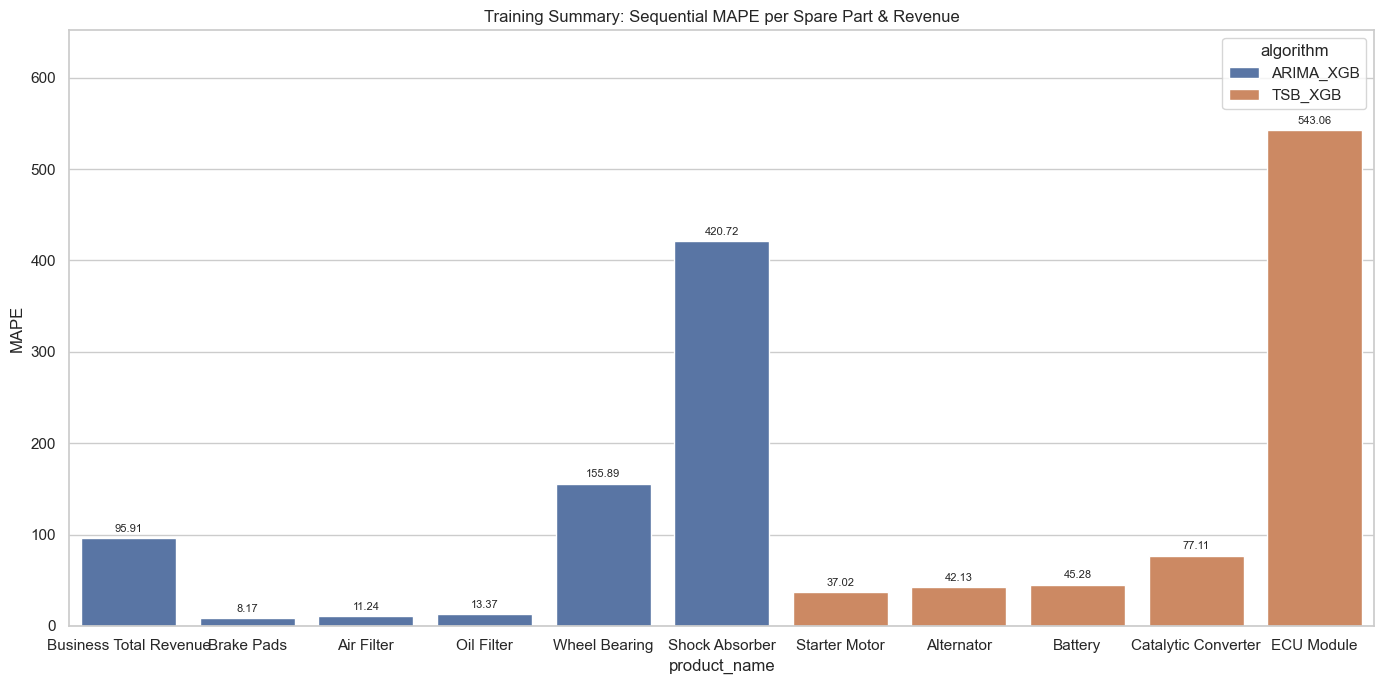

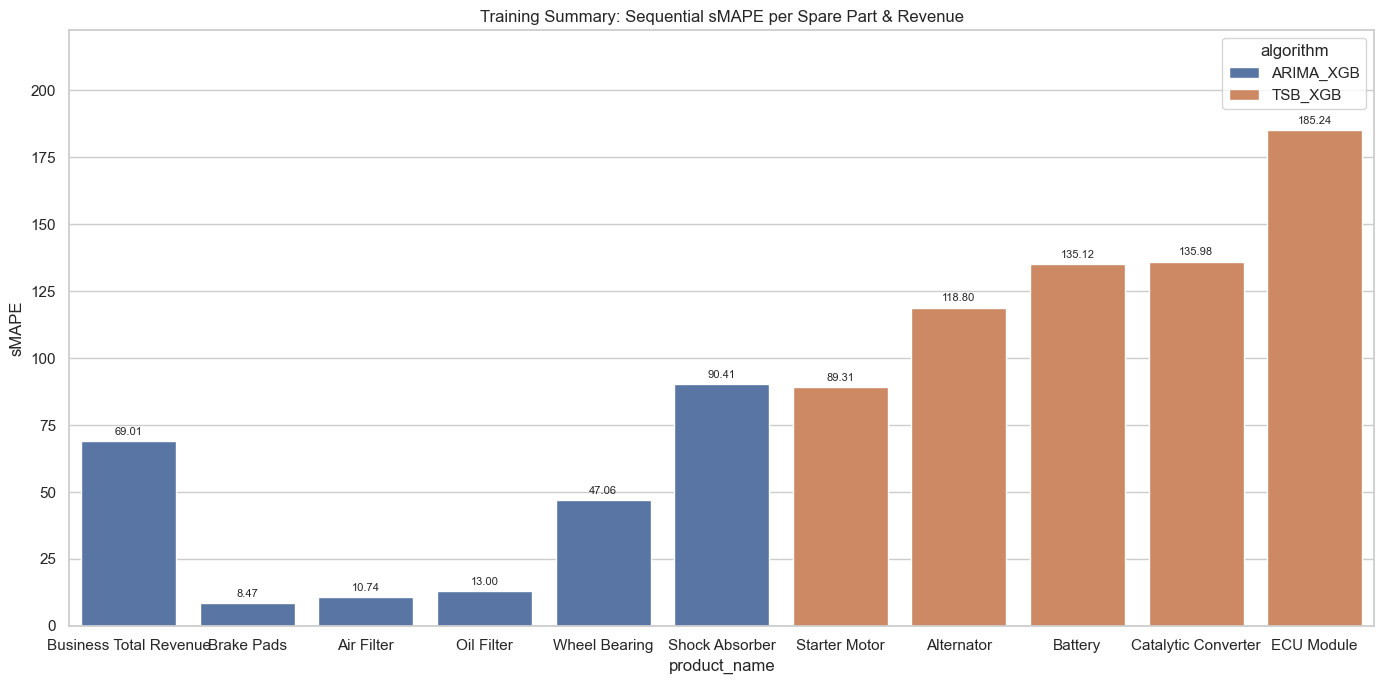

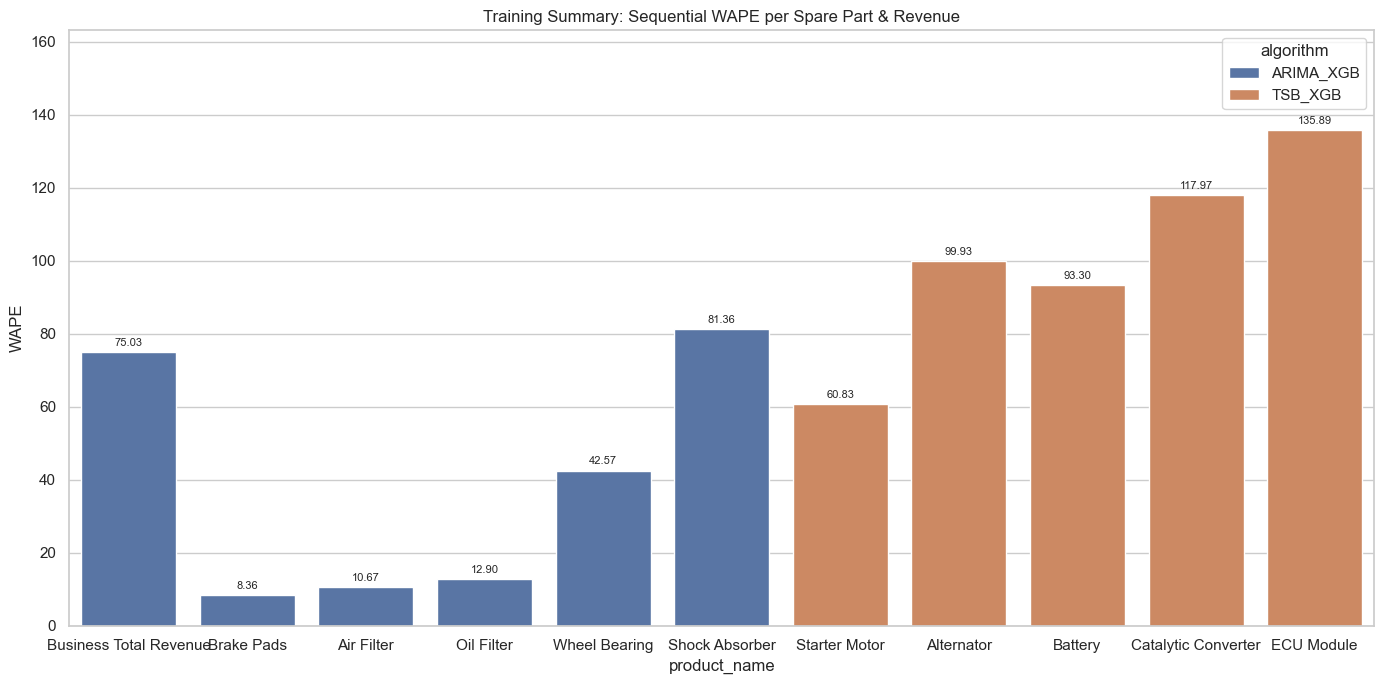

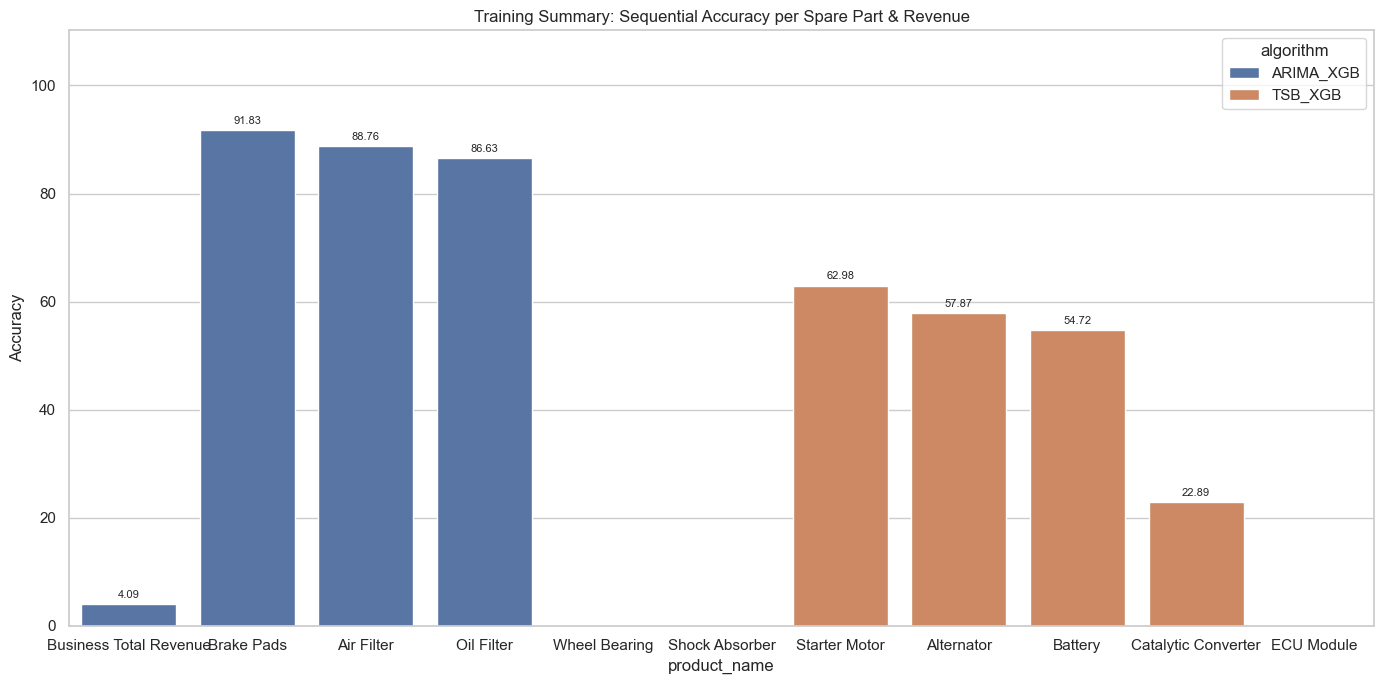

### Cached Model Fitted Performance Graphs

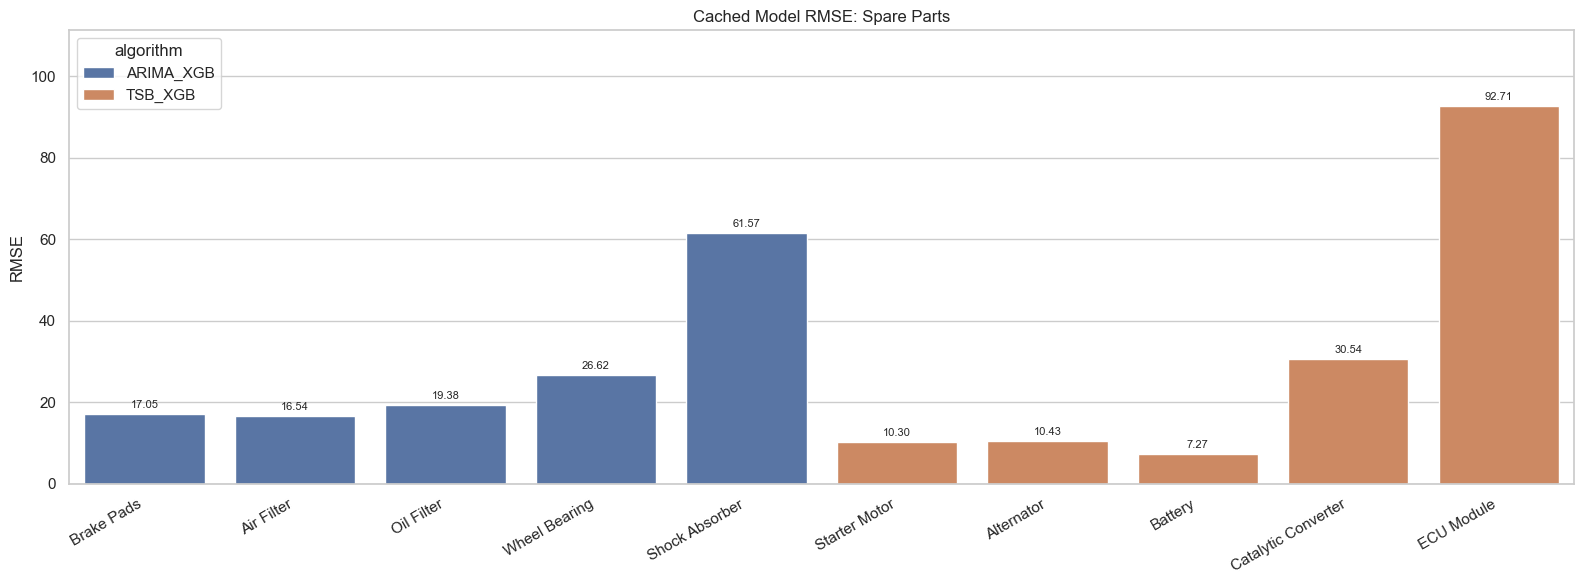

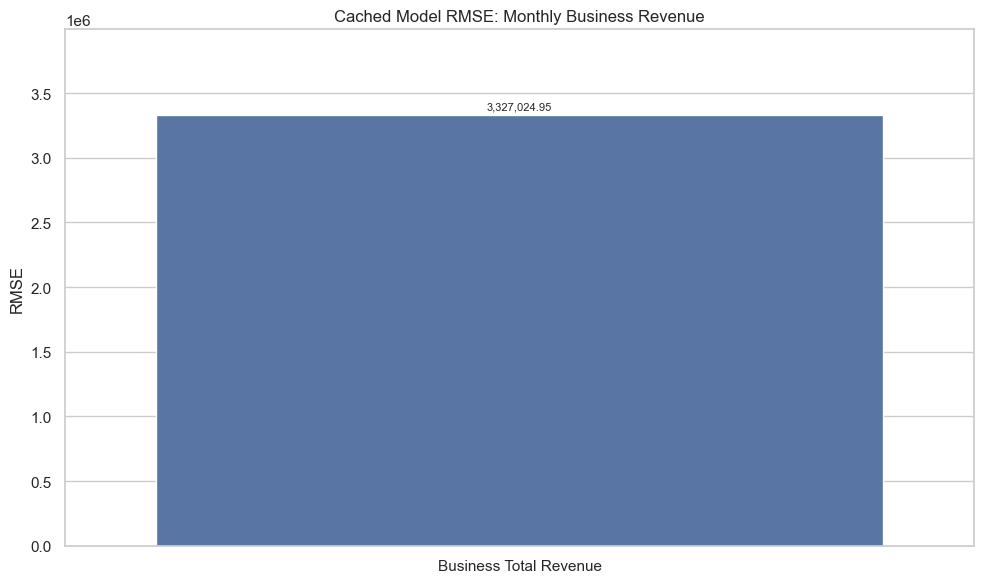

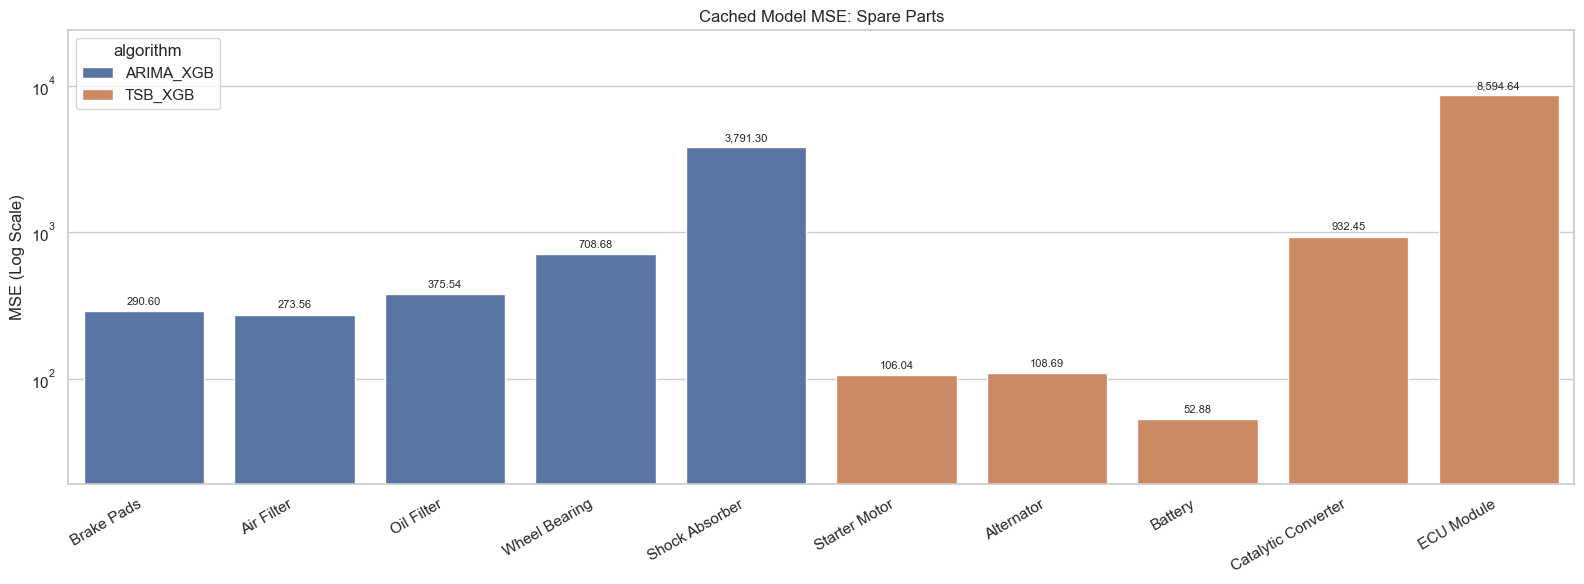

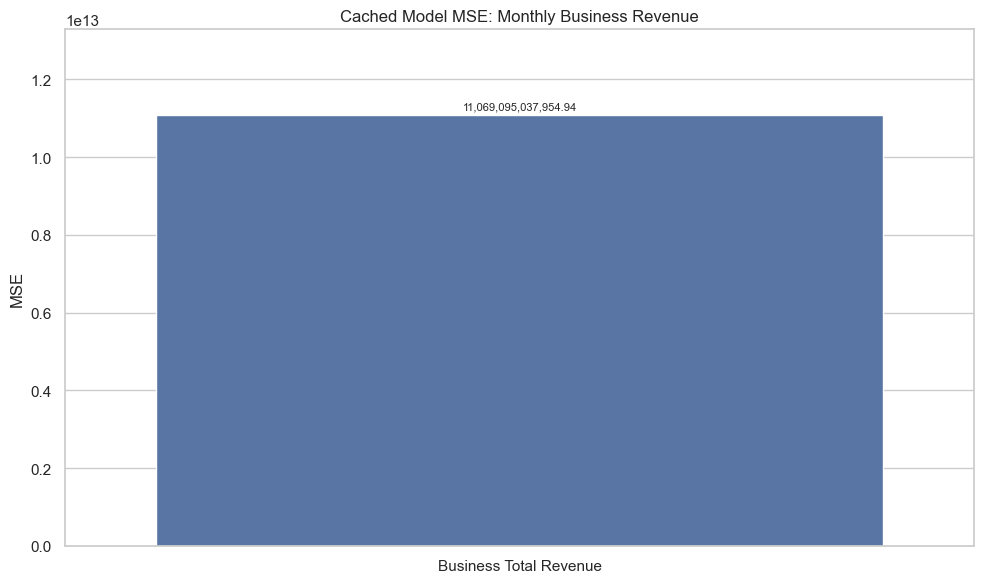

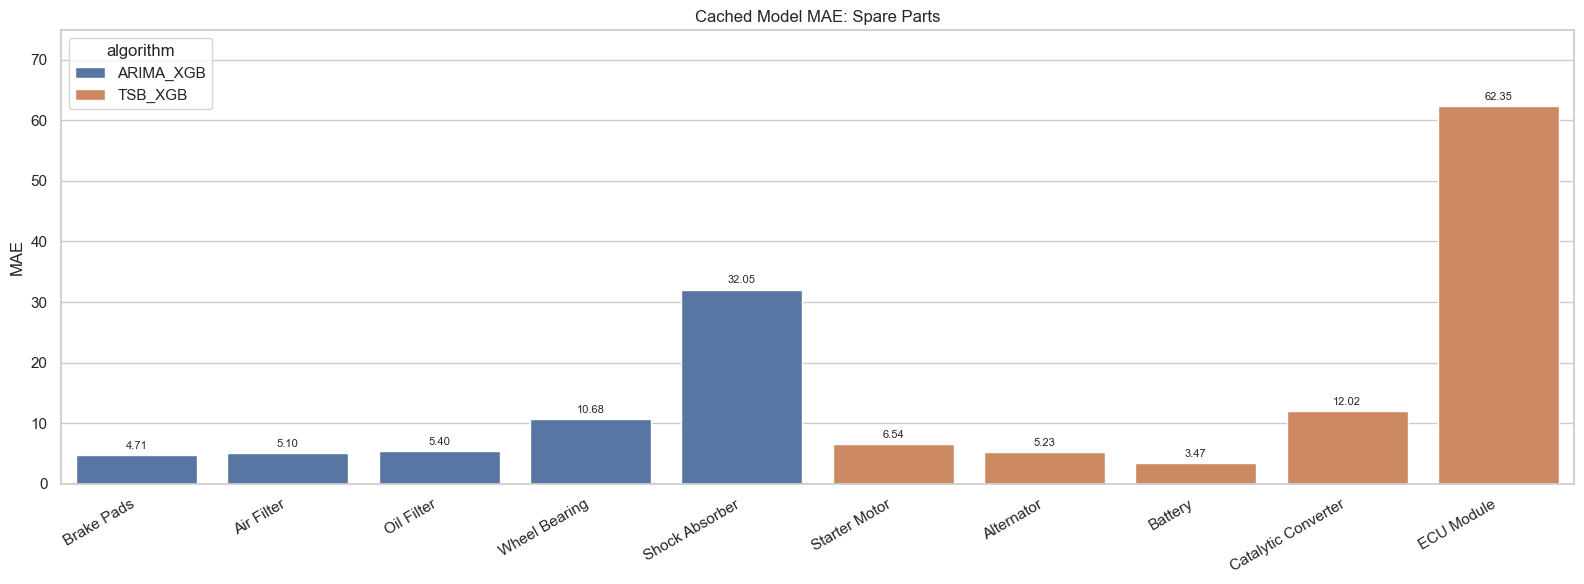

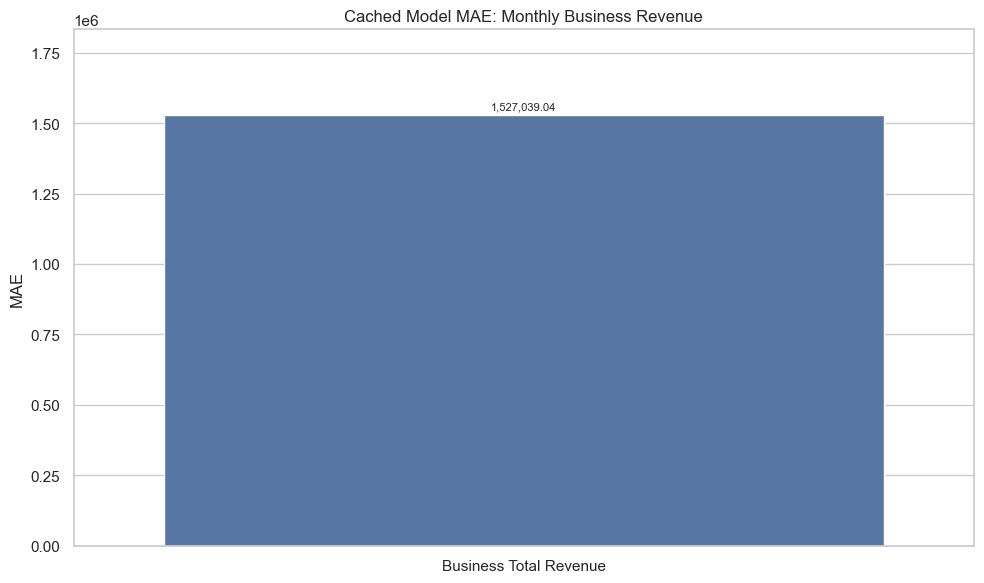

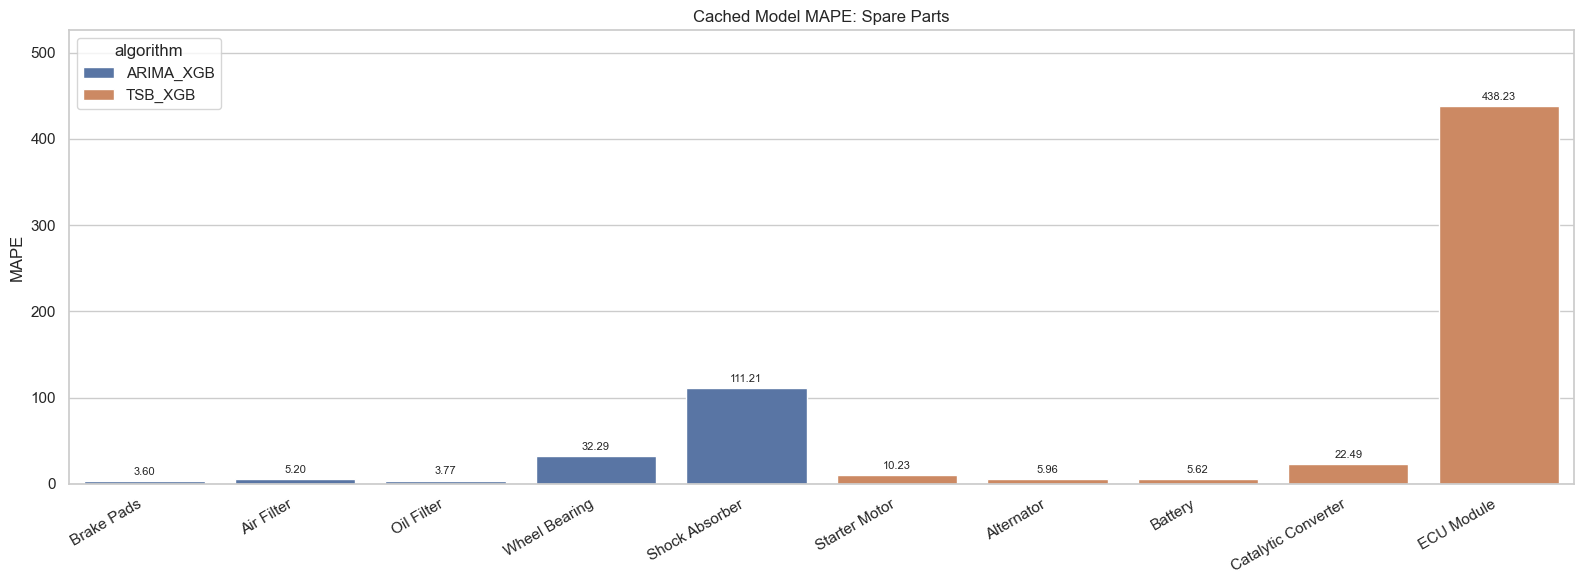

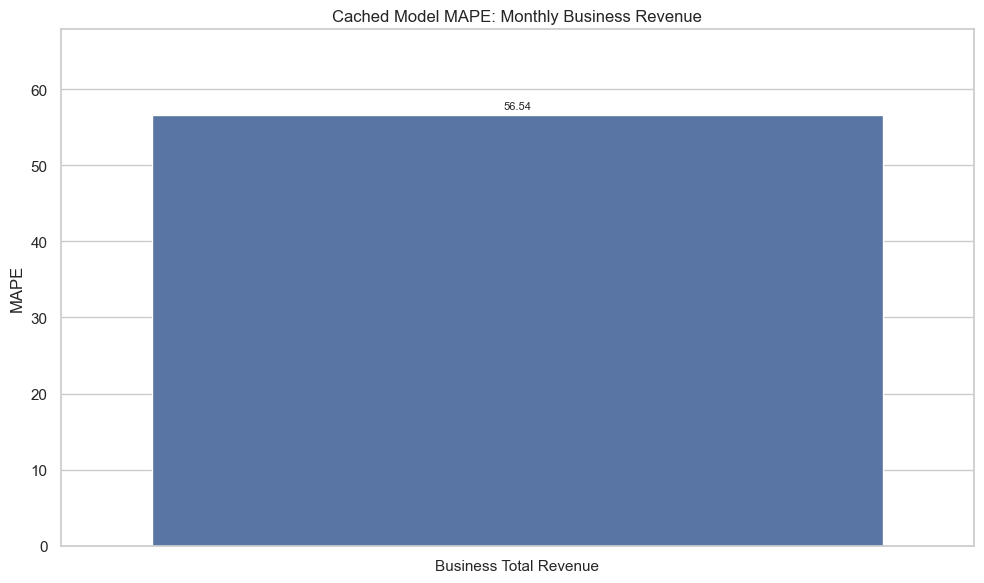

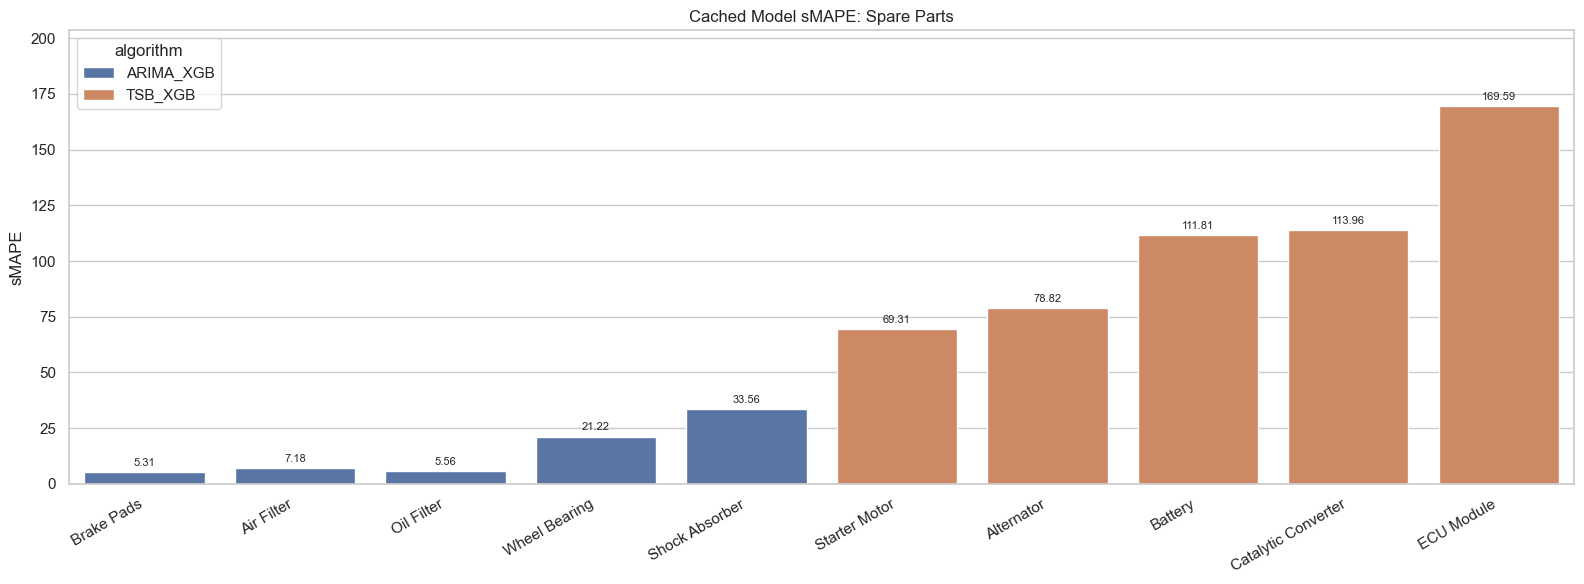

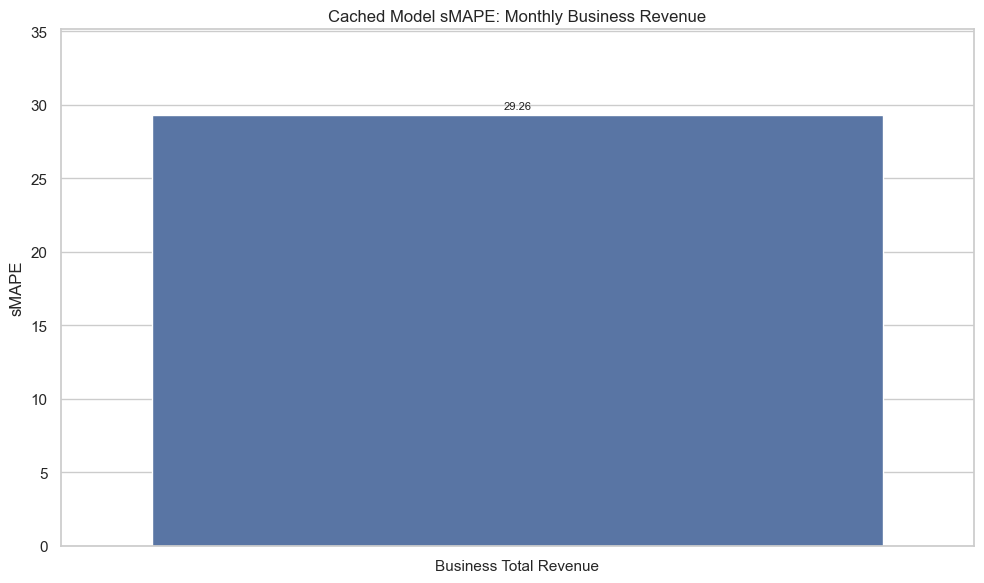

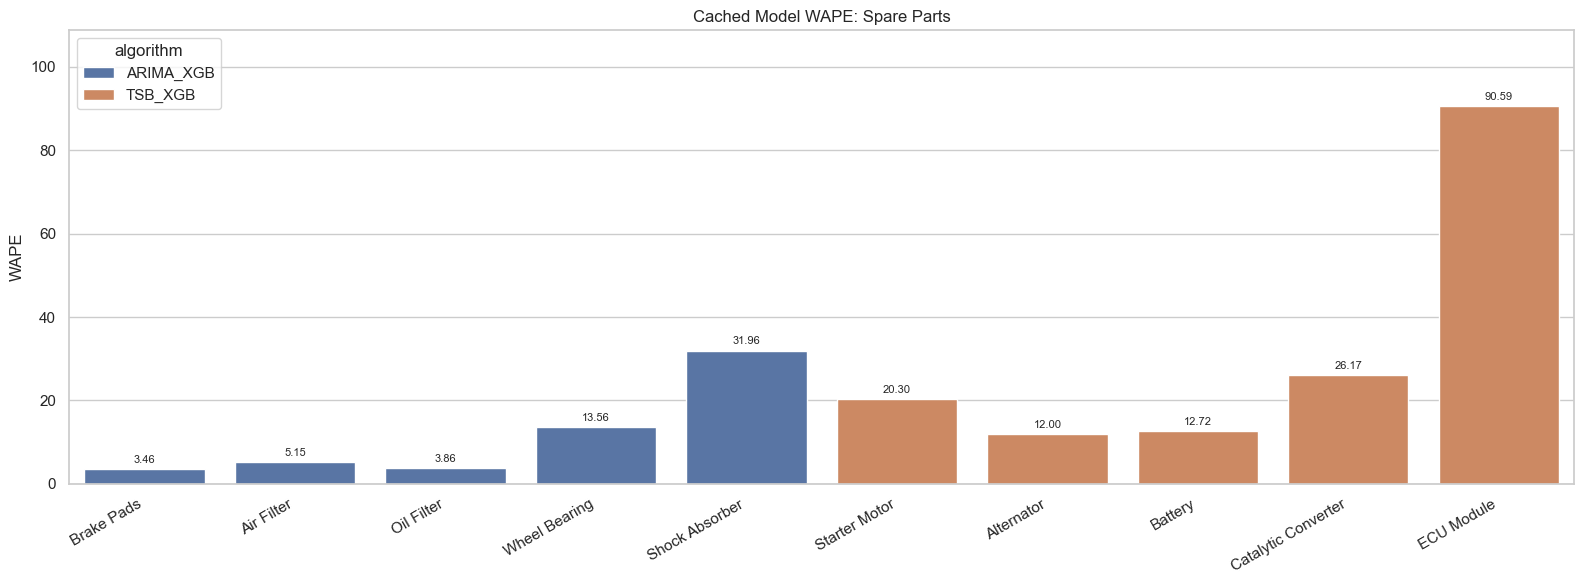

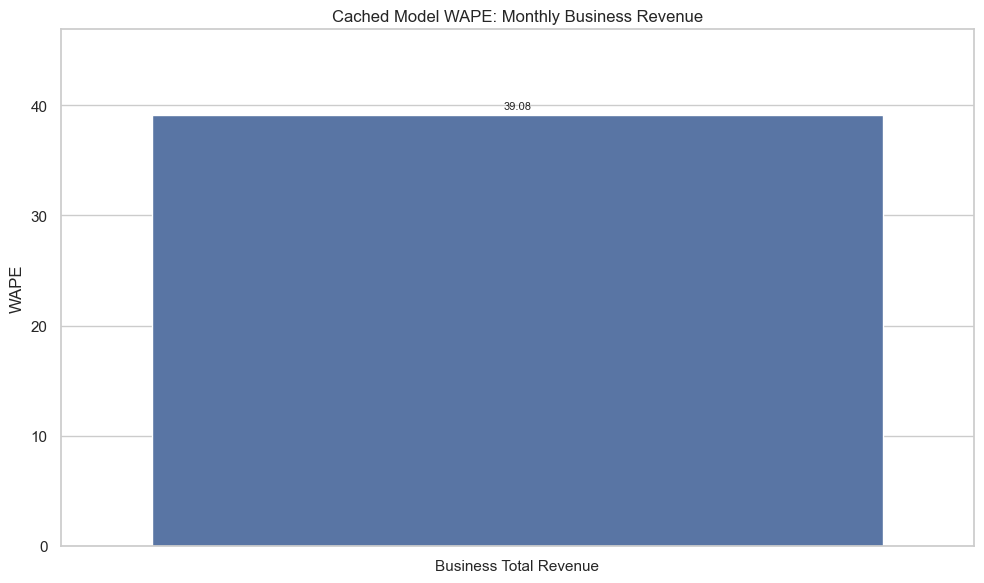

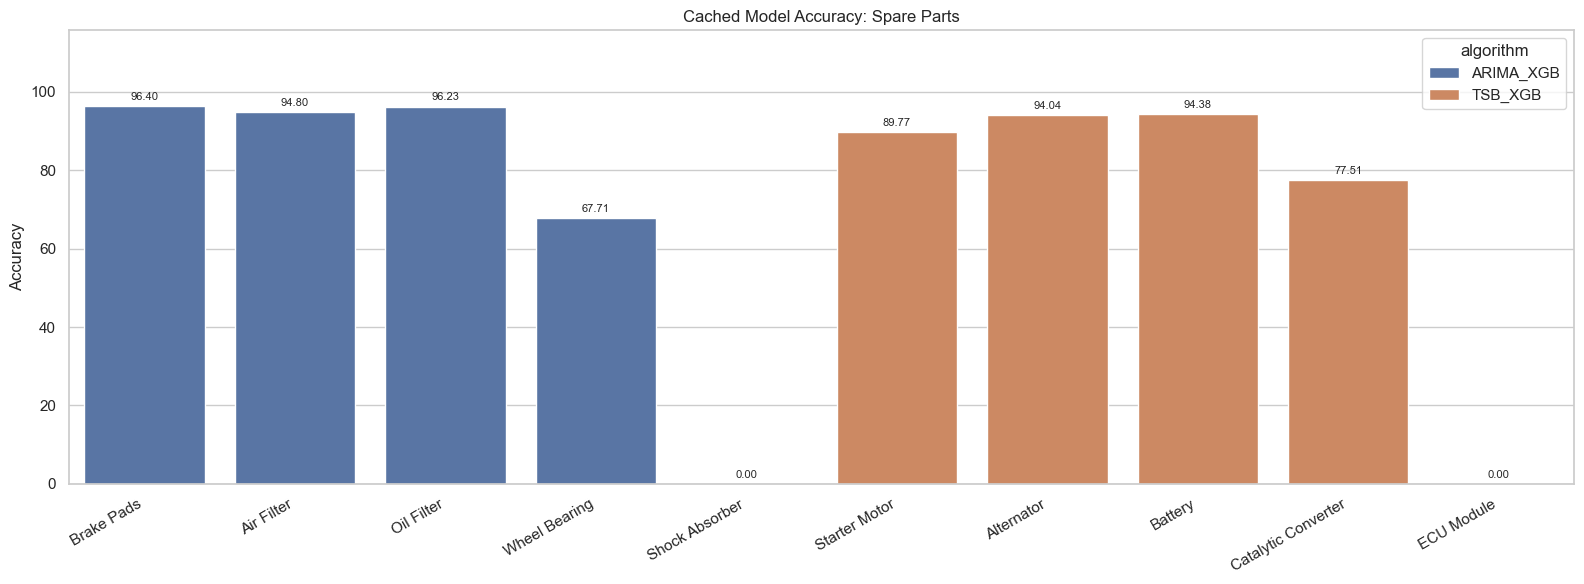

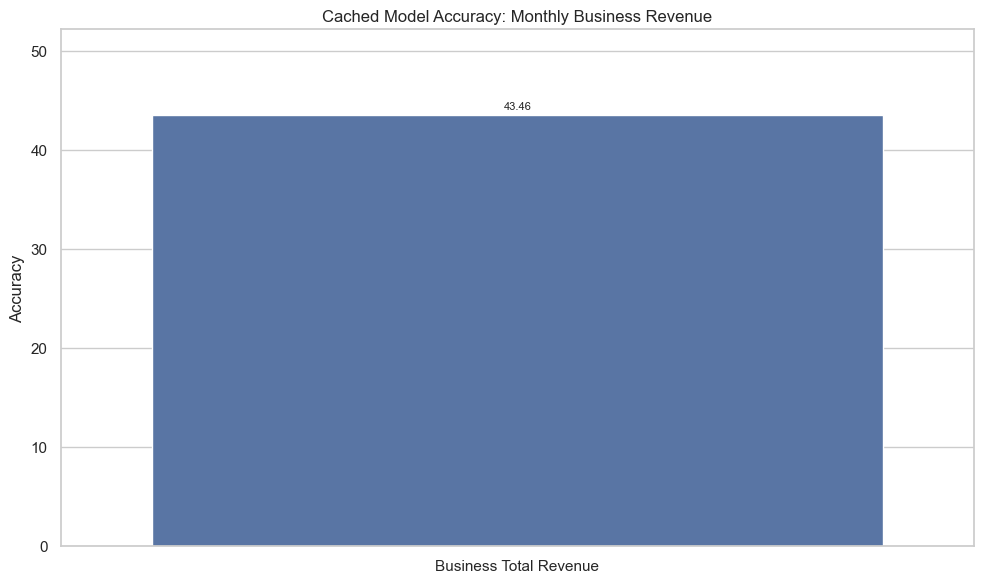

In [18]:
trainer_map = {
    "ARIMA_XGB": {
        "train_fn": train_arima_xgb,
        "forecast_fn": forecast_arima_xgb,
        "save_fn": save_arima_xgb_model,
        "subdir": TRAINED_MODELS_DIR / "arima_xgb",
        "canonical_dir": TRAINED_MODELS_DIR / "arima_xgb",
        "xgb_initial_rounds": ARIMA_XGB_PARAMS_INITIAL["n_estimators"],
        "xgb_retrain_rounds": ARIMA_XGB_PARAMS_RETRAIN["n_estimators"],
    },
    "TSB_XGB": {
        "train_fn": train_tsb_xgb,
        "forecast_fn": forecast_tsb_xgb,
        "save_fn": save_tsb_xgb_model,
        "subdir": TRAINED_MODELS_DIR / "tsb_xgb",
        "canonical_dir": TRAINED_MODELS_DIR / "tsb_xgb",
        "xgb_initial_rounds": TSB_XGB_PARAMS_INITIAL["n_estimators"],
        "xgb_retrain_rounds": TSB_XGB_PARAMS_RETRAIN["n_estimators"],
    },
}

training_summaries = []
epoch_results = {}
forecast_results = {}
candidate_window_results = {}
skipped_products = []

for row in classification_df.to_dict(orient="records"):
    product_name = row["product_name"]
    algorithm = row["algorithm"]
    series_kind = row.get("series_kind", "product")

    if series_kind == "business_revenue":
        product_history = business_revenue_series.sort_values("period").reset_index(drop=True).copy()
    else:
        product_history = monthly_sales[monthly_sales[PRODUCT_COLUMN] == product_name].sort_values("period").reset_index(drop=True).copy()

    dates = product_history["period_str"].tolist()
    quantities = product_history[QUANTITY_COLUMN].astype(float).tolist()
    walk_forward_epochs = recommended_walk_forward_epochs(len(dates), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS)

    if len(dates) <= MIN_TRAIN_SIZE:
        skipped_products.append({
            "product_name": product_name,
            "algorithm": algorithm,
            "reason": f"Need more than {MIN_TRAIN_SIZE} monthly observations",
            "observations": len(dates),
        })
        continue

    config = trainer_map[algorithm]
    config["subdir"].mkdir(parents=True, exist_ok=True)

    if series_kind == "business_revenue":
        config["canonical_dir"].mkdir(parents=True, exist_ok=True)
        output_path = config["canonical_dir"] / f"{BUSINESS_REVENUE_ARTIFACT_NAME}.pkl"
    else:
        output_path = config["subdir"] / f"{slugify_name(product_name)}.pkl"

    training_window_candidates = get_training_window_candidates(
        row["demand_type"],
        series_kind=series_kind,
        n_observations=len(dates),
    )
    selected_training_window, epoch_frame, candidate_metric_frame = select_best_training_window(
        dates=dates,
        quantities=quantities,
        train_fn=config["train_fn"],
        forecast_fn=config["forecast_fn"],
        demand_type=row["demand_type"],
        series_kind=series_kind,
        test_size=walk_forward_epochs,
    )
    candidate_window_results[product_name] = candidate_metric_frame

    final_dates, final_quantities, final_train_start_index = get_training_slice(
        dates,
        quantities,
        training_window=selected_training_window,
    )
    artifact, forecast_rows, final_meta, _ = config["train_fn"](final_dates, final_quantities, horizon=FORECAST_HORIZON)
    artifact_metrics = compute_artifact_training_metrics(artifact)
    artifact_log_loss = artifact_metrics.get(LOG_LOSS_COLUMN, np.nan)
    validation_metrics = compute_metrics(epoch_frame["actual"], epoch_frame["predicted"])

    artifact_meta = artifact.setdefault("meta", {})
    artifact_meta.update(final_meta)
    artifact_meta.update({
        "metric_scope": "in_sample_fitted_training",
        "validation_metric_scope": "walk_forward_holdout",
        "window_selection_metric": WINDOW_SELECTION_METRIC,
        "selected_training_window": training_window_label(selected_training_window),
        "training_window_candidates": [training_window_label(item) for item in training_window_candidates],
        "training_start_period": final_dates[0],
        "training_end_period": final_dates[-1],
        "training_observations": len(final_dates),
        "validation_epochs": int(len(epoch_frame)),
        "validation_rmse": round(validation_metrics["RMSE"], 4) if pd.notna(validation_metrics["RMSE"]) else None,
        "validation_mse": round(validation_metrics["MSE"], 4) if pd.notna(validation_metrics["MSE"]) else None,
        "validation_mae": round(validation_metrics["MAE"], 4) if pd.notna(validation_metrics["MAE"]) else None,
        "validation_mape": round(validation_metrics["MAPE"], 2) if pd.notna(validation_metrics["MAPE"]) else None,
        "validation_smape": round(validation_metrics["sMAPE"], 2) if pd.notna(validation_metrics["sMAPE"]) else None,
        "validation_wape": round(validation_metrics["WAPE"], 2) if pd.notna(validation_metrics["WAPE"]) else None,
        "validation_log_loss": round(validation_metrics[LOG_LOSS_COLUMN], 6) if pd.notna(validation_metrics[LOG_LOSS_COLUMN]) else None,
        "artifact_rmse": round(artifact_metrics["RMSE"], 4) if pd.notna(artifact_metrics["RMSE"]) else None,
        "artifact_mse": round(artifact_metrics["MSE"], 4) if pd.notna(artifact_metrics["MSE"]) else None,
        "artifact_mae": round(artifact_metrics["MAE"], 4) if pd.notna(artifact_metrics["MAE"]) else None,
        "artifact_mape": round(artifact_metrics["MAPE"], 2) if pd.notna(artifact_metrics["MAPE"]) else None,
        "artifact_smape": round(artifact_metrics["sMAPE"], 2) if pd.notna(artifact_metrics["sMAPE"]) else None,
        "artifact_wape": round(artifact_metrics["WAPE"], 2) if pd.notna(artifact_metrics["WAPE"]) else None,
        "artifact_log_loss": round(artifact_log_loss, 6) if pd.notna(artifact_log_loss) else None,
    })
    saved_model_path = config["save_fn"](artifact, output_path)

    epoch_results[product_name] = epoch_frame
    forecast_results[product_name] = pd.DataFrame(forecast_rows)

    summary = summarize_epochs(
        epoch_frame=epoch_frame,
        product_name=product_name,
        model_name=algorithm,
        demand_type=row["demand_type"],
        adi=row["adi"],
        cv2=row["cv2"],
        saved_model_path=saved_model_path,
        walk_forward_epochs=walk_forward_epochs,
        xgb_rounds_initial=config["xgb_initial_rounds"],
        xgb_rounds_retrain=config["xgb_retrain_rounds"],
        selected_training_window=selected_training_window,
        training_window_candidates=training_window_candidates,
    )
    summary.update({"series_kind": series_kind, "training_start_period": final_dates[0], "training_end_period": final_dates[-1], "training_observations": len(final_dates)})
    summary.update({
        "artifact_RMSE": artifact_metrics.get("RMSE"),
        "artifact_MSE": artifact_metrics.get("MSE"),
        "artifact_MAE": artifact_metrics.get("MAE"),
        "artifact_MAPE": artifact_metrics.get("MAPE"),
        "artifact_sMAPE": artifact_metrics.get("sMAPE"),
        "artifact_WAPE": artifact_metrics.get("WAPE"),
        "artifact_log_loss": artifact_log_loss,
        "artifact_accuracy": max(0, 100 - artifact_metrics["MAPE"]) if pd.notna(artifact_metrics["MAPE"]) else None,
        "retrained": final_meta.get("retrained"),
        "retrain_improved": final_meta.get("retrain_improved"),
        "initial_mape": final_meta.get("initial_mape"),
        "low_accuracy": final_meta.get("low_accuracy"),
    })
    for meta_key, meta_value in final_meta.items():
        if meta_key not in {"rmse", "mse", "mae", "mape", "smape", "wape", "accuracy", "retrained", "retrain_improved", "initial_mape", "low_accuracy"}:
            summary[meta_key] = meta_value
    training_summaries.append(summary)

training_summary_df = pd.DataFrame(training_summaries).assign(series_priority=lambda df: (df["series_kind"] != "business_revenue").astype(int)).sort_values(["series_priority", "algorithm", "MAPE", "RMSE"]).drop(columns=["series_priority"]).reset_index(drop=True)
skipped_df = pd.DataFrame(skipped_products)

candidate_window_summary_df = pd.concat(
    [frame.assign(product_name=product_name) for product_name, frame in candidate_window_results.items()],
    ignore_index=True,
) if candidate_window_results else pd.DataFrame()

if not candidate_window_summary_df.empty:
    display(Markdown("### Training Window Candidate Metrics"))
    display(candidate_window_summary_df)

display(Markdown("### Training Summary"))
display(training_summary_df)

if not skipped_df.empty:
    display(Markdown("### Skipped Products"))
    display(skipped_df)

if not training_summary_df.empty:
    from IPython.display import Markdown, display
    display(Markdown("### Sequential Training Performance Graphs"))
    
    # Dynamically compute Accuracy for sequential training if missing, based on MAPE
    if "Accuracy" not in training_summary_df.columns and "MAPE" in training_summary_df.columns:
        training_summary_df["Accuracy"] = (100 - training_summary_df["MAPE"]).clip(lower=0)

    training_metrics = ["RMSE", "MSE", "MAE", "MAPE", "sMAPE", "WAPE", "Accuracy"]
    for metric in training_metrics:
        if metric in training_summary_df.columns:
            fig_train, ax_train = plt.subplots(figsize=(14, 7))
            sns.barplot(data=training_summary_df, x="product_name", y=metric, hue="algorithm", dodge=False, ax=ax_train)
            ax_train.set_title(f"Training Summary: Sequential {metric} per Spare Part & Revenue")
            ax_train.set_xticklabels(ax_train.get_xticklabels(), rotation=0, ha="center")
            metric_values = pd.to_numeric(training_summary_df[metric], errors="coerce")
            if metric in ["RMSE", "MSE", "MAE"] and (metric_values > 0).any():
                ax_train.set_yscale("log")
                ax_train.set_ylabel(f"{metric} (Log Scale)")
            else:
                ax_train.set_ylabel(metric)
            for container in ax_train.containers:
                labels = [f"{v.get_height():,.2f}" if np.isfinite(v.get_height()) and v.get_height() > 0 else "" for v in container]
                ax_train.bar_label(container, labels=labels, padding=3, fontsize=8, rotation=0)
            ax_train.margins(y=0.2)
            plt.tight_layout()
            plt.show()

    display(Markdown("### Cached Model Fitted Performance Graphs"))
    artifact_metrics_map = {
        "artifact_RMSE": "RMSE",
        "artifact_MSE": "MSE",
        "artifact_MAE": "MAE",
        "artifact_MAPE": "MAPE",
        "artifact_sMAPE": "sMAPE",
        "artifact_WAPE": "WAPE",
        "artifact_accuracy": "Accuracy",
    }
    artifact_plot_df = training_summary_df.copy()
    for art_col, display_name in artifact_metrics_map.items():
        if art_col not in artifact_plot_df.columns:
            continue

        metric_frame = artifact_plot_df.copy()
        metric_frame[art_col] = pd.to_numeric(metric_frame[art_col], errors="coerce")
        metric_frame = metric_frame[np.isfinite(metric_frame[art_col])]
        if metric_frame.empty:
            continue

        chart_groups = [
            ("Spare Parts", metric_frame[metric_frame["series_kind"] != "business_revenue"]),
            ("Monthly Business Revenue", metric_frame[metric_frame["series_kind"] == "business_revenue"]),
        ]
        for chart_label, chart_frame in chart_groups:
            if chart_frame.empty:
                continue

            fig_width = max(10, min(18, 4 + 1.2 * len(chart_frame)))
            fig_art, ax_art = plt.subplots(figsize=(fig_width, 6))
            sns.barplot(data=chart_frame, x="product_name", y=art_col, hue="algorithm", dodge=False, ax=ax_art)
            ax_art.set_title(f"Cached Model {display_name}: {chart_label}")
            ax_art.set_xlabel("")

            artifact_values = pd.to_numeric(chart_frame[art_col], errors="coerce")
            positive_values = artifact_values[artifact_values > 0]
            use_log_scale = (
                display_name in ["RMSE", "MSE", "MAE"]
                and len(positive_values) > 1
                and positive_values.max() / positive_values.min() >= 20
            )
            if use_log_scale:
                ax_art.set_yscale("log")
                ax_art.set_ylabel(f"{display_name} (Log Scale)")
            else:
                ax_art.set_ylabel(display_name)

            rotate_labels = len(chart_frame) > 3
            ax_art.tick_params(axis="x", rotation=30 if rotate_labels else 0)
            for tick_label in ax_art.get_xticklabels():
                tick_label.set_ha("right" if rotate_labels else "center")

            for container in ax_art.containers:
                labels = [f"{bar.get_height():,.2f}" if np.isfinite(bar.get_height()) else "" for bar in container]
                ax_art.bar_label(container, labels=labels, padding=3, fontsize=8)

            legend = ax_art.get_legend()
            if legend is not None and chart_frame["algorithm"].nunique() <= 1:
                legend.remove()
            ax_art.margins(y=0.2)
            plt.tight_layout()
            plt.show()


## Training Demand Confusion Matrix

This confusion matrix evaluates the sequential walk-forward training epochs by comparing whether each held-out actual value had demand against whether the model predicted demand. Predicted quantities are rounded to the nearest unit before assigning the demand class. MLogLoss is computed from the demand probability implied by the non-negative forecast quantity.


### Demand / No-Demand Confusion Matrix Accuracy: 78.79% | MLogLoss: 0.9381

Predicted,No Demand,Demand
Actual,,
No Demand,4,26
Demand,2,100


### Per-Class Confusion Metrics

,support,precision,recall,f1_score
Actual,,,,
No Demand,30,0.6667,0.1333,0.2222
Demand,102,0.7937,0.9804,0.8772


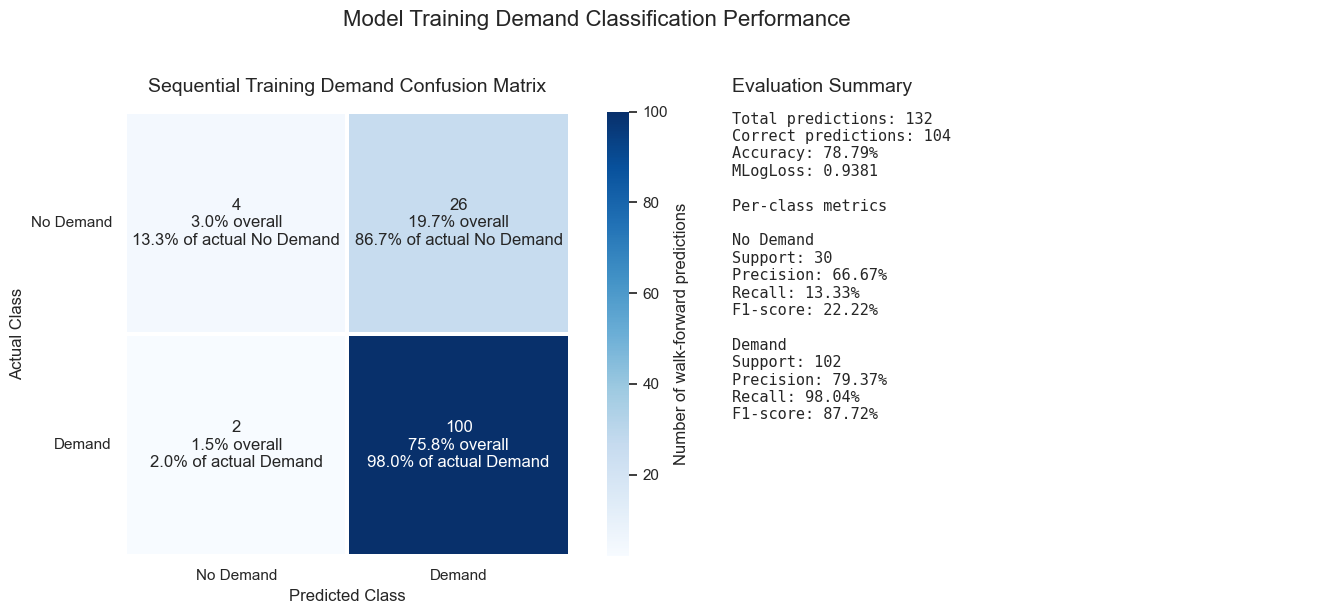

### Confusion Matrix by Trained Algorithm

Predicted            No Demand  Demand
Algorithm Actual                      
ARIMA_XGB Demand             0      72
TSB_XGB   Demand             2      28
          No Demand          4      26

In [19]:
confusion_rows = []

for _, summary_row in training_summary_df.iterrows():
    product_name = summary_row["product_name"]
    epoch_frame = epoch_results.get(product_name)

    if epoch_frame is None or epoch_frame.empty:
        continue

    frame = epoch_frame.copy()
    frame["product_name"] = product_name
    frame["algorithm"] = summary_row["algorithm"]
    frame["demand_type"] = summary_row["demand_type"]
    frame["actual_class"] = np.where(frame["actual"].astype(float) > 0, "Demand", "No Demand")
    frame["predicted_class"] = np.where(frame["predicted"].astype(float).round().clip(lower=0) > 0, "Demand", "No Demand")
    frame["predicted_demand_probability"] = 1 - np.exp(-frame["predicted"].astype(float).clip(lower=0))
    confusion_rows.append(frame[["product_name", "algorithm", "demand_type", "target_period", "actual", "predicted", "actual_class", "predicted_class", "predicted_demand_probability"]])

if not confusion_rows:
    raise ValueError("No walk-forward epoch predictions are available for the confusion matrix.")

confusion_epoch_df = pd.concat(confusion_rows, ignore_index=True)
class_order = ["No Demand", "Demand"]

demand_confusion_matrix = pd.crosstab(
    confusion_epoch_df["actual_class"],
    confusion_epoch_df["predicted_class"],
    rownames=["Actual"],
    colnames=["Predicted"],
).reindex(index=class_order, columns=class_order, fill_value=0)

matrix_values = demand_confusion_matrix.to_numpy()
total_predictions = matrix_values.sum()
demand_confusion_accuracy = np.trace(matrix_values) / total_predictions
mlogloss_epsilon = 1e-2
actual_demand_binary = (confusion_epoch_df["actual_class"] == "Demand").astype(int).to_numpy()
predicted_demand_probabilities = confusion_epoch_df["predicted_demand_probability"].astype(float).clip(mlogloss_epsilon, 1 - mlogloss_epsilon).to_numpy()
demand_mlogloss = -np.mean(
    actual_demand_binary * np.log(predicted_demand_probabilities)
    + (1 - actual_demand_binary) * np.log(1 - predicted_demand_probabilities)
)

row_totals = demand_confusion_matrix.sum(axis=1).replace(0, np.nan)
column_totals = demand_confusion_matrix.sum(axis=0).replace(0, np.nan)
recall_by_class = demand_confusion_matrix.div(row_totals, axis=0).fillna(0)
precision_by_class = demand_confusion_matrix.div(column_totals, axis=1).fillna(0)

confusion_metric_summary = pd.DataFrame({
    "support": demand_confusion_matrix.sum(axis=1).astype(int),
    "precision": [precision_by_class.loc[label, label] for label in class_order],
    "recall": [recall_by_class.loc[label, label] for label in class_order],
})
confusion_metric_summary["f1_score"] = np.where(
    (confusion_metric_summary["precision"] + confusion_metric_summary["recall"]) > 0,
    2 * confusion_metric_summary["precision"] * confusion_metric_summary["recall"] / (confusion_metric_summary["precision"] + confusion_metric_summary["recall"]),
    0,
)

annotation_labels = demand_confusion_matrix.copy().astype(str)
for actual_label in class_order:
    for predicted_label in class_order:
        count = demand_confusion_matrix.loc[actual_label, predicted_label]
        actual_total = demand_confusion_matrix.loc[actual_label].sum()
        overall_pct = count / total_predictions if total_predictions else 0
        row_pct = count / actual_total if actual_total else 0
        annotation_labels.loc[actual_label, predicted_label] = f"{count:,}\n{overall_pct:.1%} overall\n{row_pct:.1%} of actual {actual_label}"

display(Markdown(f"### Demand / No-Demand Confusion Matrix Accuracy: {demand_confusion_accuracy:.2%} | MLogLoss: {demand_mlogloss:.4f}"))
display(demand_confusion_matrix)
display(Markdown("### Per-Class Confusion Metrics"))
display(confusion_metric_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.25, 1]})

sns.heatmap(
    demand_confusion_matrix,
    annot=annotation_labels,
    fmt="",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "Number of walk-forward predictions"},
    square=True,
    ax=axes[0],
)
axes[0].set_title("Sequential Training Demand Confusion Matrix", fontsize=14, pad=14)
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")
axes[0].tick_params(axis="x", rotation=0)
axes[0].tick_params(axis="y", rotation=0)

axes[1].axis("off")
summary_lines = [
    f"Total predictions: {int(total_predictions):,}",
    f"Correct predictions: {int(np.trace(matrix_values)):,}",
    f"Accuracy: {demand_confusion_accuracy:.2%}",
    f"MLogLoss: {demand_mlogloss:.4f}",
    "",
    "Per-class metrics",
]
for label, metric_row in confusion_metric_summary.iterrows():
    summary_lines.extend([
        "",
        str(label),
        f"Support: {int(metric_row['support']):,}",
        f"Precision: {metric_row['precision']:.2%}",
        f"Recall: {metric_row['recall']:.2%}",
        f"F1-score: {metric_row['f1_score']:.2%}",
    ])
summary_text = "\n".join(summary_lines)
axes[1].text(0, 1, summary_text, va="top", ha="left", fontsize=11, family="monospace")
axes[1].set_title("Evaluation Summary", fontsize=14, pad=14, loc="left")

fig.suptitle("Model Training Demand Classification Performance", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

algorithm_confusion_matrix = pd.crosstab(
    [confusion_epoch_df["algorithm"], confusion_epoch_df["actual_class"]],
    confusion_epoch_df["predicted_class"],
    rownames=["Algorithm", "Actual"],
    colnames=["Predicted"],
).reindex(columns=class_order, fill_value=0)

display(Markdown("### Confusion Matrix by Trained Algorithm"))
display(algorithm_confusion_matrix)


## Metrics by Model Type

### Sequential Holdout Metrics by Model Type (Spare Parts Only)

,algorithm,series_kind,trained_artifacts,walk_forward_predictions,mape_observations,RMSE,MSE,MAE,MAPE,sMAPE,WAPE,LogLoss
0,TSB_XGB,product,5,60,30,91.9782,"8,459.9859",50.4835,98.2098,132.6997,108.6056,6.9137
1,ARIMA_XGB,product,5,60,60,43.1968,"1,865.9624",28.1350,121.8784,33.9350,26.0509,0.6304


### Sequential Holdout Metrics for Business Revenue

,series_kind,trained_artifacts,walk_forward_predictions,mape_observations,RMSE,MSE,MAE,MAPE,sMAPE,WAPE,LogLoss
0,business_revenue,1,12,12,"4,523,723.5023","20,464,074,325,328.8477","3,102,862.2467",95.9055,69.0077,75.0289,1.1114


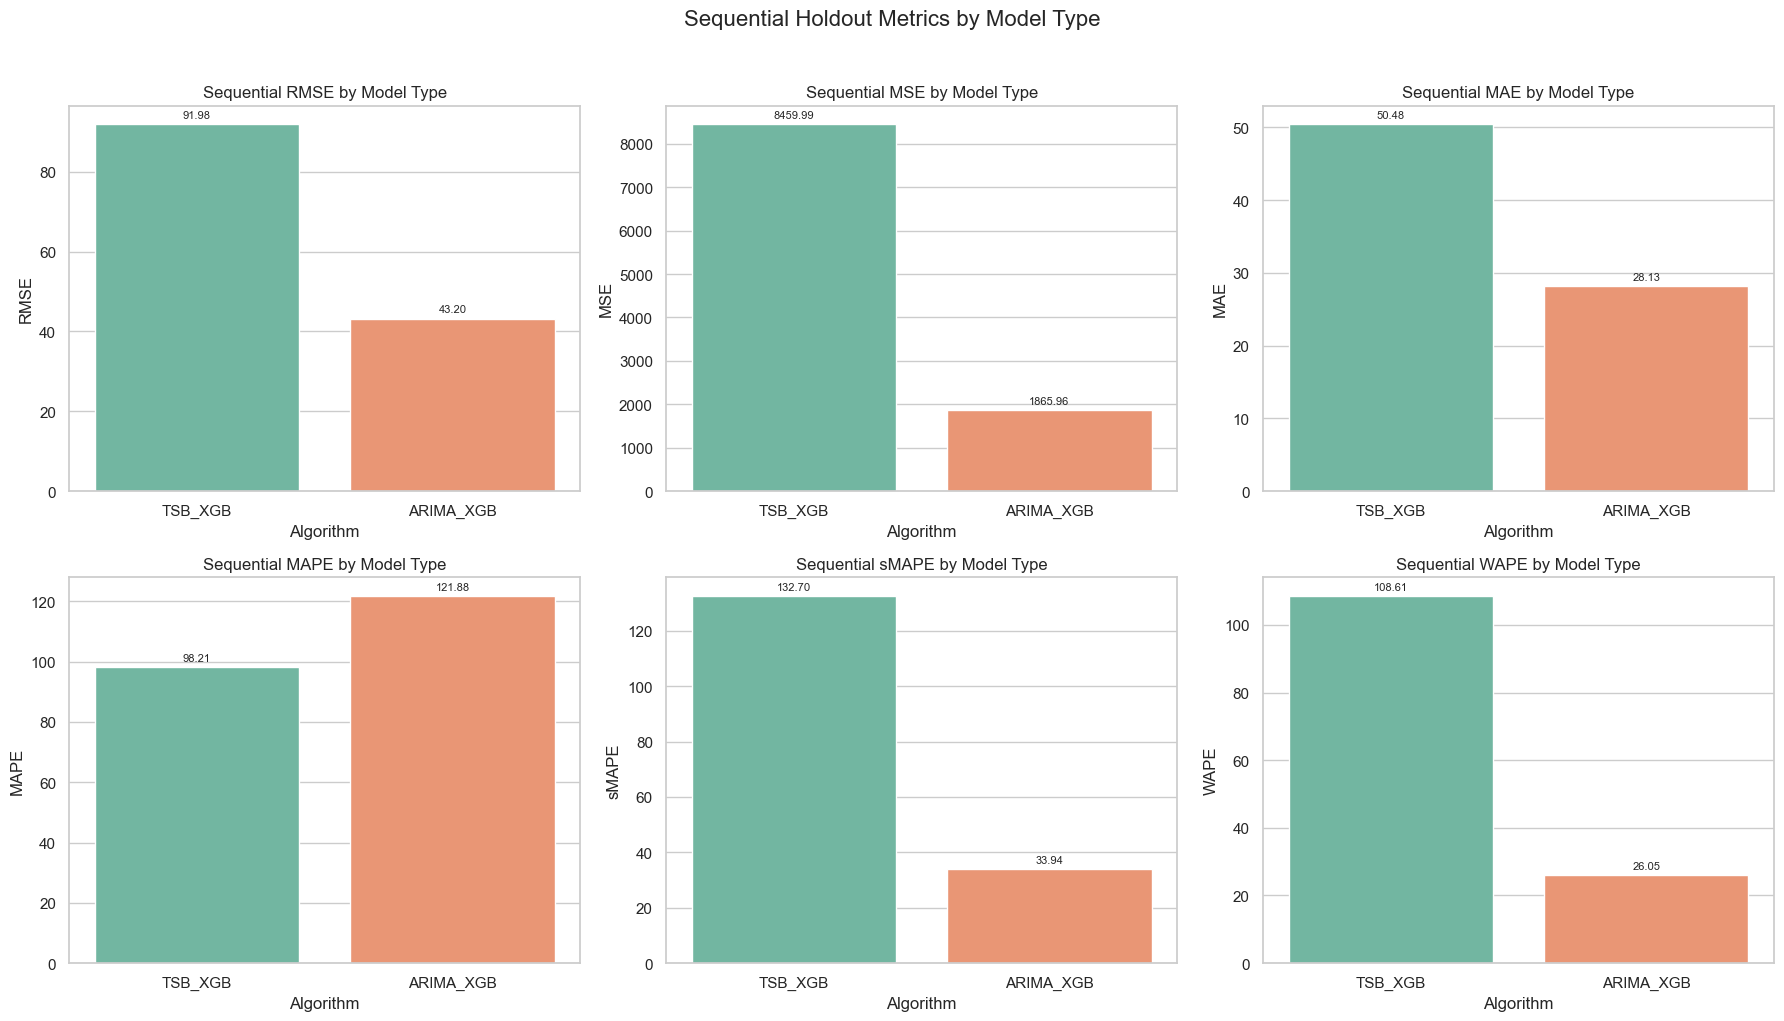

In [20]:
metric_epoch_rows = []
for _, summary_row in training_summary_df.iterrows():
    product_name = summary_row["product_name"]
    epoch_frame = epoch_results.get(product_name)
    if epoch_frame is None or epoch_frame.empty:
        continue

    frame = epoch_frame.copy()
    frame["product_name"] = product_name
    frame["algorithm"] = summary_row["algorithm"]
    frame["demand_type"] = summary_row["demand_type"]
    frame["series_kind"] = summary_row["series_kind"]
    metric_epoch_rows.append(frame)

if not metric_epoch_rows:
    raise ValueError("No sequential walk-forward predictions are available for metric summary.")

sequential_epoch_metrics_df = pd.concat(metric_epoch_rows, ignore_index=True)
spare_part_epoch_metrics_df = sequential_epoch_metrics_df[sequential_epoch_metrics_df["series_kind"] != "business_revenue"].copy()

model_metric_rows = []
for algorithm_name, group in spare_part_epoch_metrics_df.groupby("algorithm", sort=True):
    metrics = compute_metrics(group["actual"], group["predicted"])
    model_metric_rows.append({
        "algorithm": algorithm_name,
        "series_kind": "product",
        "trained_artifacts": int(group["product_name"].nunique()),
        "walk_forward_predictions": int(len(group)),
        "mape_observations": int(group["actual"].ne(0).sum()),
        **metrics,
    })

model_metric_summary = pd.DataFrame(model_metric_rows).sort_values("MAPE").reset_index(drop=True)

display(Markdown("### Sequential Holdout Metrics by Model Type (Spare Parts Only)"))
display(model_metric_summary)

business_revenue_metric_summary = pd.DataFrame()
revenue_epoch_metrics_df = sequential_epoch_metrics_df[sequential_epoch_metrics_df["series_kind"] == "business_revenue"].copy()
if not revenue_epoch_metrics_df.empty:
    revenue_metrics = compute_metrics(revenue_epoch_metrics_df["actual"], revenue_epoch_metrics_df["predicted"])
    business_revenue_metric_summary = pd.DataFrame([{
        "series_kind": "business_revenue",
        "trained_artifacts": int(revenue_epoch_metrics_df["product_name"].nunique()),
        "walk_forward_predictions": int(len(revenue_epoch_metrics_df)),
        "mape_observations": int(revenue_epoch_metrics_df["actual"].ne(0).sum()),
        **revenue_metrics,
    }])
    display(Markdown("### Sequential Holdout Metrics for Business Revenue"))
    display(business_revenue_metric_summary)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
plot_metrics = METRIC_COLUMNS + ["sMAPE", "WAPE"]
for axis, metric_name in zip(axes.flatten(), plot_metrics):
    if metric_name not in model_metric_summary.columns:
        axis.set_visible(False)
        continue
    sns.barplot(
        data=model_metric_summary,
        x="algorithm",
        y=metric_name,
        hue="algorithm",
        dodge=False,
        palette="Set2",
        ax=axis,
    )
    axis.set_title(f"Sequential {metric_name} by Model Type")
    axis.set_xlabel("Algorithm")
    axis.set_ylabel(metric_name)
    axis.tick_params(axis="x", rotation=0)

    for container in axis.containers:
        axis.bar_label(container, fmt="%.2f", fontsize=8, padding=3)

    if metric_name in {"MSE", "RMSE", "MAE"}:
        axis.ticklabel_format(style="plain", axis="y")

    legend = axis.get_legend()
    if legend is not None:
        legend.remove()

fig.suptitle("Sequential Holdout Metrics by Model Type", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## Sequential Metrics Bar Graph

This graph compares RMSE, MSE, MAE, and MAPE from the sequential walk-forward training results. Spare-part bars are grouped by trained algorithm, while the monthly business forecast is shown separately because its scale is much larger.


metric,group,series,MAE,MAPE,MSE,RMSE
0,Monthly Business Forecast,Business Revenue,"3,102,862.2467",95.9055,"20,464,074,325,328.8477","4,523,723.5023"
1,Spare Parts,ARIMA_XGB,28.1350,121.8784,"1,865.9624",43.1968
2,Spare Parts,TSB_XGB,50.4835,98.2098,"8,459.9859",91.9782


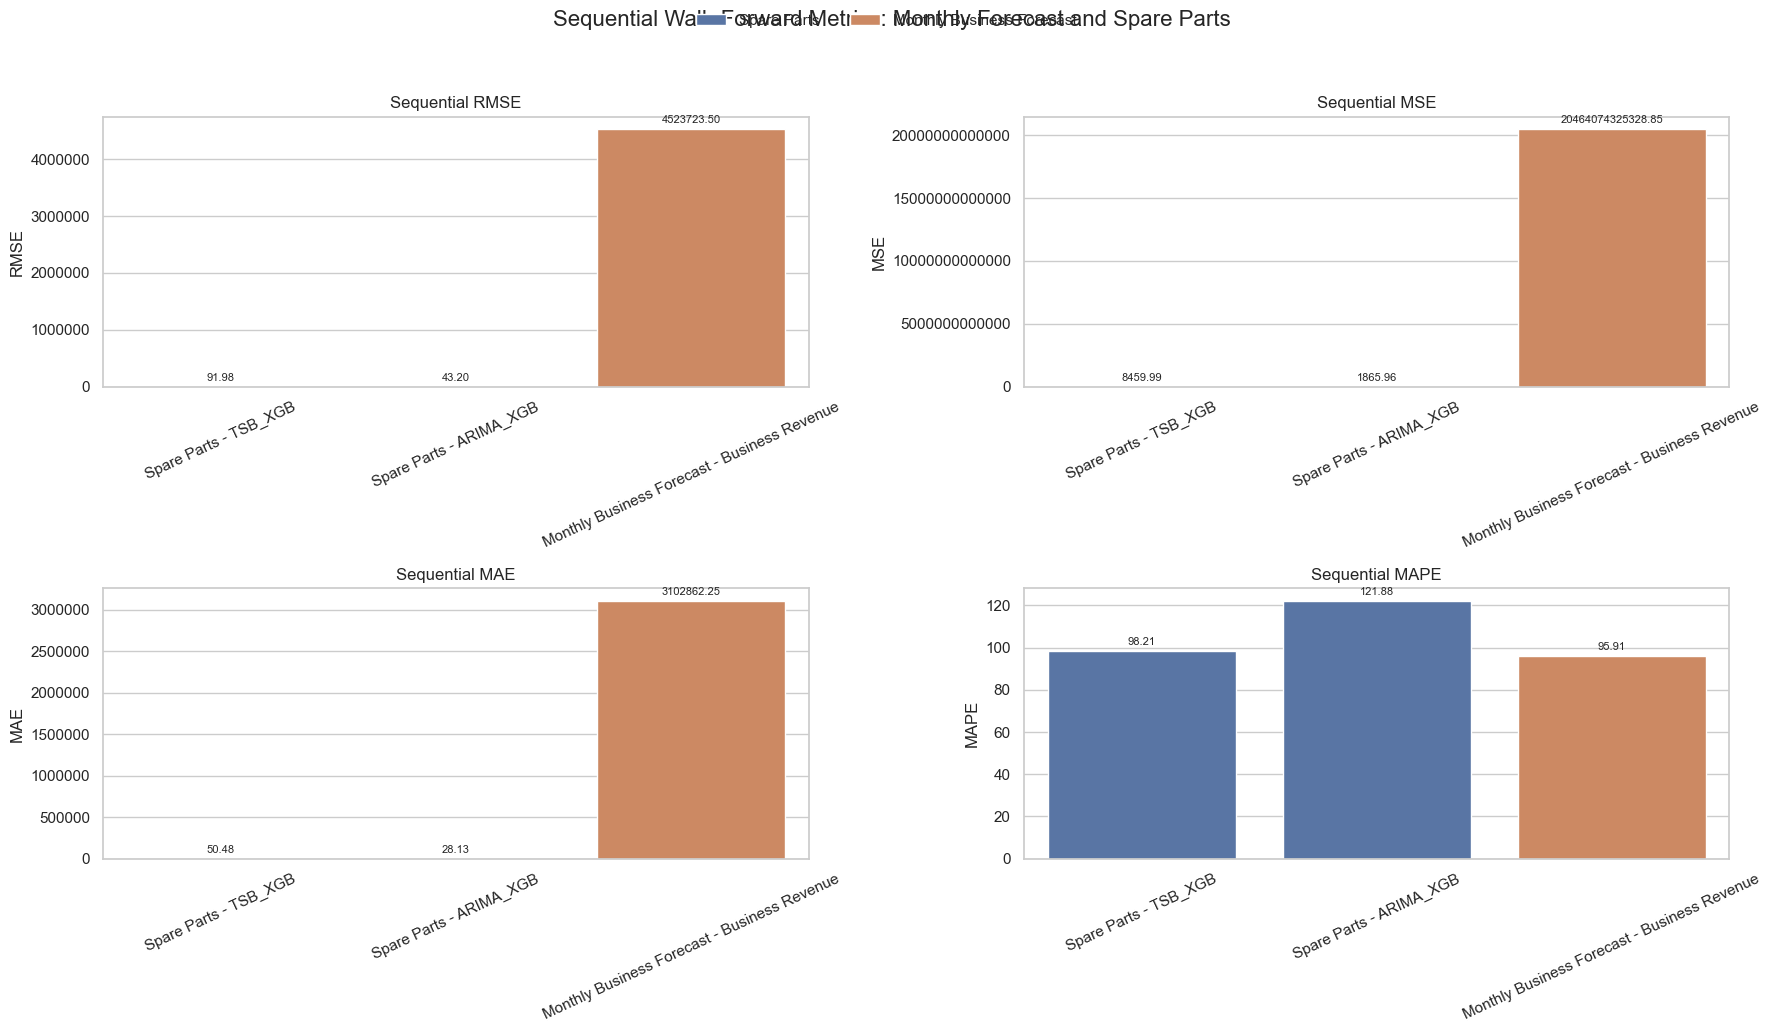

In [21]:
bar_metric_rows = []

if 'model_metric_summary' not in globals() or model_metric_summary.empty:
    raise ValueError("Run the Metrics by Model Type cell before building the sequential metrics bar graph.")

for _, row in model_metric_summary.iterrows():
    for metric_name in METRIC_COLUMNS:
        bar_metric_rows.append({
            "group": "Spare Parts",
            "series": row["algorithm"],
            "metric": metric_name,
            "value": row[metric_name],
        })

if 'business_revenue_metric_summary' in globals() and not business_revenue_metric_summary.empty:
    revenue_row = business_revenue_metric_summary.iloc[0]
    for metric_name in METRIC_COLUMNS:
        bar_metric_rows.append({
            "group": "Monthly Business Forecast",
            "series": "Business Revenue",
            "metric": metric_name,
            "value": revenue_row[metric_name],
        })

sequential_metric_bar_df = pd.DataFrame(bar_metric_rows)
display(sequential_metric_bar_df.pivot_table(index=["group", "series"], columns="metric", values="value").reset_index())

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for axis, metric_name in zip(axes.flatten(), METRIC_COLUMNS):
    metric_frame = sequential_metric_bar_df[sequential_metric_bar_df["metric"] == metric_name].copy()
    metric_frame["label"] = metric_frame["group"] + " - " + metric_frame["series"]

    sns.barplot(data=metric_frame, x="label", y="value", hue="group", dodge=False, ax=axis)
    axis.set_title(f"Sequential {metric_name}")
    axis.set_xlabel("")
    axis.set_ylabel(metric_name)
    axis.tick_params(axis="x", rotation=25)
    axis.bar_label(axis.containers[0], fmt="%.2f", fontsize=8, padding=3)
    if len(axis.containers) > 1:
        for container in axis.containers[1:]:
            axis.bar_label(container, fmt="%.2f", fontsize=8, padding=3)
    if metric_name in {"MSE", "RMSE", "MAE"}:
        axis.ticklabel_format(style="plain", axis="y")
    legend = axis.get_legend()
    if legend is not None:
        legend.remove()

handles, labels = axes.flatten()[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
fig.suptitle("Sequential Walk-Forward Metrics: Monthly Forecast and Spare Parts", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()


## Initial vs Retrain Parameter Comparison

This section reruns the same sequential walk-forward holdout periods with the model's retrain/extended parameters, then compares them against the initial-parameter sequential results. The detected spare parts and monthly business revenue are included, and the selected training window is held constant so the comparison isolates the parameter change.

c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

### Initial vs Retrain Parameter Metric Deltas

,product_name,series_kind,algorithm,demand_type,selected_training_window,metric,initial_value,retrain_value,improvement_value,improvement_pct,improved
0,Business Total Revenue,business_revenue,ARIMA_XGB,ERRATIC,48 Months,Accuracy,4.0945,1.6737,-2.4207,-59.1220,False
1,Business Total Revenue,business_revenue,ARIMA_XGB,ERRATIC,48 Months,MAE,"3,102,862.2467","3,251,894.0083","-149,031.7617",-4.8030,False
2,Business Total Revenue,business_revenue,ARIMA_XGB,ERRATIC,48 Months,MAPE,95.9055,98.3263,-2.4207,-2.5241,False
3,Business Total Revenue,business_revenue,ARIMA_XGB,ERRATIC,48 Months,MSE,"20,464,074,325,328.8477","20,598,139,697,632.9531","-134,065,372,304.1055",-0.6551,False
4,Business Total Revenue,business_revenue,ARIMA_XGB,ERRATIC,48 Months,RMSE,"4,523,723.5023","4,538,517.3457","-14,793.8434",-0.3270,False
...,...,...,...,...,...,...,...,...,...,...,...
72,Wheel Bearing,product,ARIMA_XGB,ERRATIC,All History,MAPE,155.8869,150.7823,5.1046,3.2746,True
73,Wheel Bearing,product,ARIMA_XGB,ERRATIC,All History,MSE,"3,292.3954","2,947.4794",344.9160,10.4761,True
74,Wheel Bearing,product,ARIMA_XGB,ERRATIC,All History,RMSE,57.3794,54.2907,3.0887,5.3830,True
75,Wheel Bearing,product,ARIMA_XGB,ERRATIC,All History,WAPE,42.5671,45.2807,-2.7136,-6.3749,False


### Initial vs Retrain Parameter Graphs

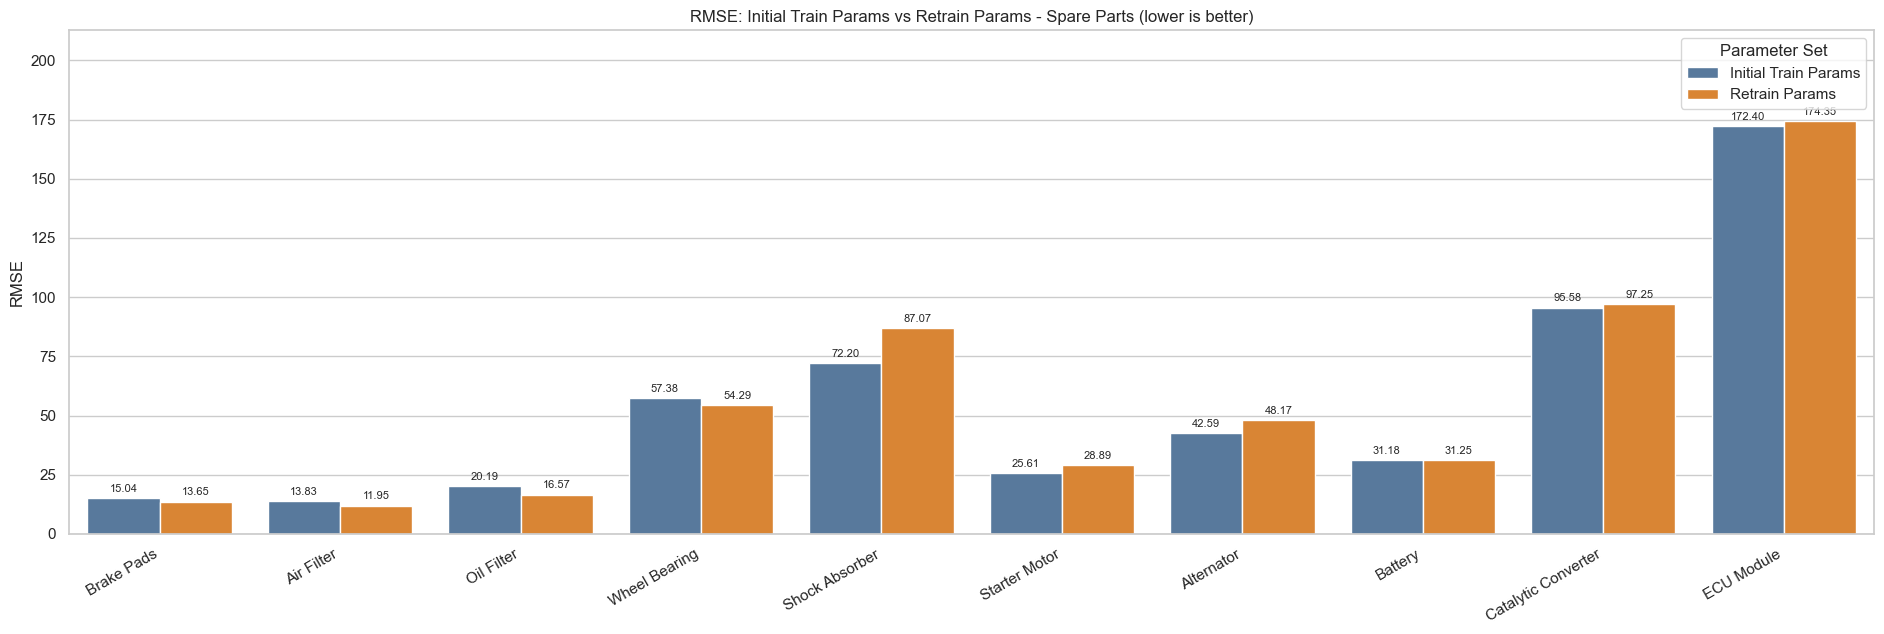

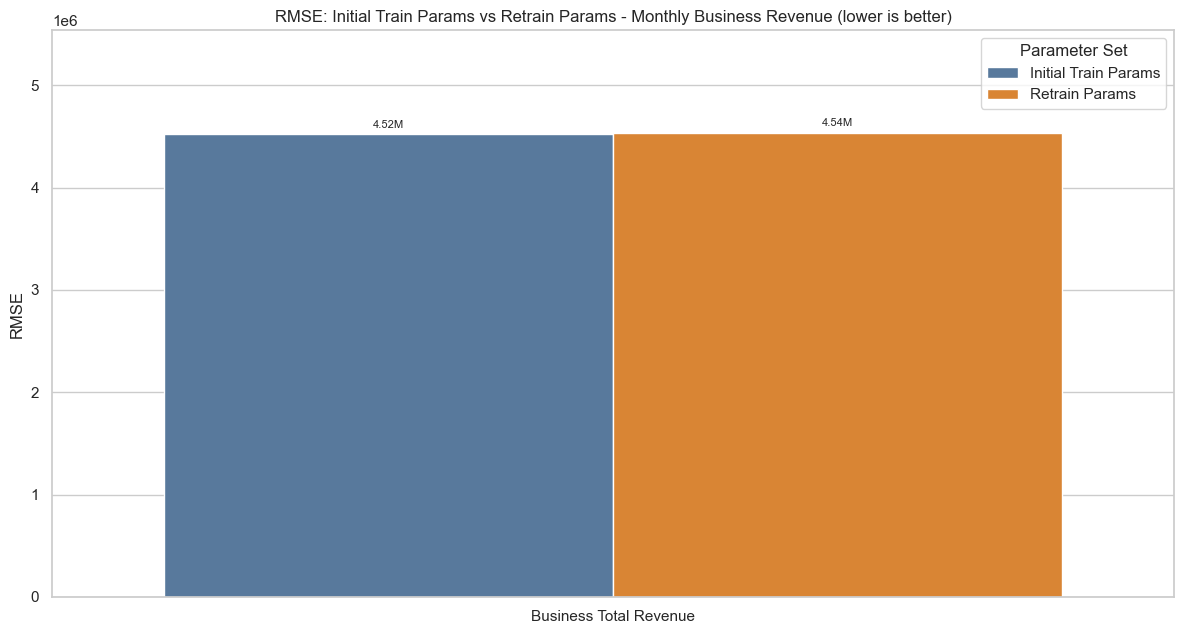

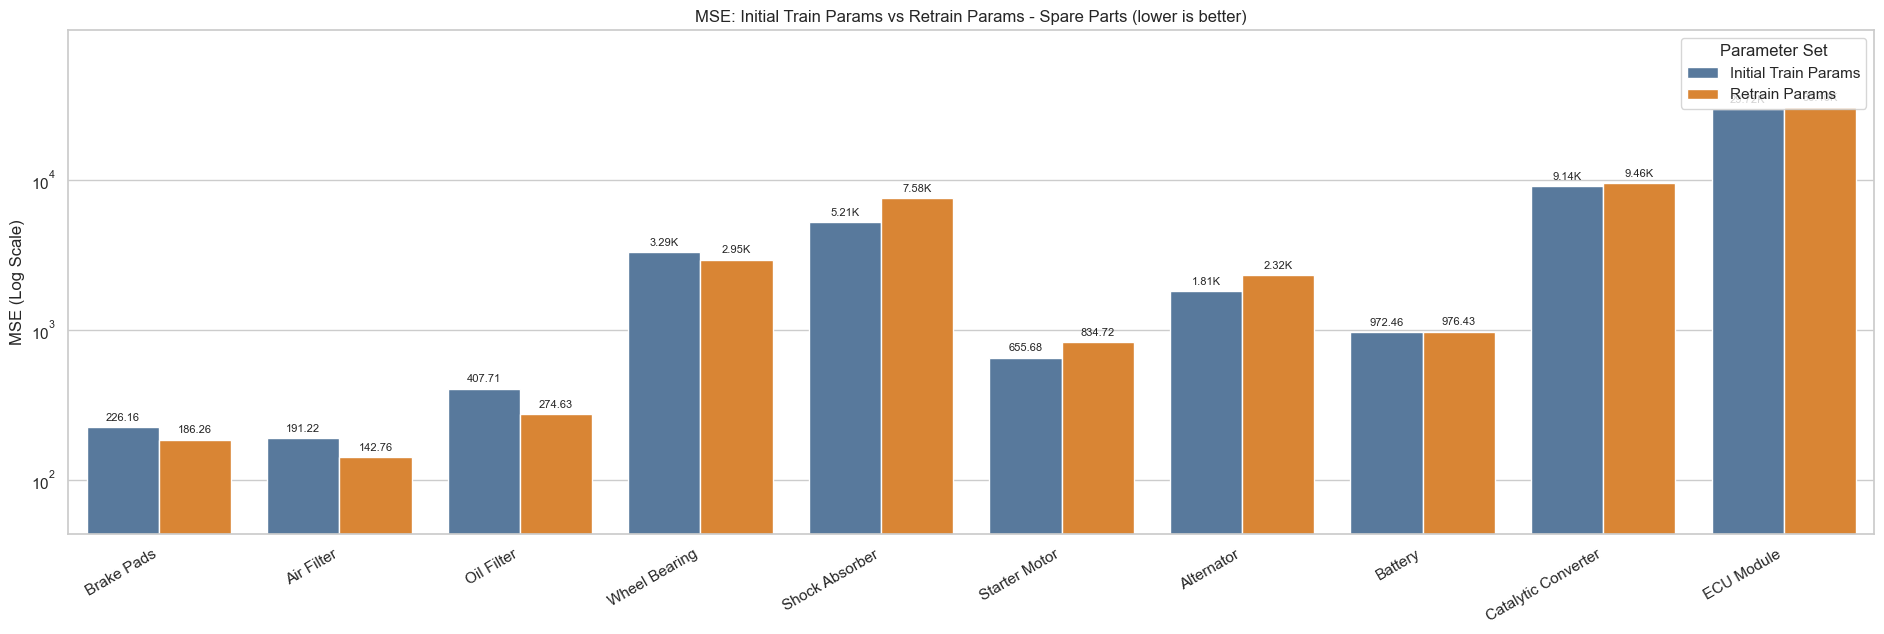

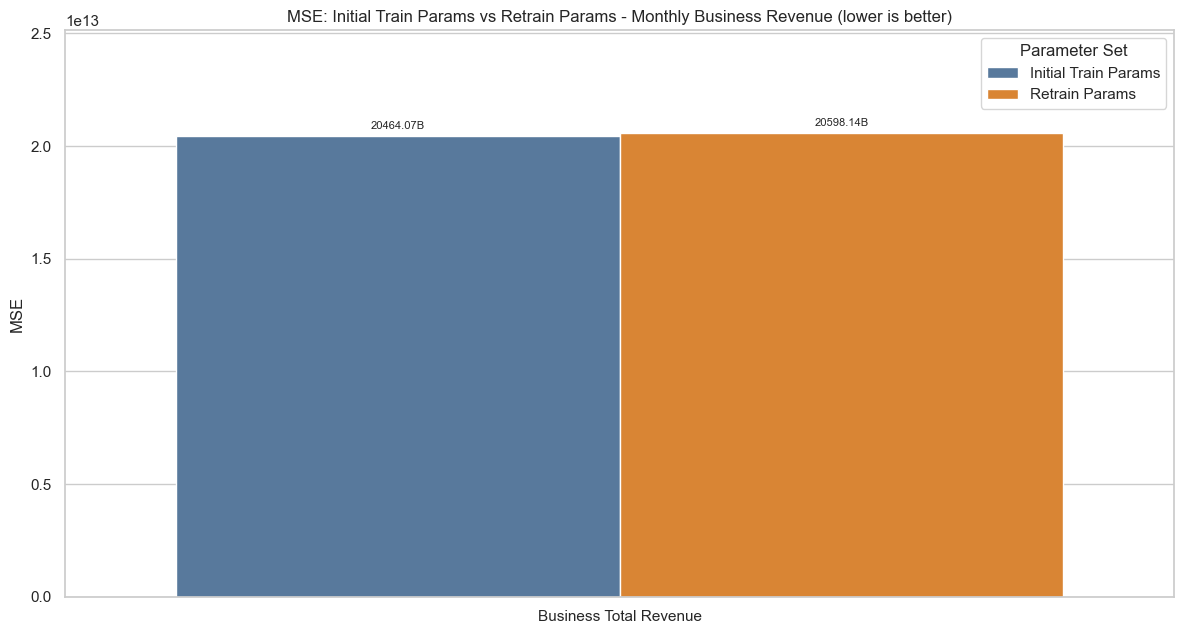

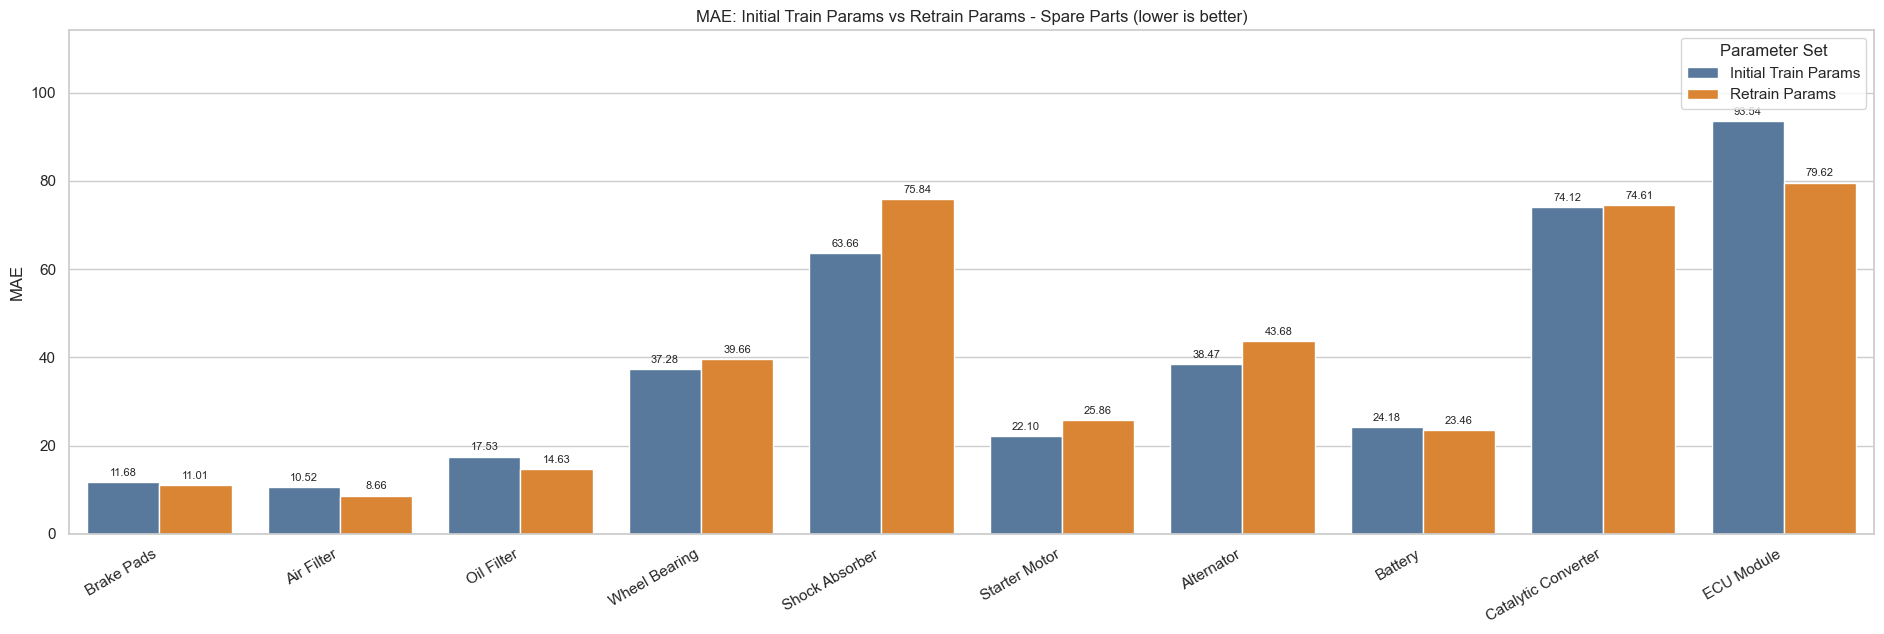

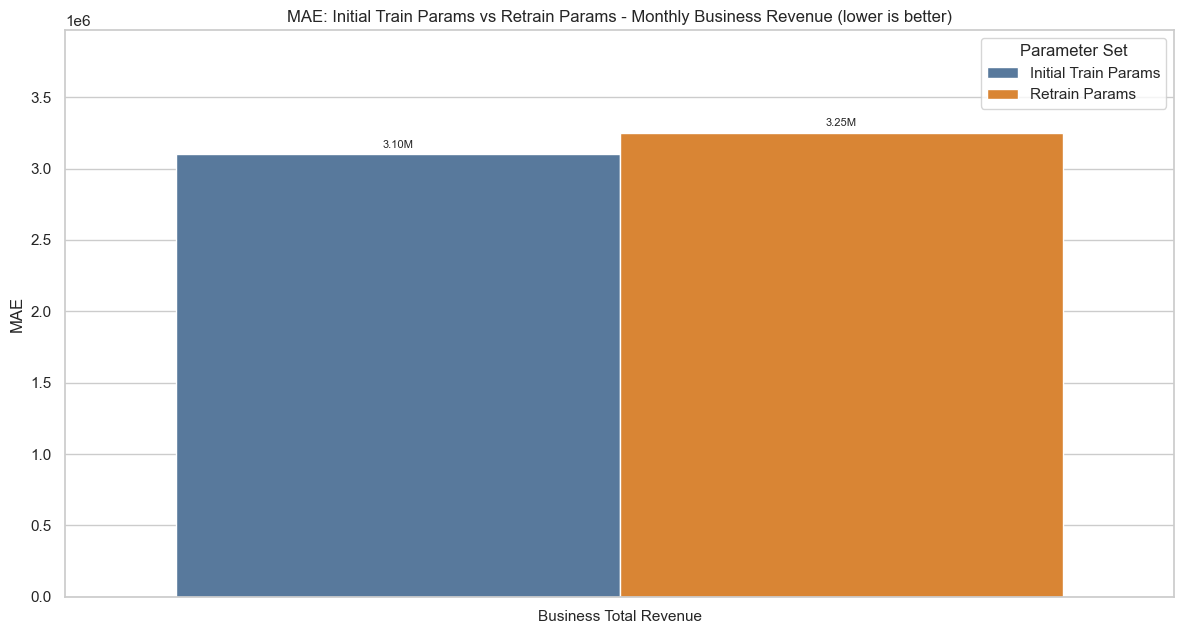

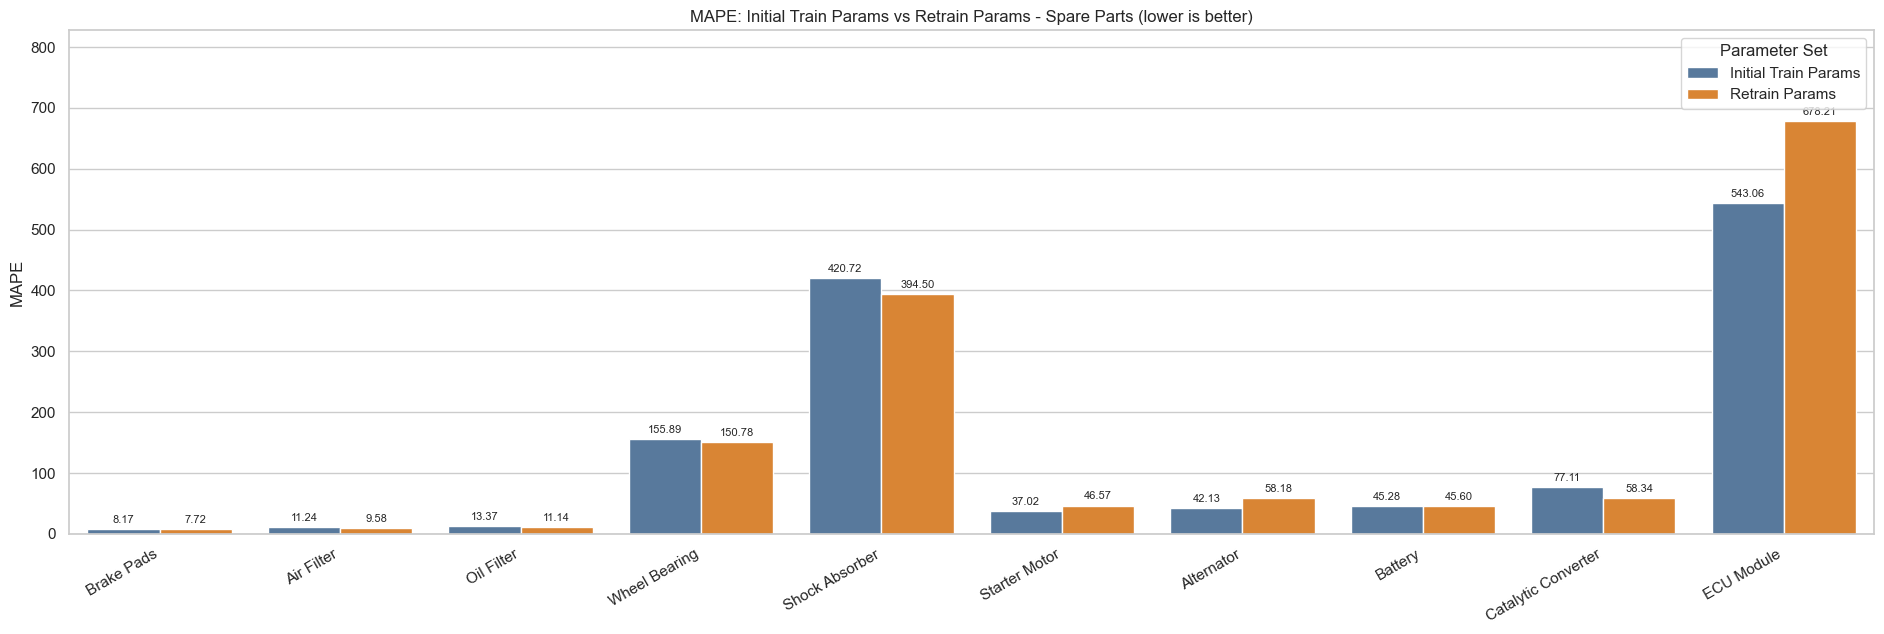

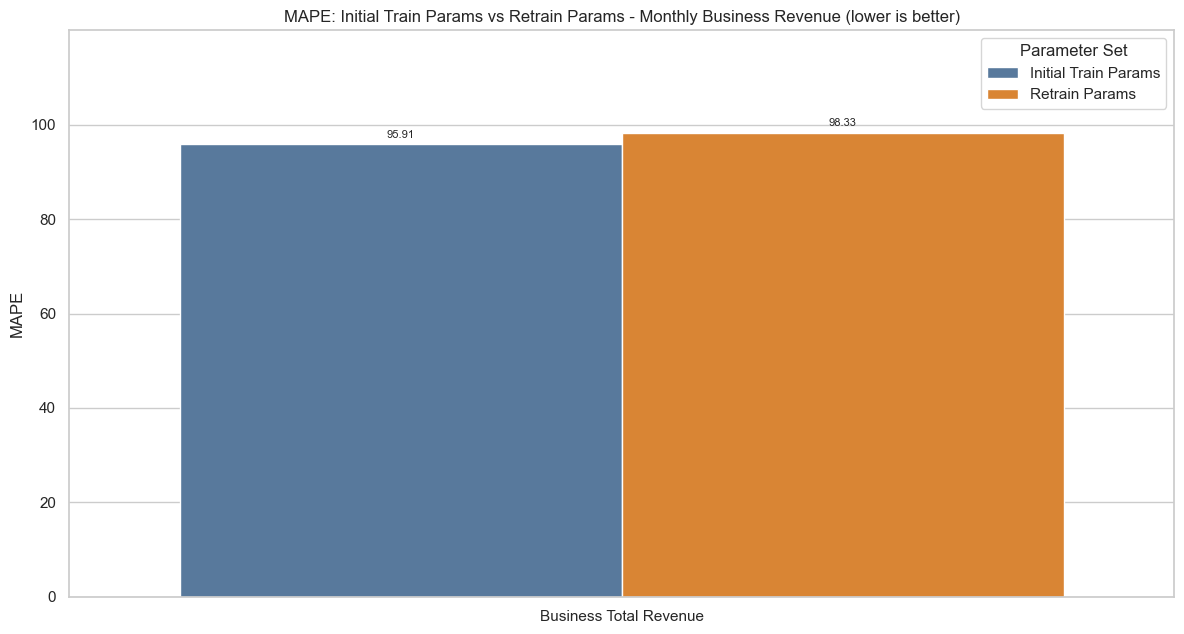

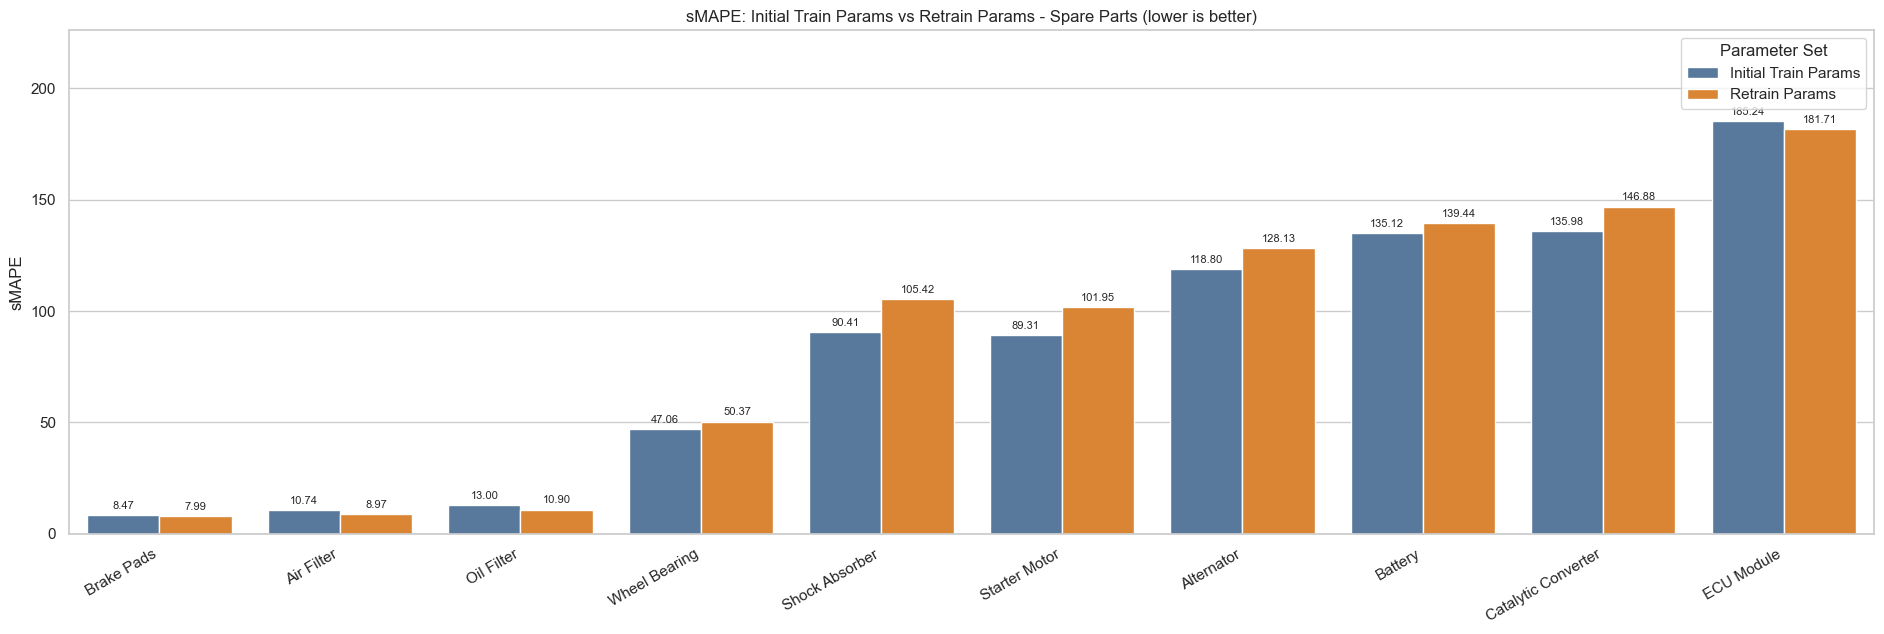

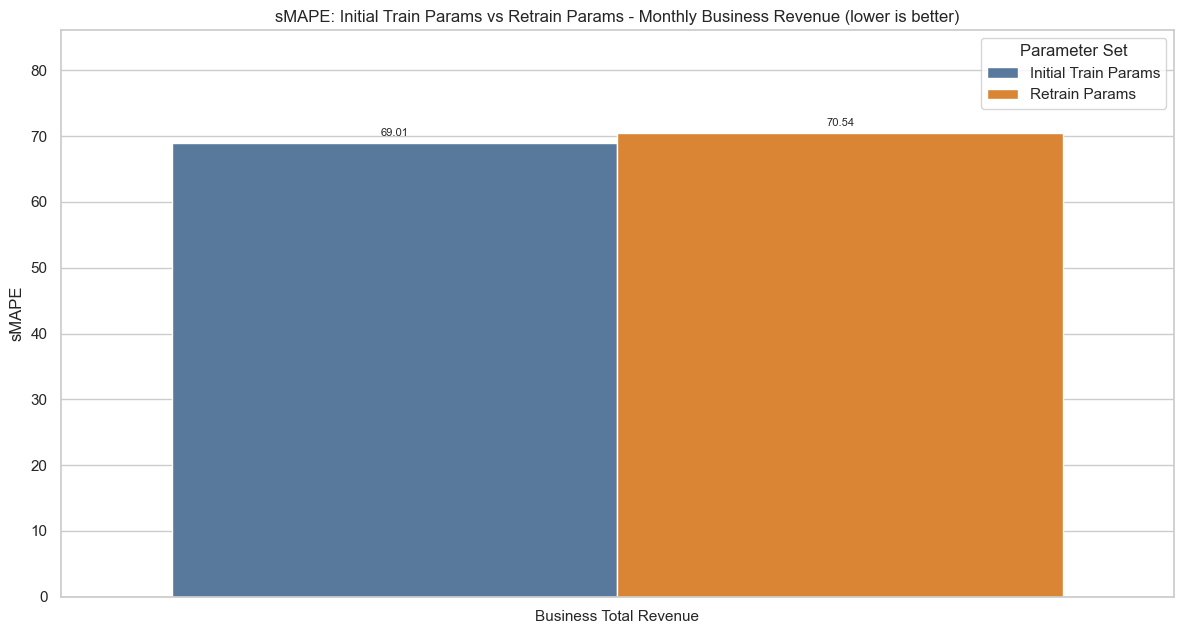

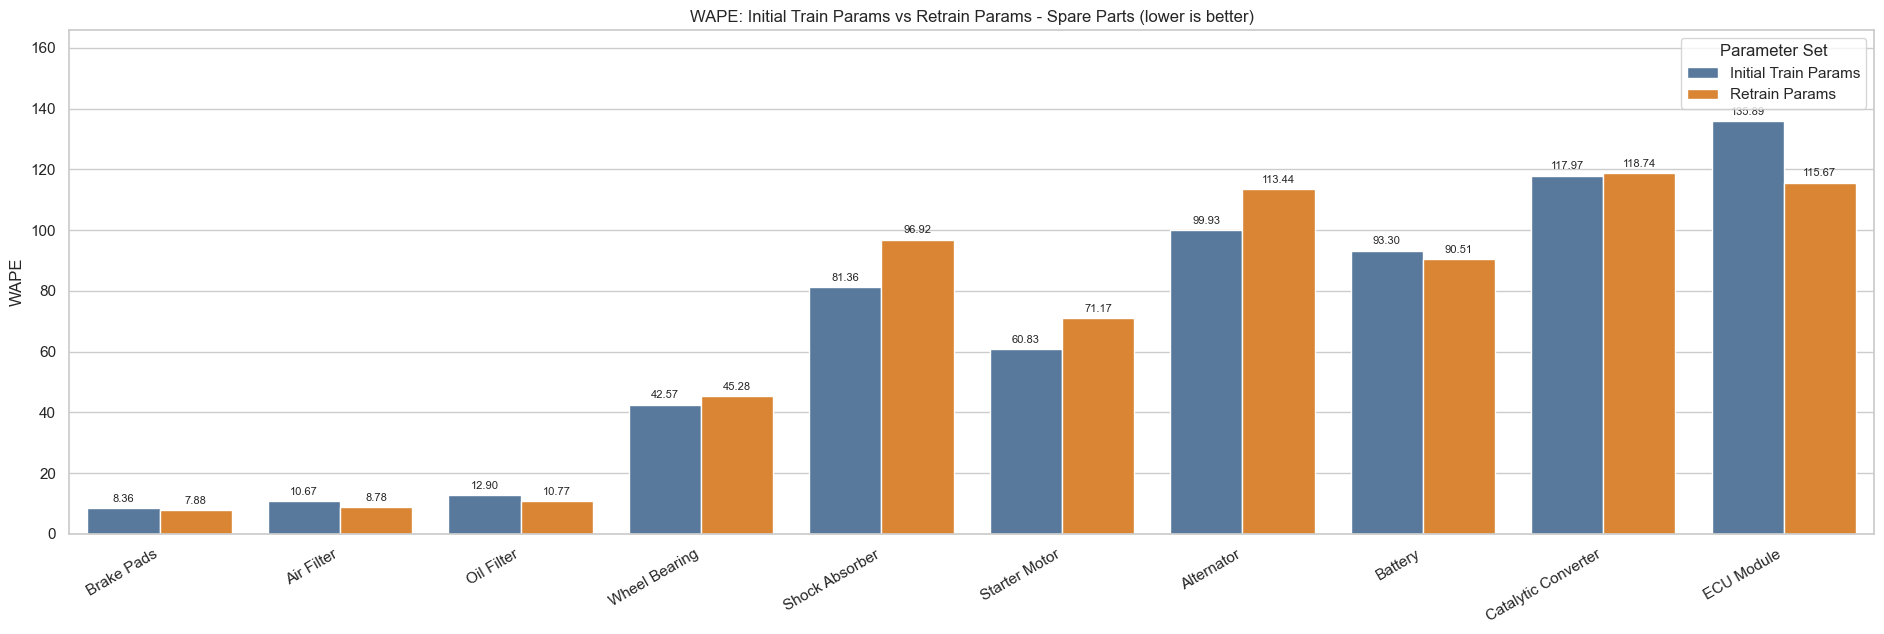

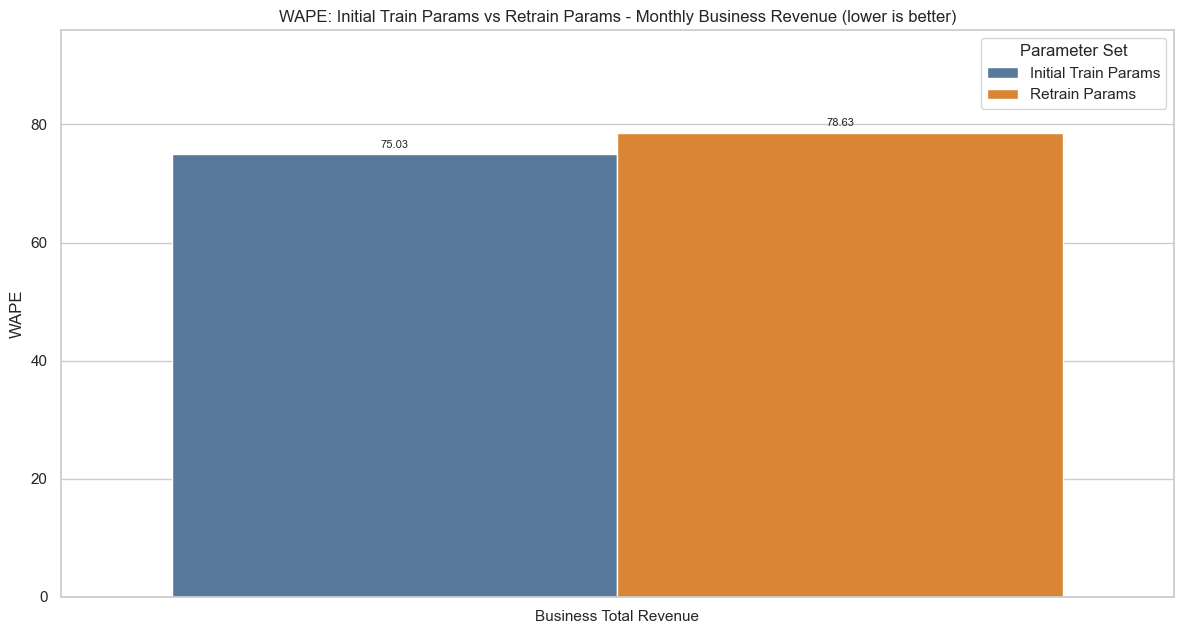

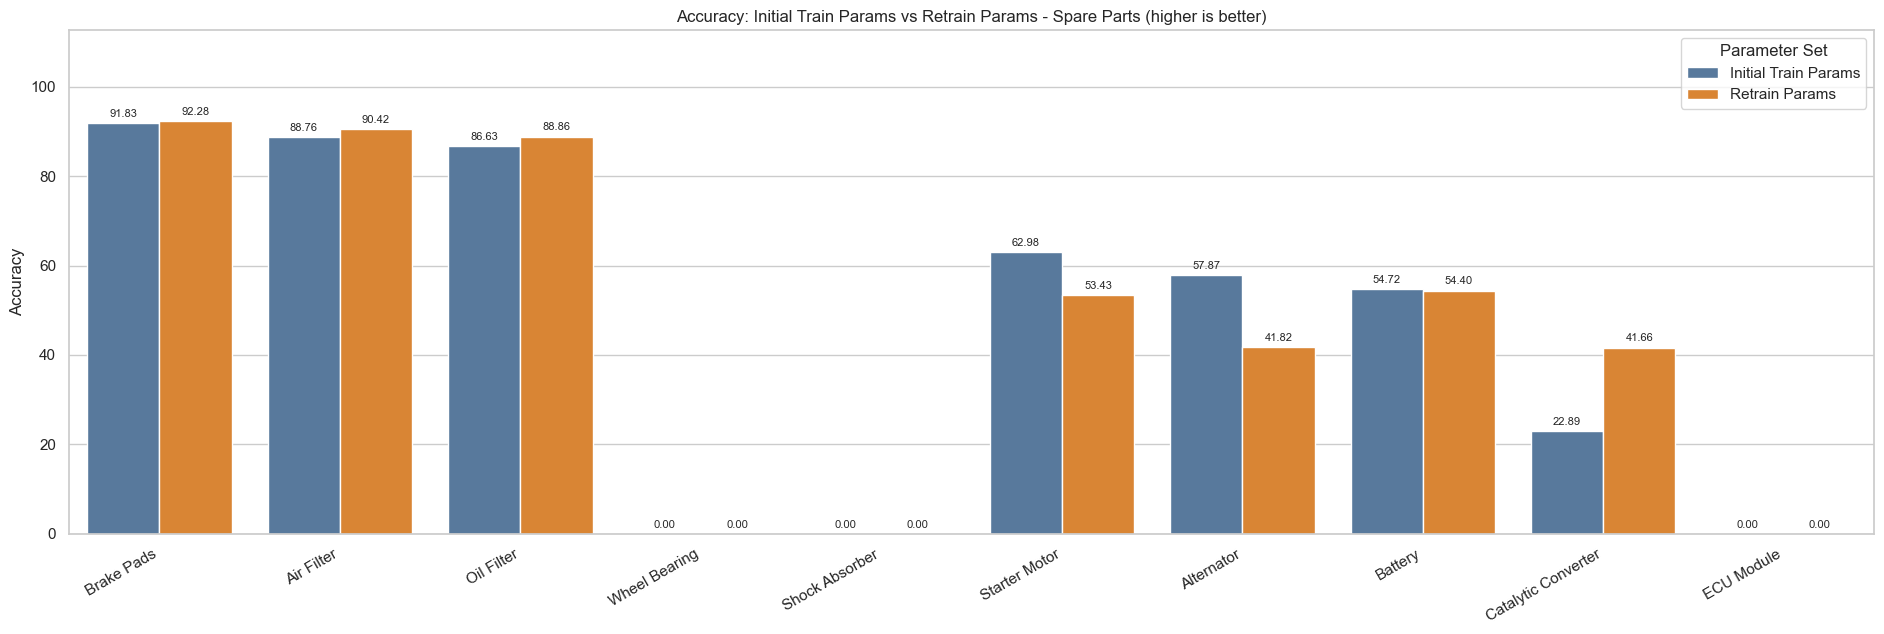

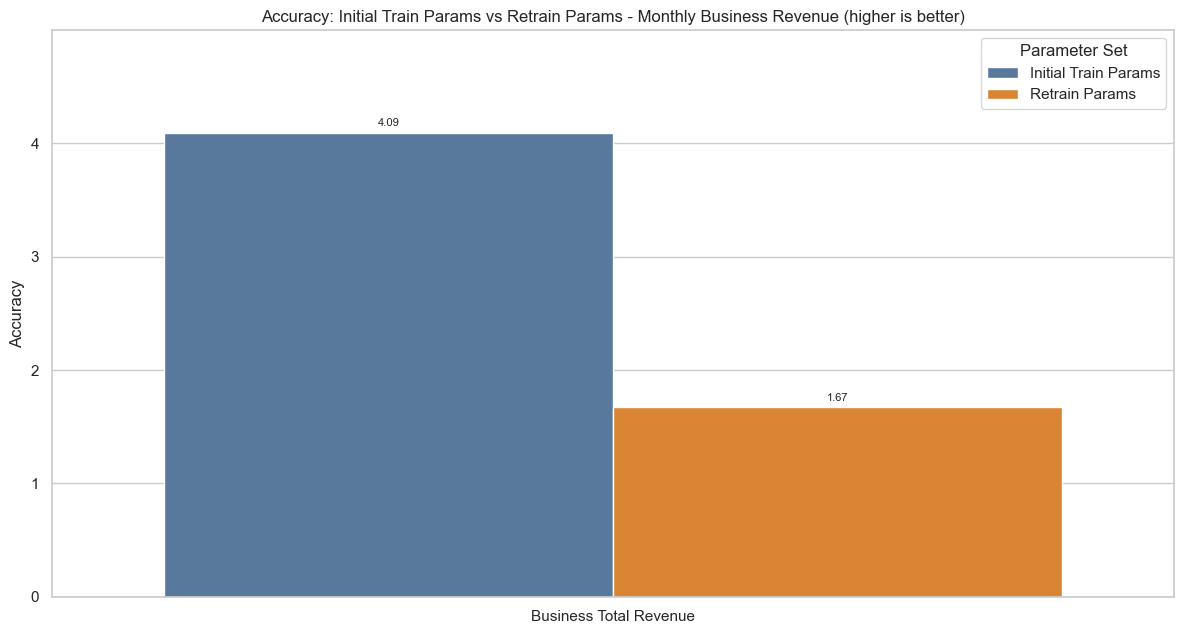

In [22]:
PARAMETER_COMPARISON_METRICS = ['RMSE', 'MSE', 'MAE', 'MAPE', 'sMAPE', 'WAPE', 'Accuracy']
INITIAL_MODE_LABEL = 'Initial Train Params'
RETRAIN_MODE_LABEL = 'Retrain Params'


def format_metric_label(value):
    if pd.isna(value) or not np.isfinite(value):
        return ''
    value = float(value)
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f'{value / 1_000_000_000:.2f}B'
    if abs_value >= 1_000_000:
        return f'{value / 1_000_000:.2f}M'
    if abs_value >= 1_000:
        return f'{value / 1_000:.2f}K'
    return f'{value:.2f}'


if 'training_summary_df' not in globals() or training_summary_df.empty:
    raise ValueError('Run the Sequential Training by Classified Model cell first.')
if 'trainer_map' not in globals():
    raise ValueError('trainer_map is not available. Run the training cell first.')

parameter_comparison_rows = []
parameter_comparison_epoch_results = {}

for _, summary_row in training_summary_df.iterrows():
    product_name = summary_row['product_name']
    algorithm = summary_row['algorithm']
    series_kind = summary_row.get('series_kind', 'product')

    if series_kind == 'business_revenue':
        product_history = business_revenue_series.sort_values('period').reset_index(drop=True).copy()
    else:
        product_history = monthly_sales[monthly_sales[PRODUCT_COLUMN] == product_name].sort_values('period').reset_index(drop=True).copy()

    dates = product_history['period_str'].tolist()
    quantities = product_history[QUANTITY_COLUMN].astype(float).tolist()
    selected_training_window = parse_training_window_label(summary_row.get('selected_training_window'))
    walk_forward_epochs = int(summary_row['walk_forward_epochs']) if pd.notna(summary_row.get('walk_forward_epochs')) else recommended_walk_forward_epochs(len(dates), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS)
    forecast_fn = trainer_map[algorithm]['forecast_fn']

    initial_epoch_frame = epoch_results.get(product_name)
    if initial_epoch_frame is None or initial_epoch_frame.empty:
        initial_epoch_frame = run_sequential_epochs(
            dates=dates,
            quantities=quantities,
            train_fn=make_parameter_train_fn(algorithm, 'initial'),
            forecast_fn=forecast_fn,
            min_train_size=MIN_TRAIN_SIZE,
            test_size=walk_forward_epochs,
            training_window=selected_training_window,
        )

    retrain_epoch_frame = run_sequential_epochs(
        dates=dates,
        quantities=quantities,
        train_fn=make_parameter_train_fn(algorithm, 'retrain'),
        forecast_fn=forecast_fn,
        min_train_size=MIN_TRAIN_SIZE,
        test_size=walk_forward_epochs,
        training_window=selected_training_window,
    )

    parameter_comparison_epoch_results[(product_name, INITIAL_MODE_LABEL)] = initial_epoch_frame
    parameter_comparison_epoch_results[(product_name, RETRAIN_MODE_LABEL)] = retrain_epoch_frame

    for parameter_mode, epoch_frame in [(INITIAL_MODE_LABEL, initial_epoch_frame), (RETRAIN_MODE_LABEL, retrain_epoch_frame)]:
        metrics = compute_metrics(epoch_frame['actual'], epoch_frame['predicted'])
        metrics['Accuracy'] = max(0, 100 - metrics['MAPE']) if pd.notna(metrics['MAPE']) else np.nan
        for metric_name in PARAMETER_COMPARISON_METRICS:
            parameter_comparison_rows.append({
                'product_name': product_name,
                'series_kind': series_kind,
                'algorithm': algorithm,
                'demand_type': summary_row['demand_type'],
                'selected_training_window': training_window_label(selected_training_window),
                'parameter_mode': parameter_mode,
                'metric': metric_name,
                'value': metrics.get(metric_name, np.nan),
            })

parameter_comparison_long_df = pd.DataFrame(parameter_comparison_rows)
if parameter_comparison_long_df.empty:
    raise ValueError('No parameter-comparison metrics were generated.')

delta_rows = []
group_columns = ['product_name', 'series_kind', 'algorithm', 'demand_type', 'selected_training_window', 'metric']
for group_values, group in parameter_comparison_long_df.groupby(group_columns, dropna=False):
    values_by_mode = group.set_index('parameter_mode')['value']
    initial_value = values_by_mode.get(INITIAL_MODE_LABEL, np.nan)
    retrain_value = values_by_mode.get(RETRAIN_MODE_LABEL, np.nan)
    metric_name = group_values[-1]
    if pd.isna(initial_value) or pd.isna(retrain_value):
        improvement = np.nan
    elif metric_name == 'Accuracy':
        improvement = retrain_value - initial_value
    else:
        improvement = initial_value - retrain_value
    improvement_pct = improvement / abs(initial_value) * 100 if pd.notna(improvement) and pd.notna(initial_value) and initial_value != 0 else np.nan
    delta_rows.append({
        'product_name': group_values[0],
        'series_kind': group_values[1],
        'algorithm': group_values[2],
        'demand_type': group_values[3],
        'selected_training_window': group_values[4],
        'metric': metric_name,
        'initial_value': initial_value,
        'retrain_value': retrain_value,
        'improvement_value': improvement,
        'improvement_pct': improvement_pct,
        'improved': bool(pd.notna(improvement) and improvement > 0),
    })

parameter_comparison_delta_df = pd.DataFrame(delta_rows).sort_values(['series_kind', 'product_name', 'metric']).reset_index(drop=True)
display(Markdown('### Initial vs Retrain Parameter Metric Deltas'))
display(parameter_comparison_delta_df)

display(Markdown('### Initial vs Retrain Parameter Graphs'))
for metric_name in PARAMETER_COMPARISON_METRICS:
    metric_frame = parameter_comparison_long_df[parameter_comparison_long_df['metric'] == metric_name].copy()
    metric_frame['value'] = pd.to_numeric(metric_frame['value'], errors='coerce')
    metric_frame = metric_frame[np.isfinite(metric_frame['value'])]
    if metric_frame.empty:
        continue

    chart_groups = [
        ('Spare Parts', metric_frame[metric_frame['series_kind'] != 'business_revenue']),
        ('Monthly Business Revenue', metric_frame[metric_frame['series_kind'] == 'business_revenue']),
    ]

    for chart_label, chart_frame in chart_groups:
        if chart_frame.empty:
            continue

        fig_width = max(12, min(22, 4 + 1.5 * chart_frame['product_name'].nunique()))
        fig, axis = plt.subplots(figsize=(fig_width, 6.5))
        sns.barplot(
            data=chart_frame,
            x='product_name',
            y='value',
            hue='parameter_mode',
            hue_order=[INITIAL_MODE_LABEL, RETRAIN_MODE_LABEL],
            palette=['#4c78a8', '#f58518'],
            ax=axis,
        )

        lower_or_higher = 'higher is better' if metric_name == 'Accuracy' else 'lower is better'
        axis.set_title(f'{metric_name}: Initial Train Params vs Retrain Params - {chart_label} ({lower_or_higher})')
        axis.set_xlabel('')
        axis.set_ylabel(metric_name)

        positive_values = chart_frame.loc[chart_frame['value'] > 0, 'value']
        use_log_scale = metric_name in {'RMSE', 'MSE', 'MAE'} and len(positive_values) > 1 and positive_values.max() / positive_values.min() >= 20
        if use_log_scale:
            axis.set_yscale('log')
            axis.set_ylabel(f'{metric_name} (Log Scale)')

        rotate_labels = chart_frame['product_name'].nunique() > 3
        axis.tick_params(axis='x', rotation=30 if rotate_labels else 0)
        for tick_label in axis.get_xticklabels():
            tick_label.set_ha('right' if rotate_labels else 'center')

        for container in axis.containers:
            labels = [format_metric_label(bar.get_height()) for bar in container]
            axis.bar_label(container, labels=labels, padding=3, fontsize=8)

        axis.margins(y=0.22)
        axis.legend(title='Parameter Set', loc='upper right')
        plt.tight_layout()
        plt.show()


## Sequential Metric Diagnostics

These diagnostics explain why sequential RMSE, MSE, MAE, and MAPE can be high. They use the same walk-forward holdout predictions as the metric summary, then surface the worst epochs, zero-demand effects, recent volatility, and simple baseline comparisons.


In [23]:
def build_baseline_epoch_frame(values, periods, min_train_size=MIN_TRAIN_SIZE, max_epochs=MAX_WALK_FORWARD_EPOCHS):
    values = [float(value) for value in values]
    test_size = recommended_walk_forward_epochs(len(values), min_train_size=min_train_size, max_walk_forward_epochs=max_epochs)
    test_start = len(values) - test_size
    rows = []

    for target_index in range(test_start, len(values)):
        train_values = values[:target_index]
        actual_value = values[target_index]
        rows.append({
            "target_period": periods[target_index],
            "actual": actual_value,
            "last_value": train_values[-1],
            "rolling_mean_3": float(np.mean(train_values[-3:])),
            "seasonal_12": train_values[-12] if len(train_values) >= 12 else train_values[-1],
        })

    return pd.DataFrame(rows)


diagnostic_rows = []
baseline_rows = []

for _, summary_row in training_summary_df.iterrows():
    product_name = summary_row["product_name"]
    series_kind = summary_row["series_kind"]
    epoch_frame = epoch_results.get(product_name)

    if epoch_frame is None or epoch_frame.empty:
        continue

    if series_kind == "business_revenue":
        history = business_revenue_series.sort_values("period").reset_index(drop=True)
    else:
        history = monthly_sales[monthly_sales[PRODUCT_COLUMN] == product_name].sort_values("period").reset_index(drop=True)

    values = history[QUANTITY_COLUMN].astype(float).tolist()
    periods = history["period_str"].tolist()
    test_size = len(epoch_frame)
    train_values = history.iloc[:-test_size][QUANTITY_COLUMN].astype(float)
    test_values = history.iloc[-test_size:][QUANTITY_COLUMN].astype(float)
    worst_epoch = epoch_frame.sort_values("absolute_error", ascending=False).iloc[0]

    diagnostic_rows.append({
        "product_name": product_name,
        "series_kind": series_kind,
        "algorithm": summary_row["algorithm"],
        "demand_type": summary_row["demand_type"],
        "test_months": int(test_size),
        "train_mean": float(train_values.mean()),
        "test_mean": float(test_values.mean()),
        "test_min": float(test_values.min()),
        "test_max": float(test_values.max()),
        "test_cv": float(test_values.std() / test_values.mean()) if test_values.mean() else np.nan,
        "zero_test_months": int((test_values == 0).sum()),
        "RMSE": summary_row["RMSE"],
        "MAE": summary_row["MAE"],
        "MAPE": summary_row["MAPE"],
        "sMAPE": summary_row.get("sMAPE", np.nan),
        "WAPE": summary_row.get("WAPE", np.nan),
        "worst_period": worst_epoch["target_period"],
        "worst_actual": worst_epoch["actual"],
        "worst_predicted": worst_epoch["predicted"],
        "worst_absolute_error": worst_epoch["absolute_error"],
        "worst_ape": (worst_epoch["absolute_error"] / abs(worst_epoch["actual"]) * 100) if worst_epoch["actual"] != 0 else np.nan,
    })

    baseline_frame = build_baseline_epoch_frame(values, periods)
    for baseline_name in ["last_value", "rolling_mean_3", "seasonal_12"]:
        baseline_metrics = compute_metrics(baseline_frame["actual"], baseline_frame[baseline_name])
        baseline_rows.append({
            "product_name": product_name,
            "series_kind": series_kind,
            "algorithm": summary_row["algorithm"],
            "baseline": baseline_name,
            **baseline_metrics,
        })

sequential_metric_diagnostics_df = pd.DataFrame(diagnostic_rows).sort_values(["series_kind", "MAPE"], ascending=[False, False]).reset_index(drop=True)
baseline_metric_comparison_df = pd.DataFrame(baseline_rows)

display(Markdown("### Error Drivers by Trained Series"))
display(sequential_metric_diagnostics_df)

display(Markdown("### Simple Baseline Comparison"))
display(baseline_metric_comparison_df.sort_values(["series_kind", "product_name", "MAPE"], ascending=[False, True, True]).reset_index(drop=True))

display(Markdown("### Worst Sequential Holdout Epochs"))
worst_epoch_diagnostics_df = sequential_epoch_metrics_df.copy()
worst_epoch_diagnostics_df["absolute_percentage_error"] = np.where(
    worst_epoch_diagnostics_df["actual"] != 0,
    worst_epoch_diagnostics_df["absolute_error"] / worst_epoch_diagnostics_df["actual"].abs() * 100,
    np.nan,
)
display(
    worst_epoch_diagnostics_df.sort_values("absolute_error", ascending=False)
    [["product_name", "series_kind", "algorithm", "target_period", "actual", "predicted", "absolute_error", "absolute_percentage_error"]]
    .head(25)
)


### Error Drivers by Trained Series

,product_name,series_kind,algorithm,demand_type,test_months,train_mean,test_mean,test_min,test_max,test_cv,zero_test_months,RMSE,MAE,MAPE,sMAPE,WAPE,worst_period,worst_actual,worst_predicted,worst_absolute_error,worst_ape
0,ECU Module,product,TSB_XGB,LUMPY,12,87.9375,68.8333,0.0000,532.0000,2.4182,9,172.4009,93.5392,543.0585,185.2364,135.8923,2025-02,532.0000,5.6400,526.3600,98.9398
1,Shock Absorber,product,ARIMA_XGB,ERRATIC,12,131.9375,78.2500,6.0000,183.0000,0.8756,0,72.1964,63.6608,420.7250,90.4067,81.3557,2025-07,6.0000,119.9500,113.9500,"1,899.1667"
2,Wheel Bearing,product,ARIMA_XGB,ERRATIC,12,76.6042,87.5833,15.0000,183.0000,0.6677,0,57.3794,37.2817,155.8869,47.0574,42.5671,2025-12,19.0000,135.1200,116.1200,611.1579
3,Catalytic Converter,product,TSB_XGB,LUMPY,12,44.1667,62.8333,0.0000,205.0000,1.3995,6,95.5822,74.1225,77.1074,135.9792,117.9668,2025-08,173.0000,0.0000,173.0000,100.0000
4,Battery,product,TSB_XGB,INTERMITTENT,12,27.6458,25.9167,0.0000,67.0000,1.2380,7,31.1844,24.1792,45.2832,135.1150,93.2958,2025-12,63.0000,0.0000,63.0000,100.0000
5,Alternator,product,TSB_XGB,INTERMITTENT,12,44.8125,38.5000,0.0000,81.0000,0.9388,5,42.5883,38.4742,42.1290,118.8028,99.9329,2025-05,73.0000,7.3000,65.7000,90.0000
6,Starter Motor,product,TSB_XGB,INTERMITTENT,12,29.1875,36.3333,0.0000,58.0000,0.6297,3,25.6062,22.1025,37.0172,89.3142,60.8326,2025-07,0.0000,43.3500,43.3500,NaN
7,Oil Filter,product,ARIMA_XGB,SMOOTH,12,140.6667,135.8333,106.0000,164.0000,0.1164,0,20.1918,17.5283,13.3685,13.0014,12.9043,2025-09,106.0000,143.9200,37.9200,35.7736
8,Air Filter,product,ARIMA_XGB,SMOOTH,12,98.7500,98.6667,78.0000,123.0000,0.1349,0,13.8284,10.5233,11.2385,10.7410,10.6655,2025-07,78.0000,104.6500,26.6500,34.1667
9,Brake Pads,product,ARIMA_XGB,SMOOTH,12,135.0417,139.6667,120.0000,158.0000,0.0880,0,15.0385,11.6808,8.1730,8.4687,8.3634,2025-08,157.0000,117.8100,39.1900,24.9618


### Simple Baseline Comparison

,product_name,series_kind,algorithm,baseline,RMSE,MSE,MAE,MAPE,sMAPE,WAPE,LogLoss
0,Air Filter,product,ARIMA_XGB,seasonal_12,12.4130,154.0833,9.9167,10.3311,9.9844,10.0507,0.0158
1,Air Filter,product,ARIMA_XGB,rolling_mean_3,15.8351,250.7500,11.9722,12.3446,12.1662,12.1340,0.0255
2,Air Filter,product,ARIMA_XGB,last_value,20.6861,427.9167,15.9167,15.8194,16.2876,16.1318,0.0448
3,Alternator,product,TSB_XGB,seasonal_12,46.8659,"2,196.4167",33.9167,43.5908,109.2630,88.0952,7.3805
4,Alternator,product,TSB_XGB,rolling_mean_3,43.7037,"1,910.0093",40.3056,53.1577,118.2508,104.6898,6.7017
5,Alternator,product,TSB_XGB,last_value,57.3040,"3,283.7500",50.9167,76.7522,145.7316,132.2511,10.6996
6,Battery,product,TSB_XGB,seasonal_12,41.4548,"1,718.5000",28.3333,27.0166,114.7427,109.3248,7.2484
7,Battery,product,TSB_XGB,rolling_mean_3,32.0645,"1,028.1296",24.4444,46.9423,129.1852,94.3194,5.6980
8,Battery,product,TSB_XGB,last_value,40.6315,"1,650.9167",26.9167,62.7270,144.9113,103.8585,7.1956
9,Brake Pads,product,ARIMA_XGB,last_value,12.1929,148.6667,10.8333,7.8435,7.6911,7.7566,0.0073


### Worst Sequential Holdout Epochs

,product_name,series_kind,algorithm,target_period,actual,predicted,absolute_error,absolute_percentage_error
1,Business Total Revenue,business_revenue,ARIMA_XGB,2025-02,"15,788,548.5000","4,348,294.5700","11,440,253.9300",72.4592
2,Business Total Revenue,business_revenue,ARIMA_XGB,2025-03,"7,530,883.9900","699,873.6900","6,831,010.3000",90.7066
10,Business Total Revenue,business_revenue,ARIMA_XGB,2025-11,"1,921,085.5400","7,640,879.2300","5,719,793.6900",297.7376
6,Business Total Revenue,business_revenue,ARIMA_XGB,2025-07,"1,214,722.4900","5,639,516.0000","4,424,793.5100",364.2637
8,Business Total Revenue,business_revenue,ARIMA_XGB,2025-09,"4,875,236.9800","7,371,961.5600","2,496,724.5800",51.2124
7,Business Total Revenue,business_revenue,ARIMA_XGB,2025-08,"4,217,867.5400","6,183,290.1900","1,965,422.6500",46.5975
11,Business Total Revenue,business_revenue,ARIMA_XGB,2025-12,"1,795,883.6900","3,636,582.5900","1,840,698.9000",102.4954
4,Business Total Revenue,business_revenue,ARIMA_XGB,2025-05,"2,369,341.3100","1,035,247.9300","1,334,093.3800",56.3065
5,Business Total Revenue,business_revenue,ARIMA_XGB,2025-06,"2,274,055.5700","2,801,205.5000","527,149.9300",23.1810
3,Business Total Revenue,business_revenue,ARIMA_XGB,2025-04,"1,058,488.5800","663,776.8700","394,711.7100",37.2901


## Spare Part Performance Metrics

### Sequential Holdout Metrics by Trained Spare-Part Artifact

,product_name,algorithm,demand_type,selected_training_window,epochs,RMSE,MSE,MAE,MAPE,sMAPE,WAPE
0,Brake Pads,ARIMA_XGB,SMOOTH,All History,12,15.0385,226.1567,11.6808,8.1730,8.4687,8.3634
1,Air Filter,ARIMA_XGB,SMOOTH,48 Months,12,13.8284,191.2239,10.5233,11.2385,10.7410,10.6655
2,Oil Filter,ARIMA_XGB,SMOOTH,All History,12,20.1918,407.7108,17.5283,13.3685,13.0014,12.9043
3,Wheel Bearing,ARIMA_XGB,ERRATIC,All History,12,57.3794,"3,292.3954",37.2817,155.8869,47.0574,42.5671
4,Shock Absorber,ARIMA_XGB,ERRATIC,36 Months,12,72.1964,"5,212.3253",63.6608,420.7250,90.4067,81.3557
5,Starter Motor,TSB_XGB,INTERMITTENT,24 Months,12,25.6062,655.6778,22.1025,37.0172,89.3142,60.8326
6,Alternator,TSB_XGB,INTERMITTENT,All History,12,42.5883,"1,813.7597",38.4742,42.1290,118.8028,99.9329
7,Battery,TSB_XGB,INTERMITTENT,All History,12,31.1844,972.4650,24.1792,45.2832,135.1150,93.2958
8,Catalytic Converter,TSB_XGB,LUMPY,36 Months,12,95.5822,"9,135.9491",74.1225,77.1074,135.9792,117.9668
9,ECU Module,TSB_XGB,LUMPY,12 Months,12,172.4009,"29,722.0778",93.5392,543.0585,185.2364,135.8923


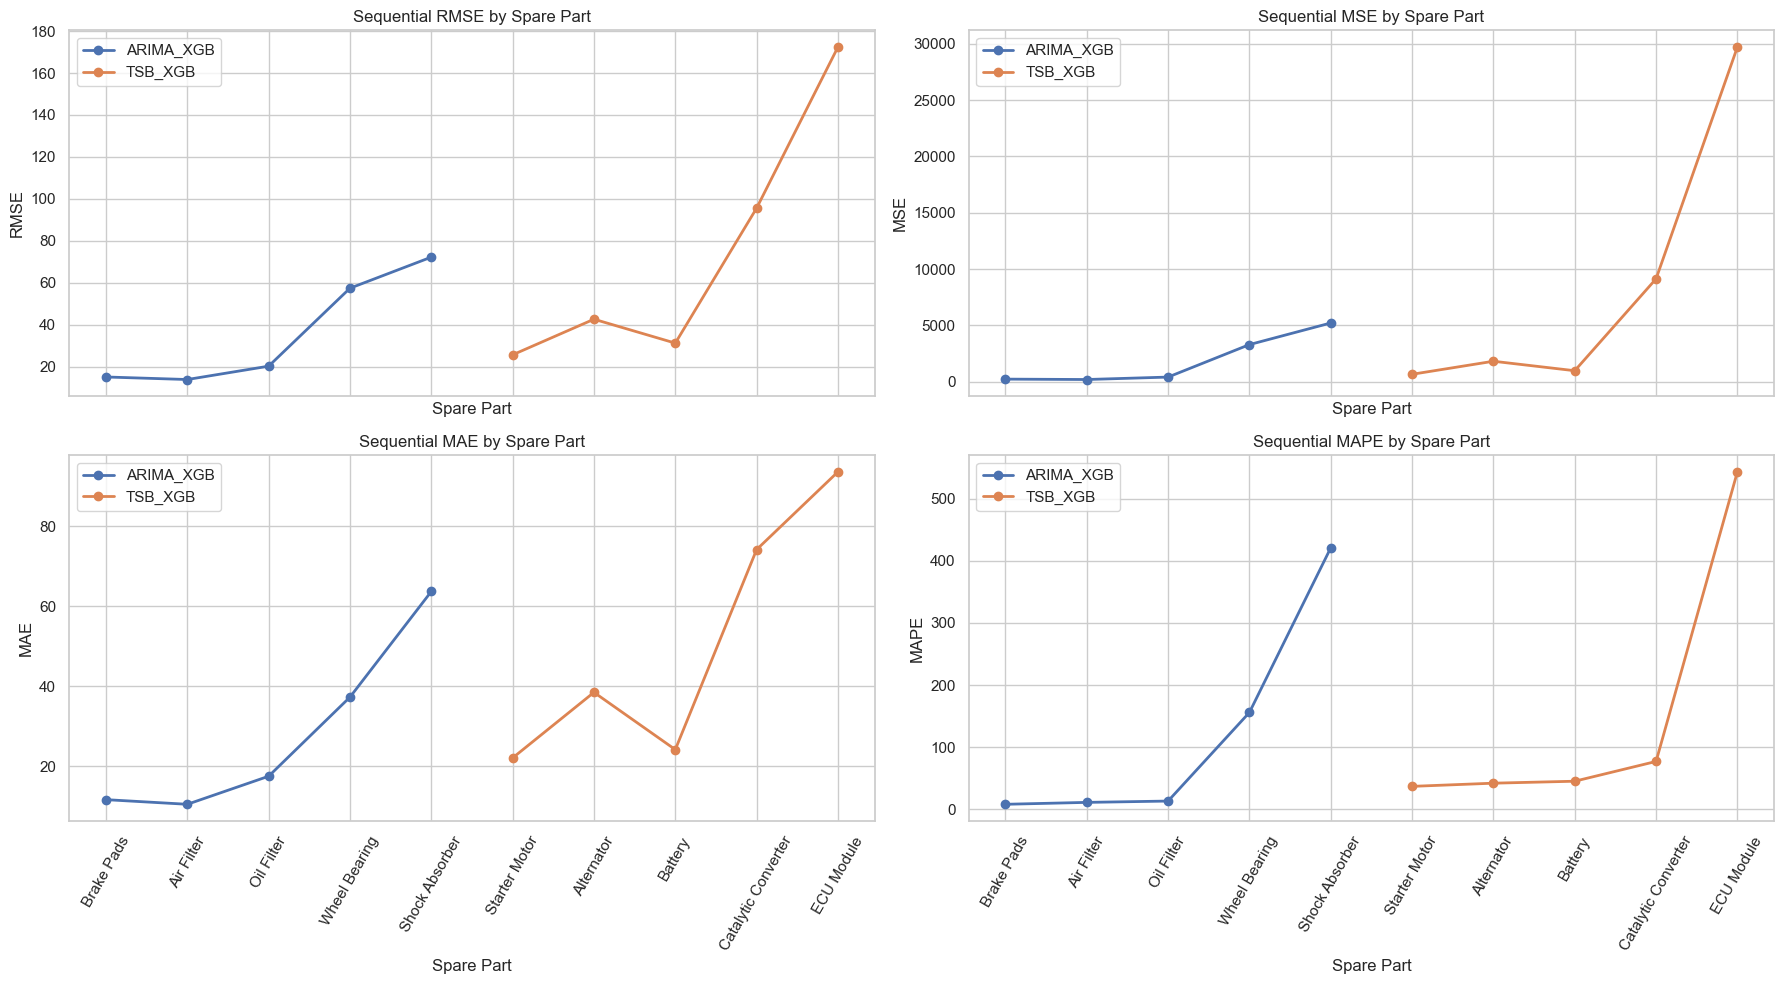

In [24]:
if "ADDITIONAL_METRIC_COLUMNS" not in globals():
    ADDITIONAL_METRIC_COLUMNS = [column for column in ["sMAPE", "WAPE"] if column in training_summary_df.columns]

base_spare_part_columns = [
    "product_name",
    "algorithm",
    "demand_type",
    "metric_scope",
    "selected_training_window",
    "epochs",
    "mape_observations",
    "zero_actual_observations",
]
spare_part_metric_columns = [
    column
    for column in [*base_spare_part_columns, *METRIC_COLUMNS, *ADDITIONAL_METRIC_COLUMNS]
    if column in training_summary_df.columns
]

spare_part_metric_summary = (
    training_summary_df[training_summary_df["series_kind"] != "business_revenue"]
    [spare_part_metric_columns]
    .sort_values([column for column in ["algorithm", "MAPE", "RMSE", "product_name"] if column in spare_part_metric_columns])
    .reset_index(drop=True)
)

display(Markdown("### Sequential Holdout Metrics by Trained Spare-Part Artifact"))
display(spare_part_metric_summary)

plot_metric_columns = [column for column in METRIC_COLUMNS if column in spare_part_metric_summary.columns]
if not plot_metric_columns:
    raise ValueError("No metric columns are available for the spare-part performance plot.")

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
for axis, metric_name in zip(axes.flatten(), plot_metric_columns):
    for algorithm_name, group in spare_part_metric_summary.groupby("algorithm"):
        axis.plot(group["product_name"], group[metric_name], marker="o", linewidth=2, label=algorithm_name)
    axis.set_title(f"Sequential {metric_name} by Spare Part")
    axis.set_xlabel("Spare Part")
    axis.set_ylabel(metric_name)
    axis.tick_params(axis="x", rotation=60)
    axis.legend()

for axis in axes.flatten()[len(plot_metric_columns):]:
    axis.axis("off")

plt.tight_layout()
plt.show()


## Spare Part Training Plots

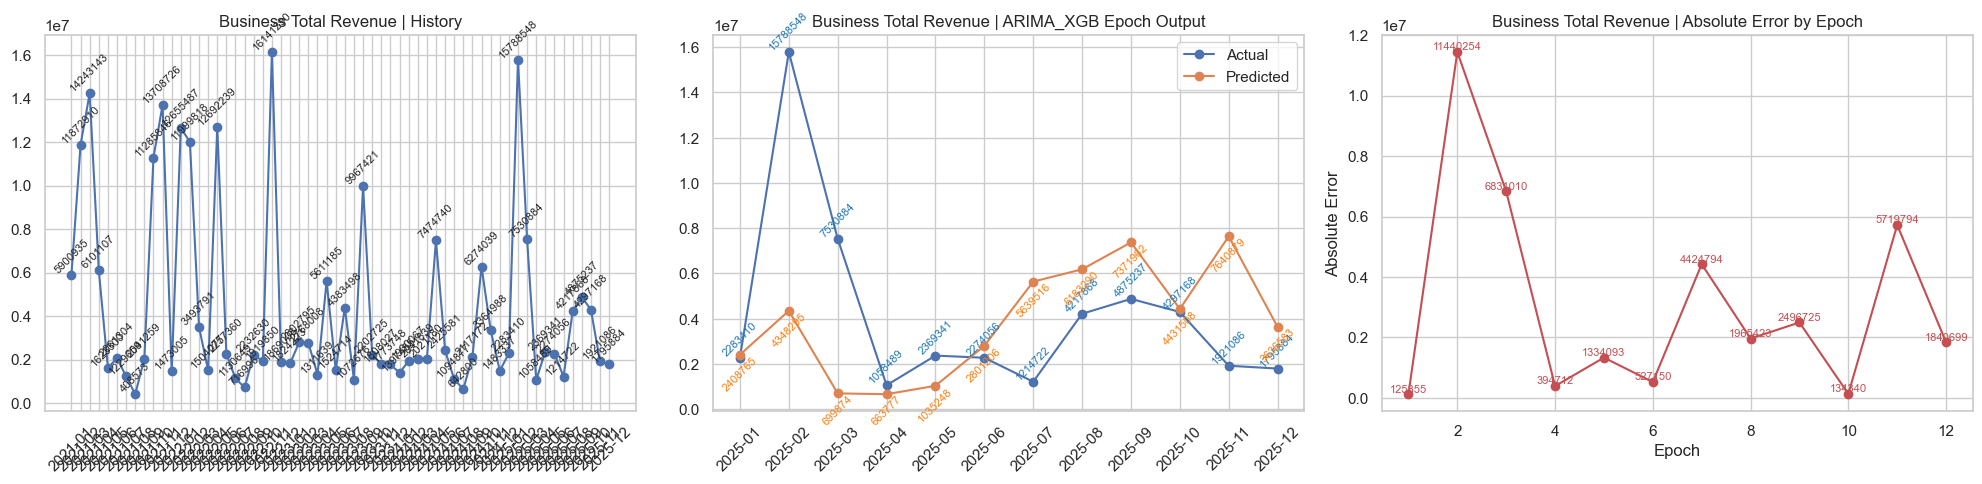

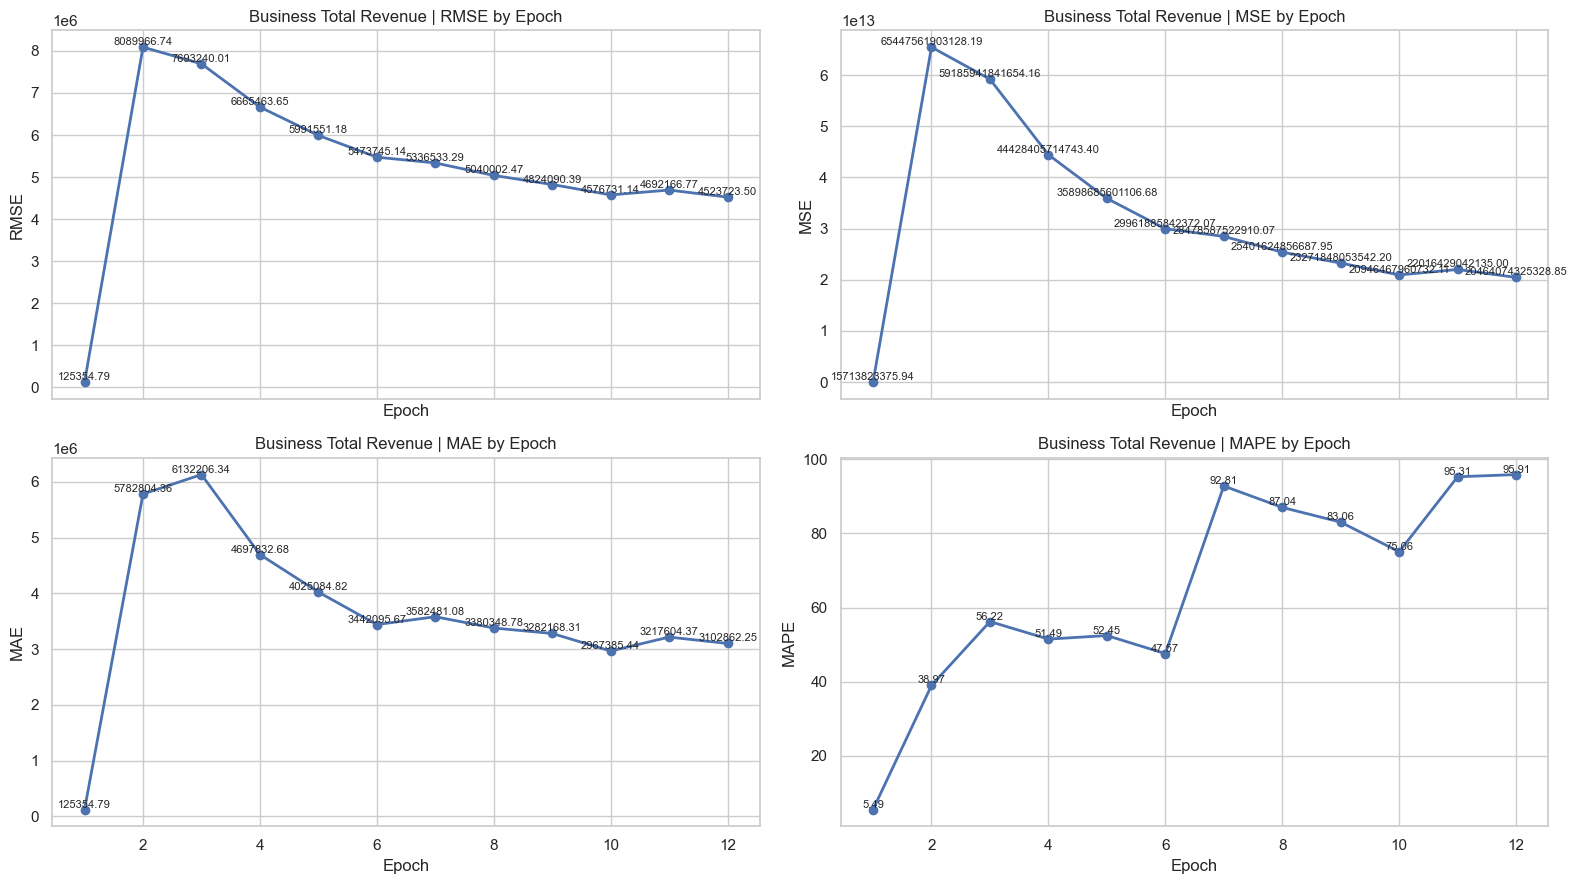

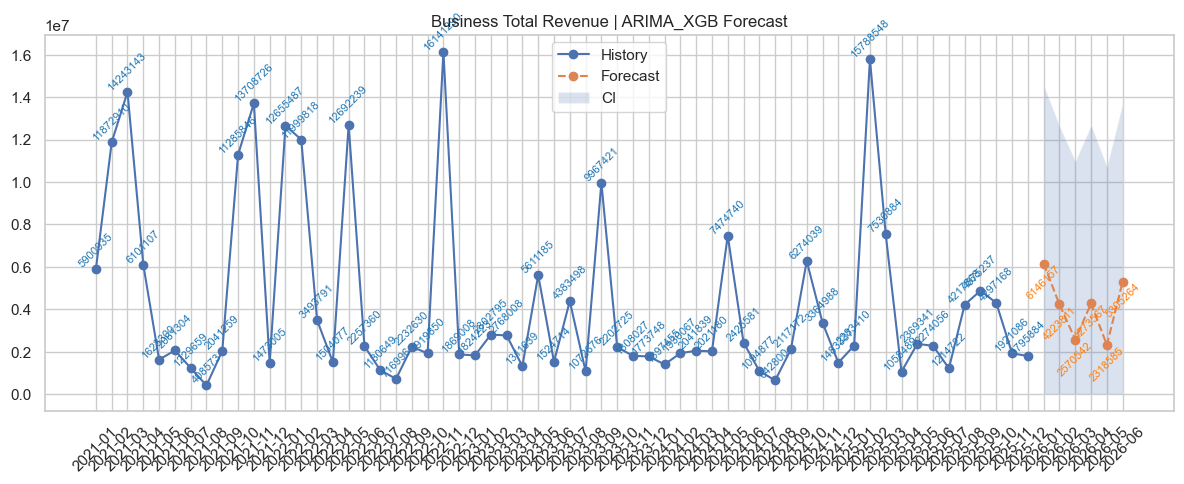

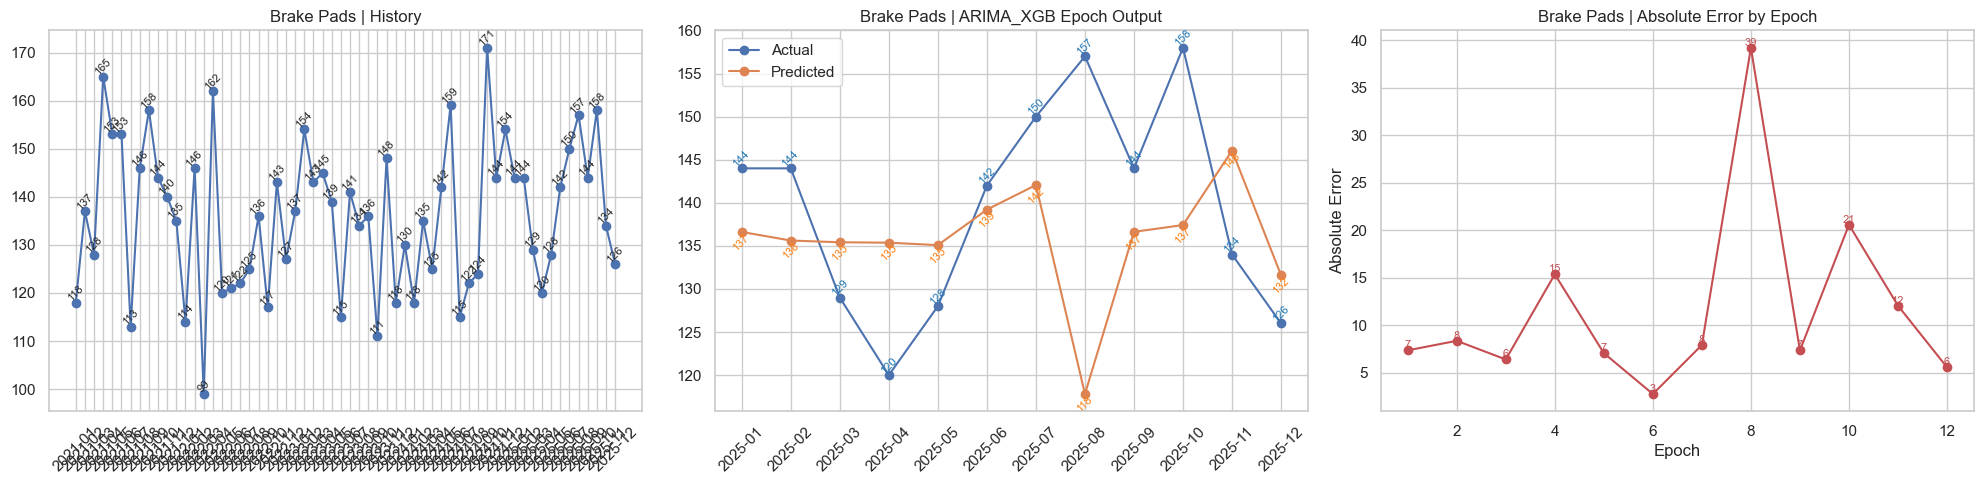

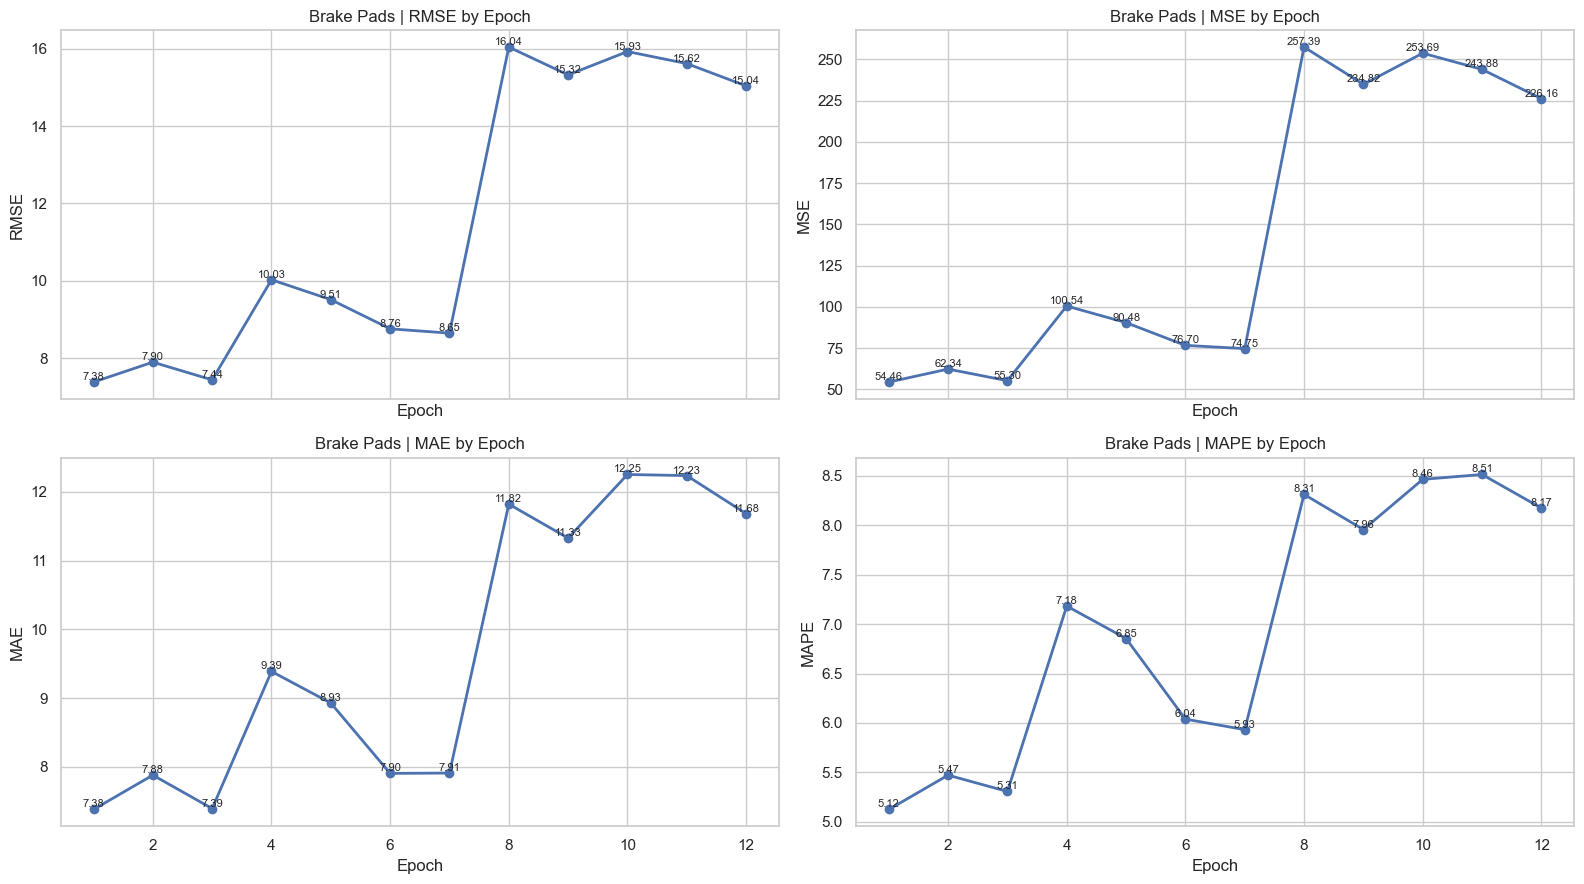

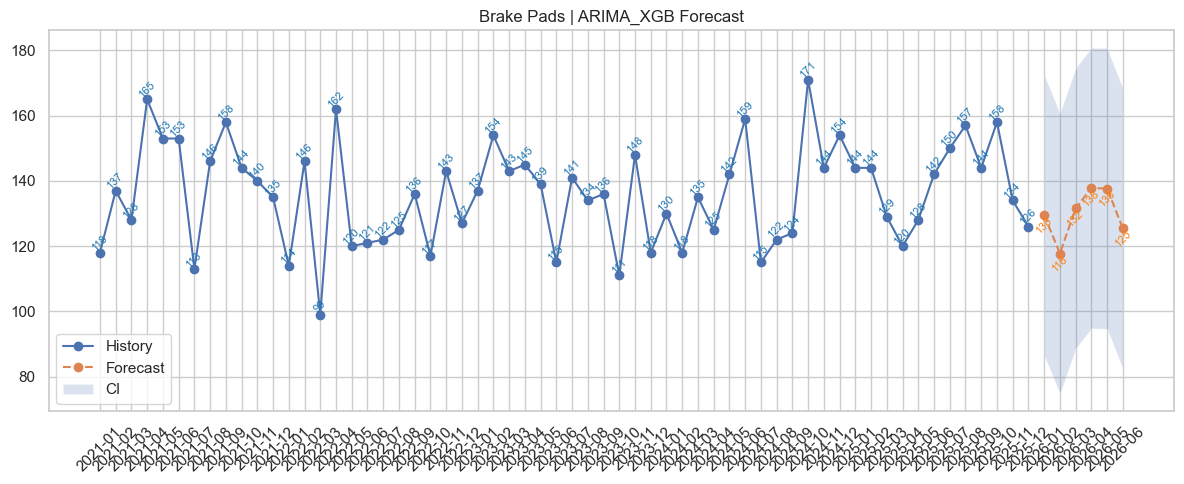

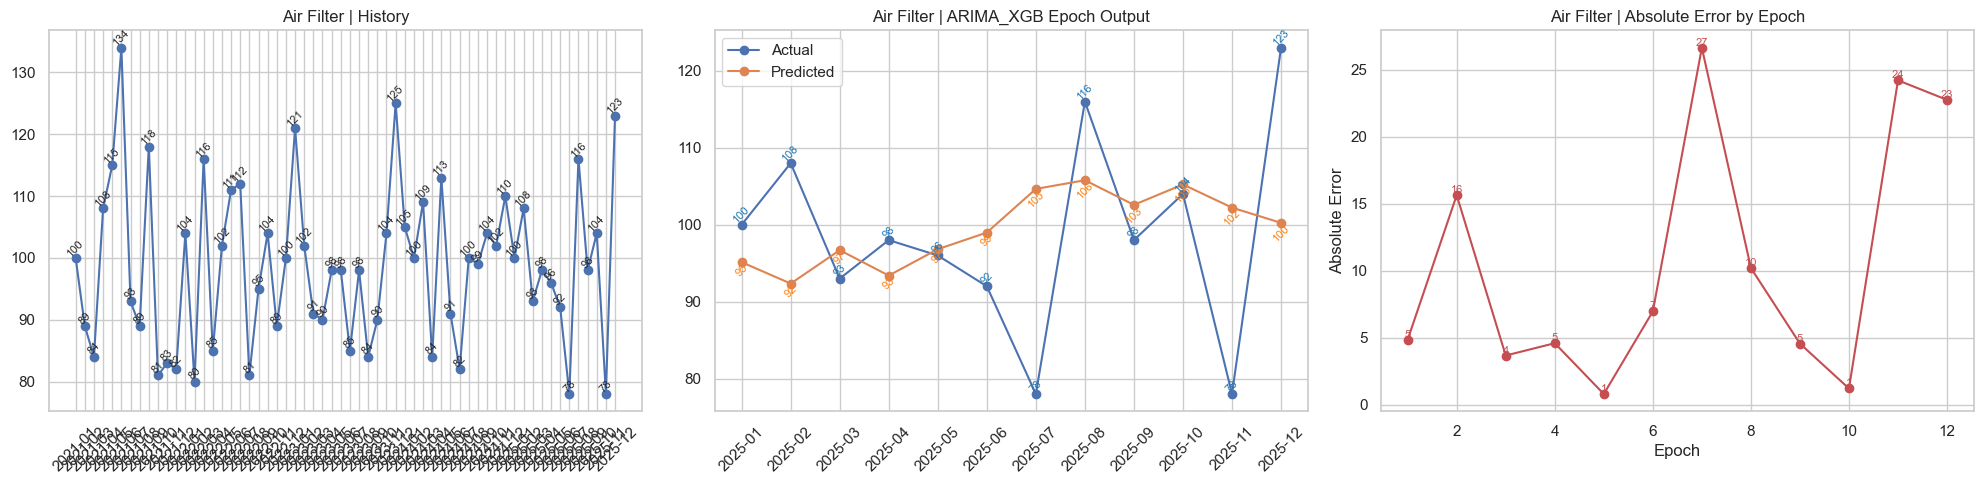

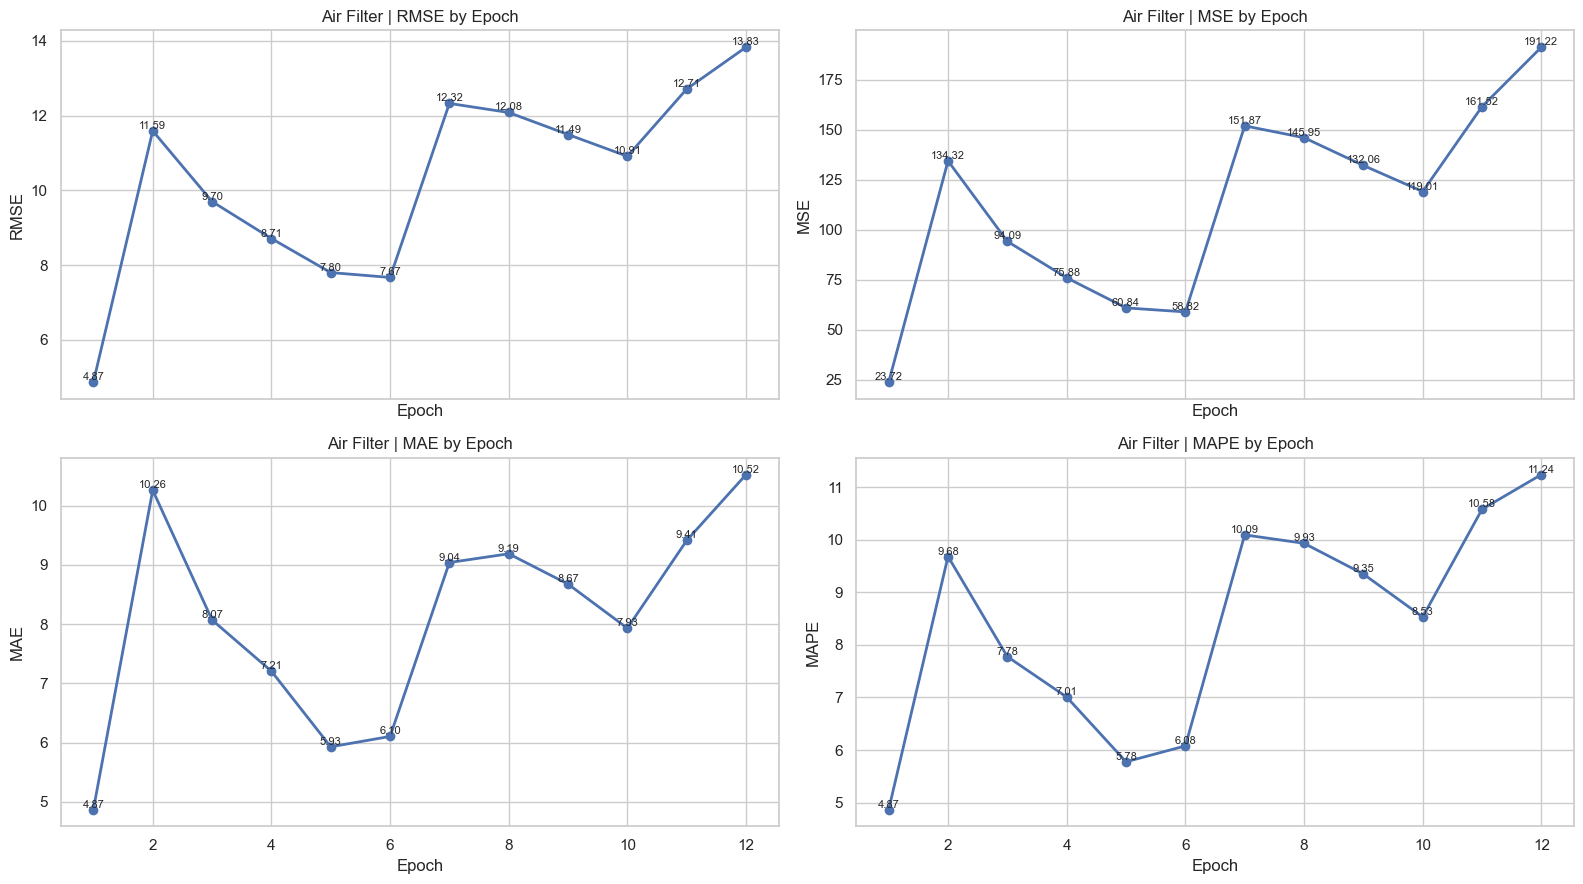

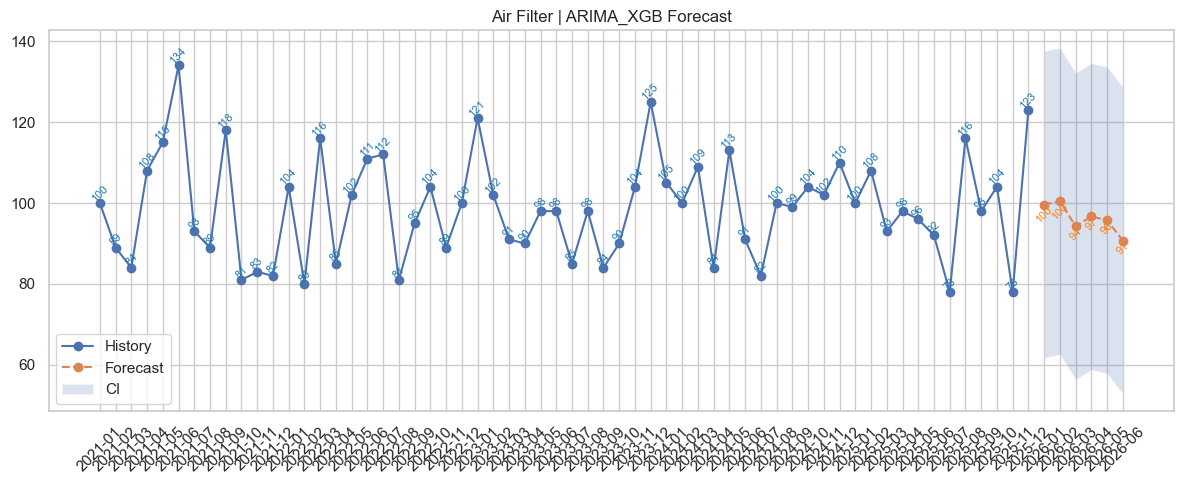

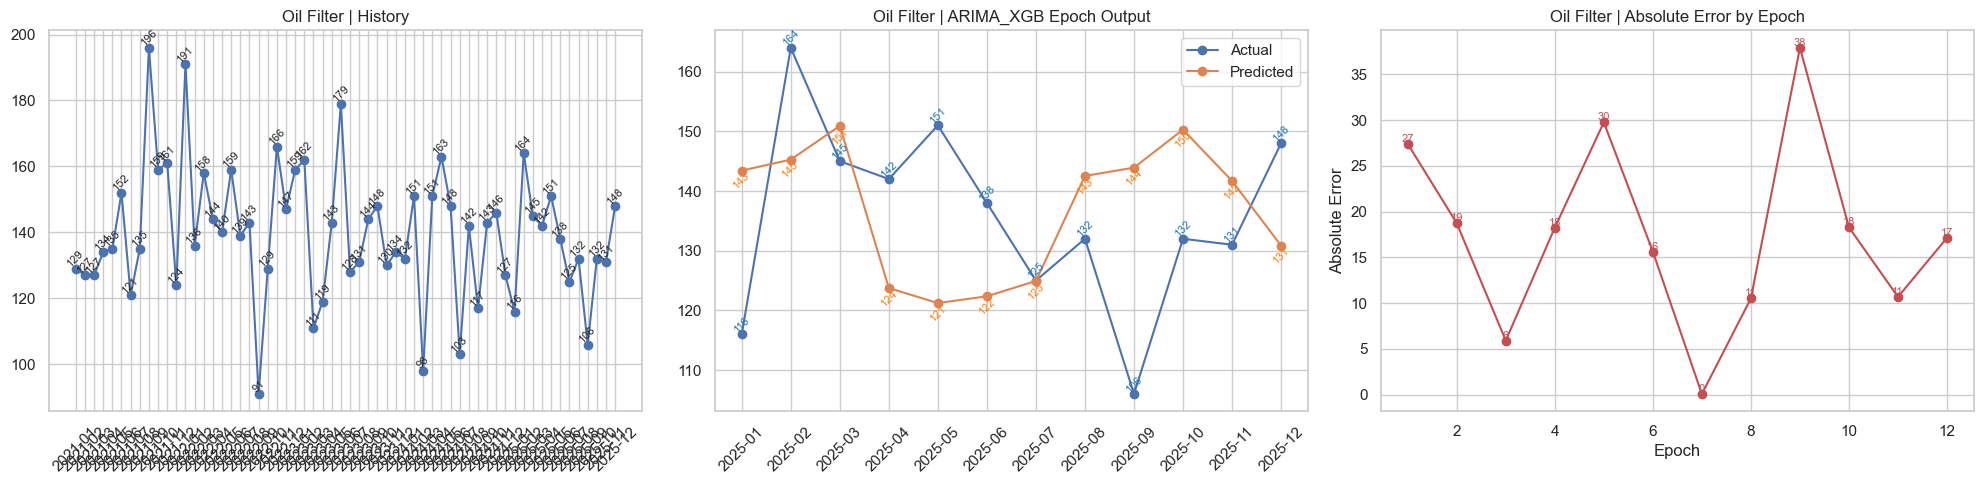

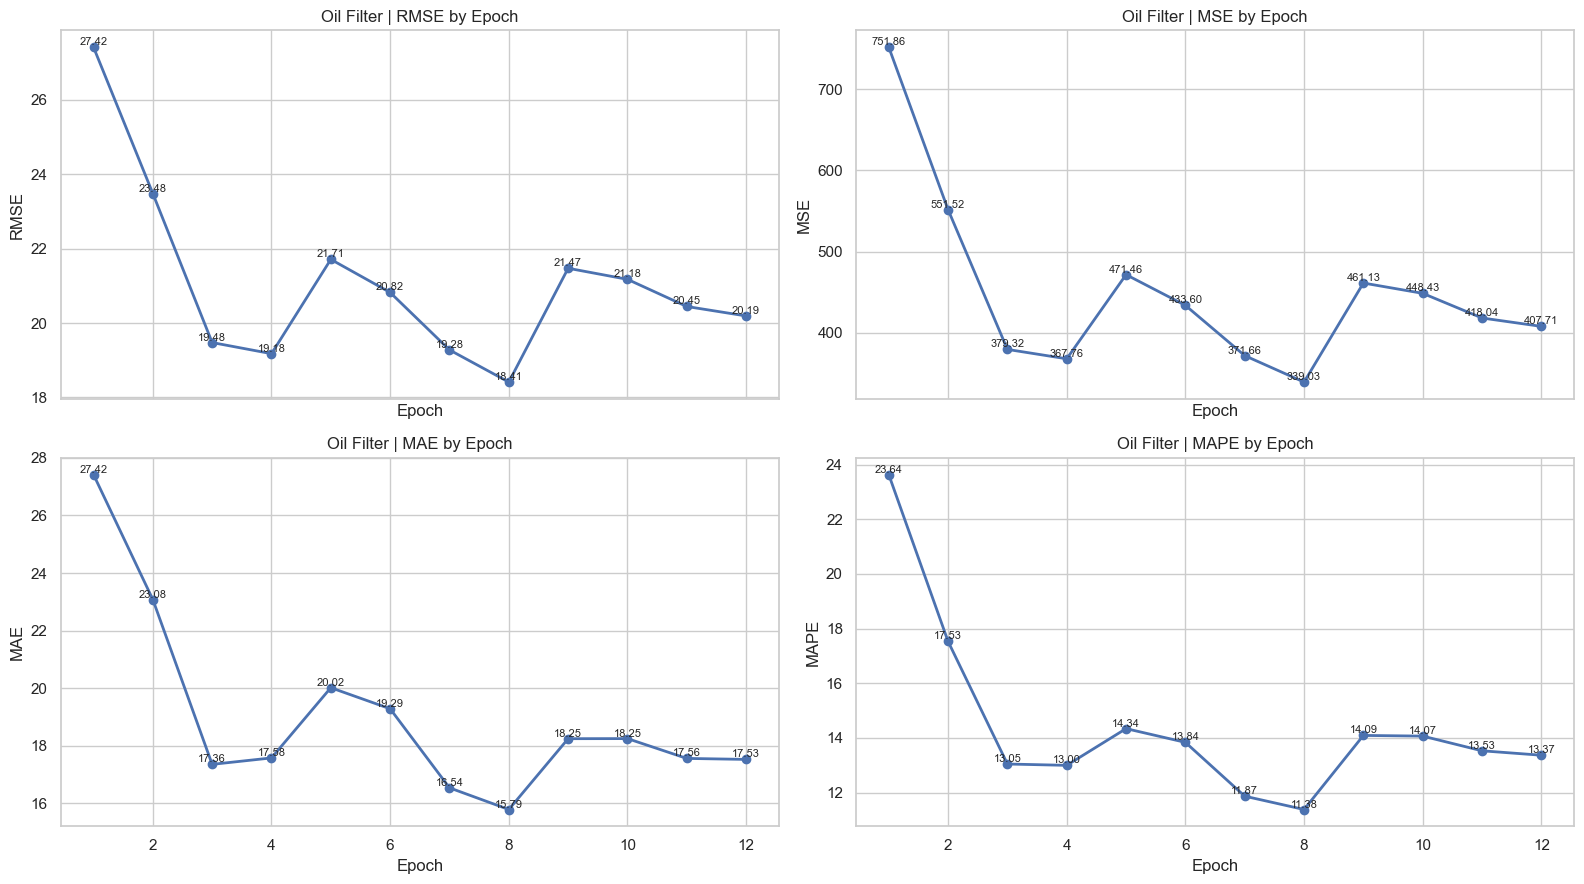

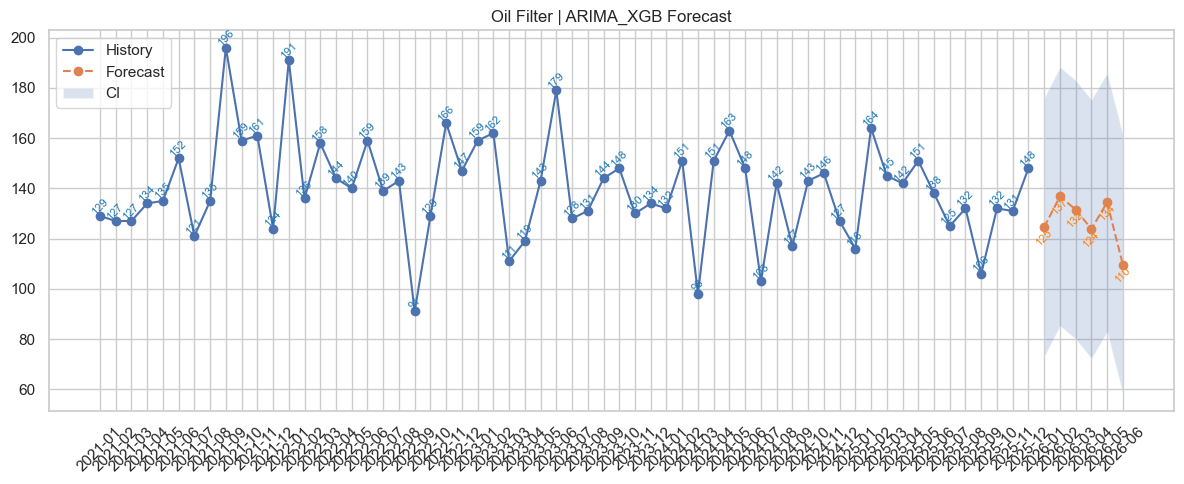

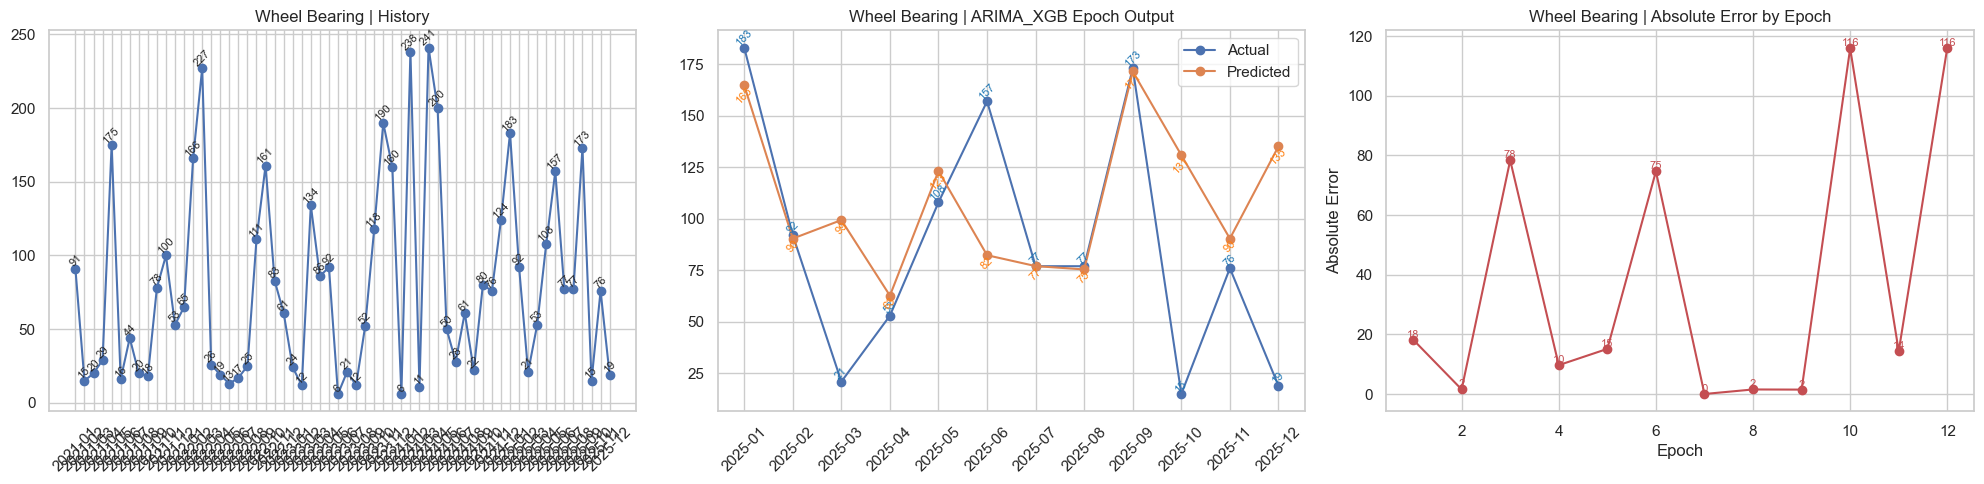

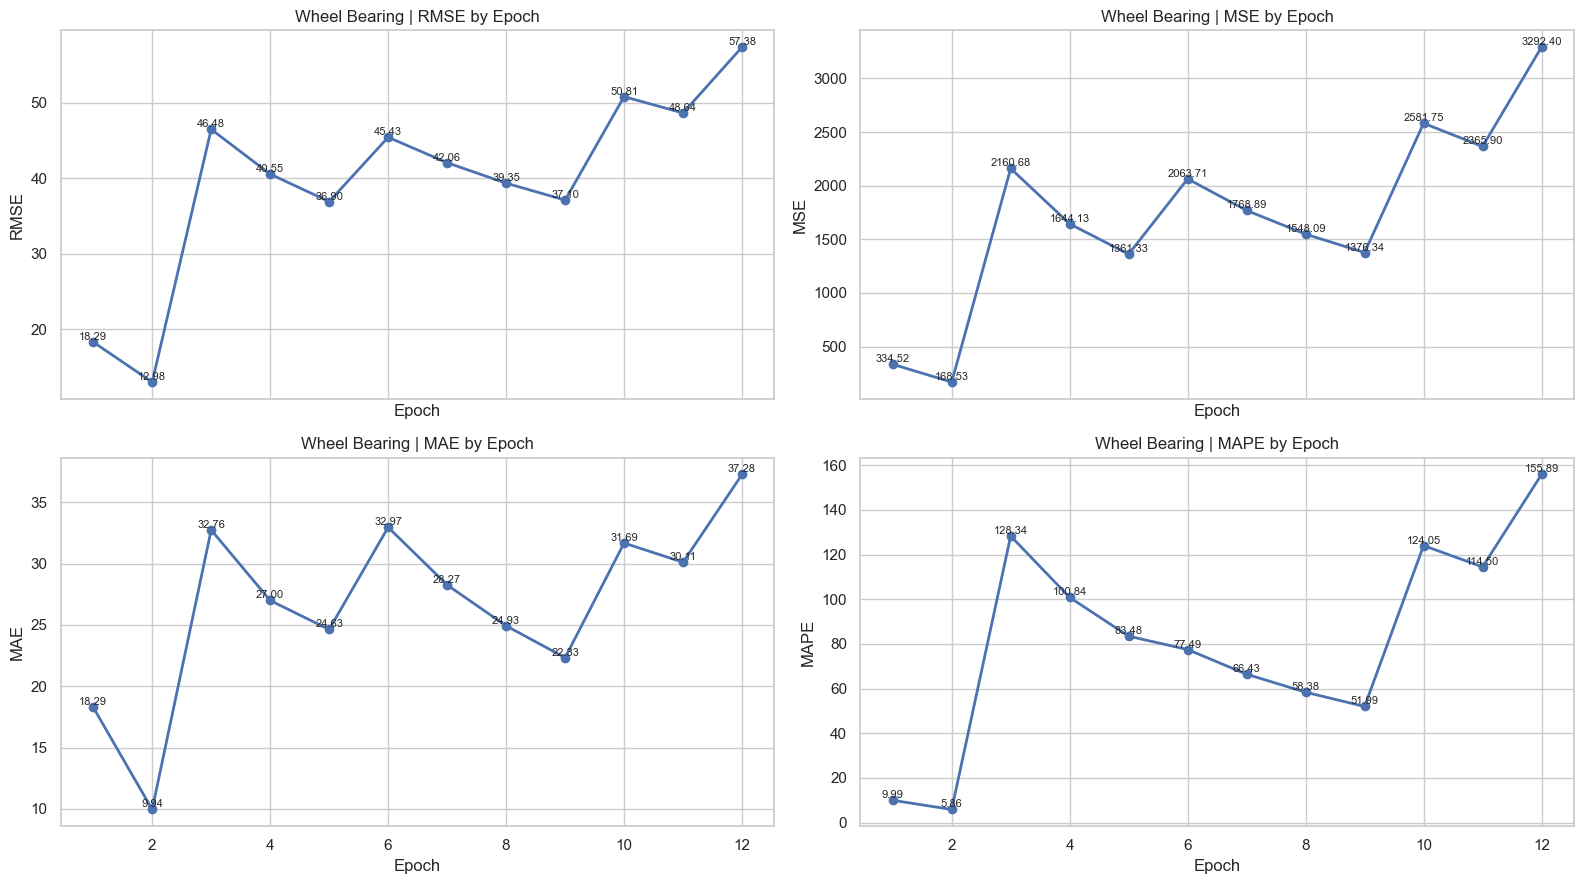

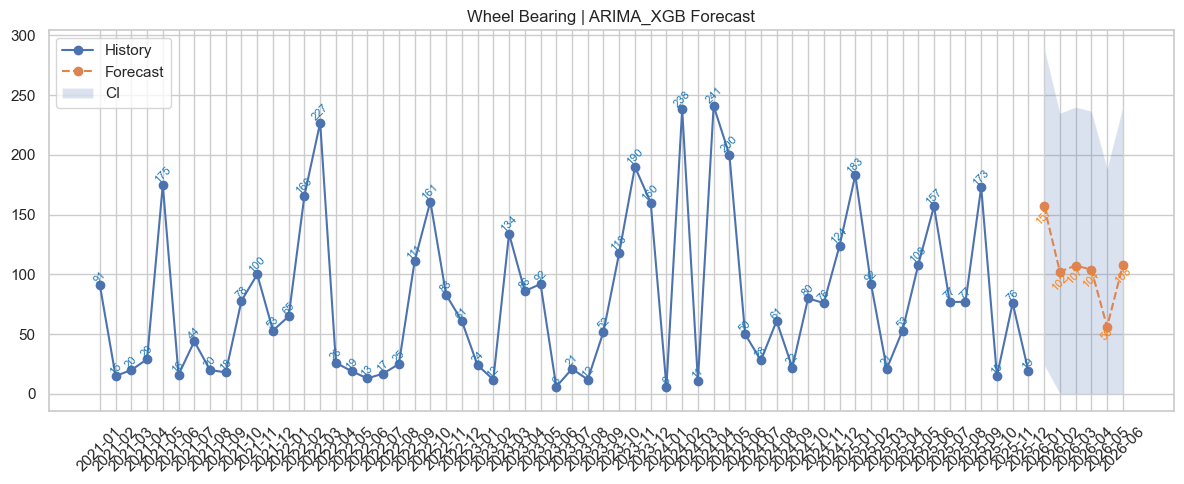

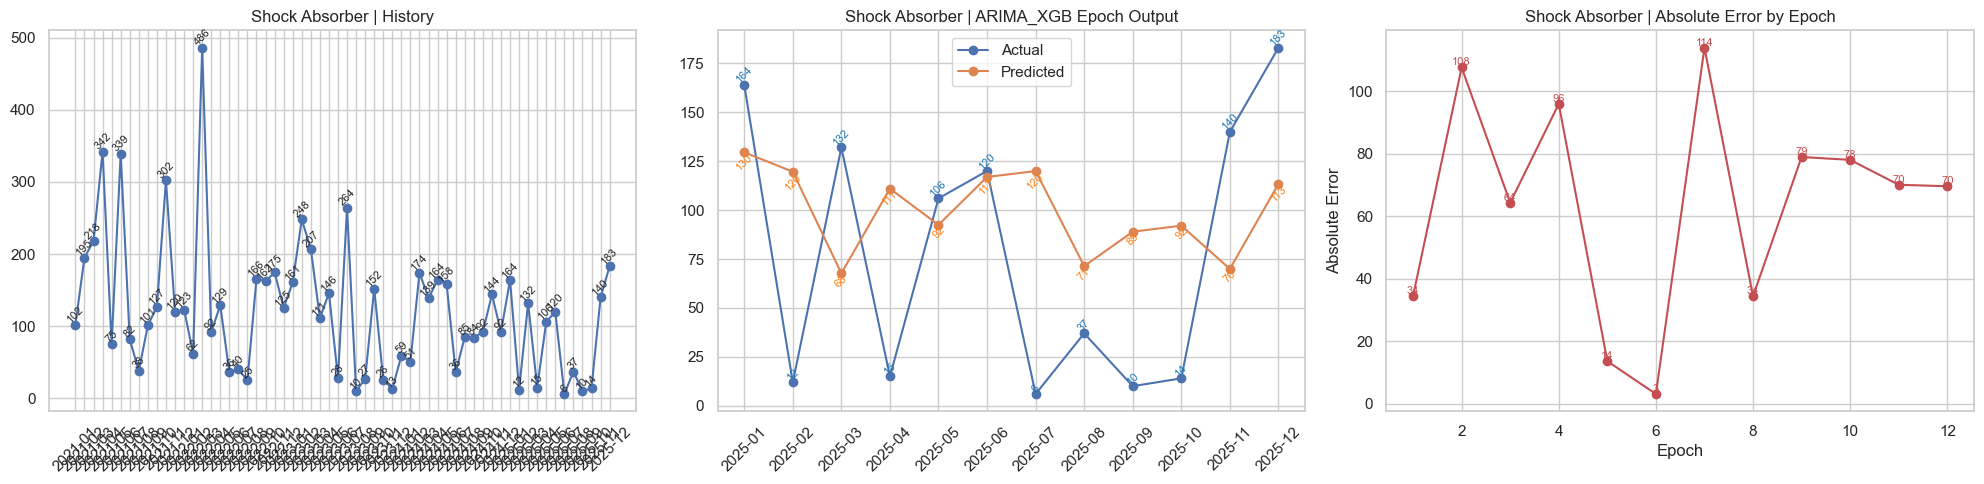

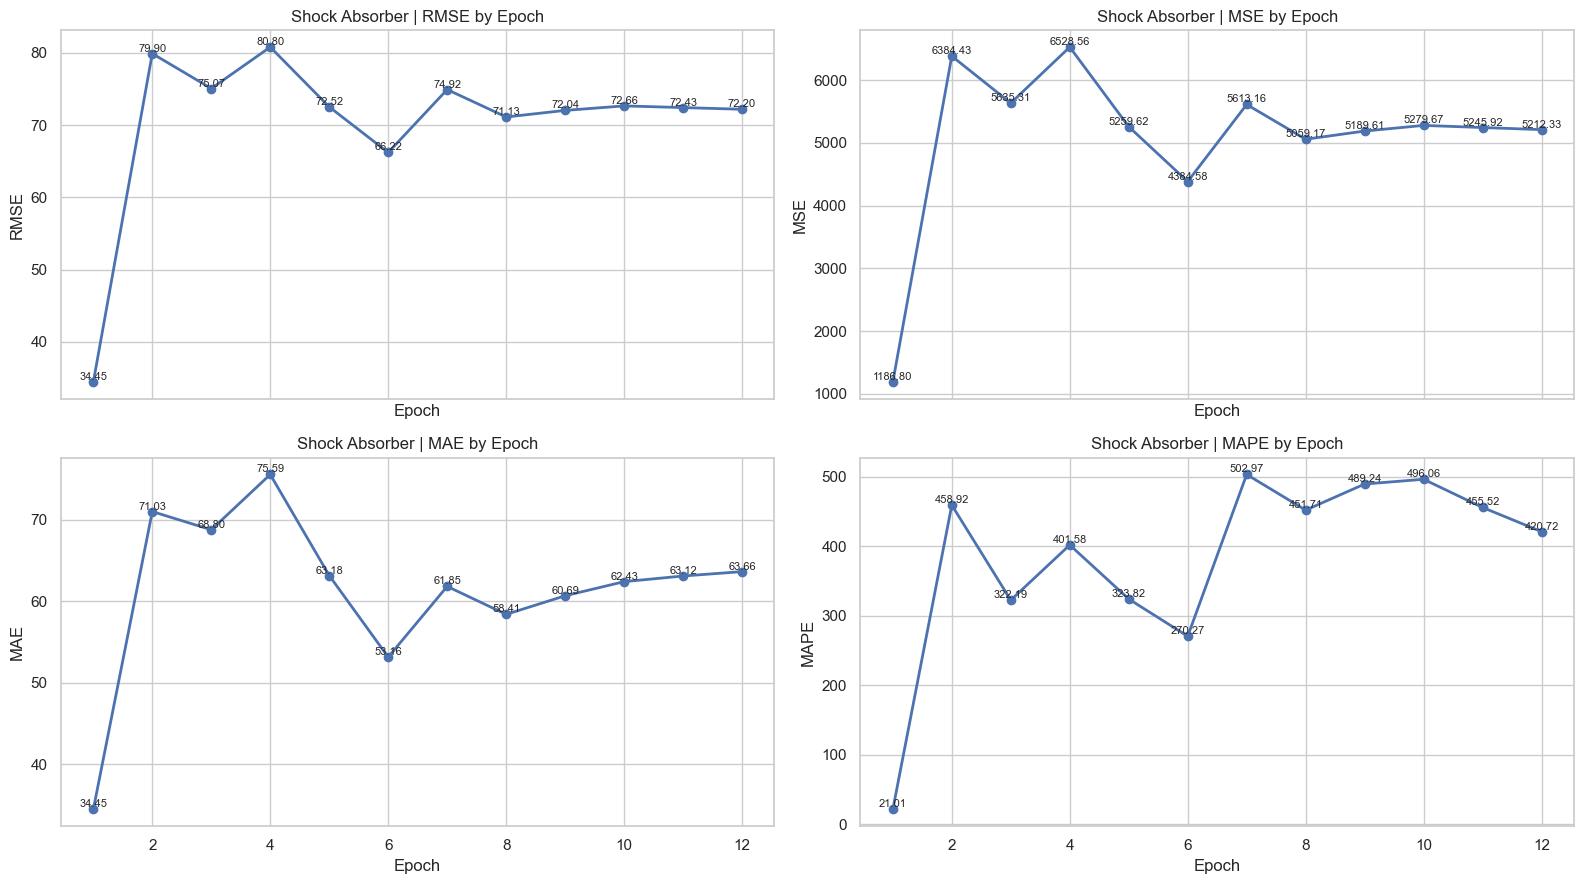

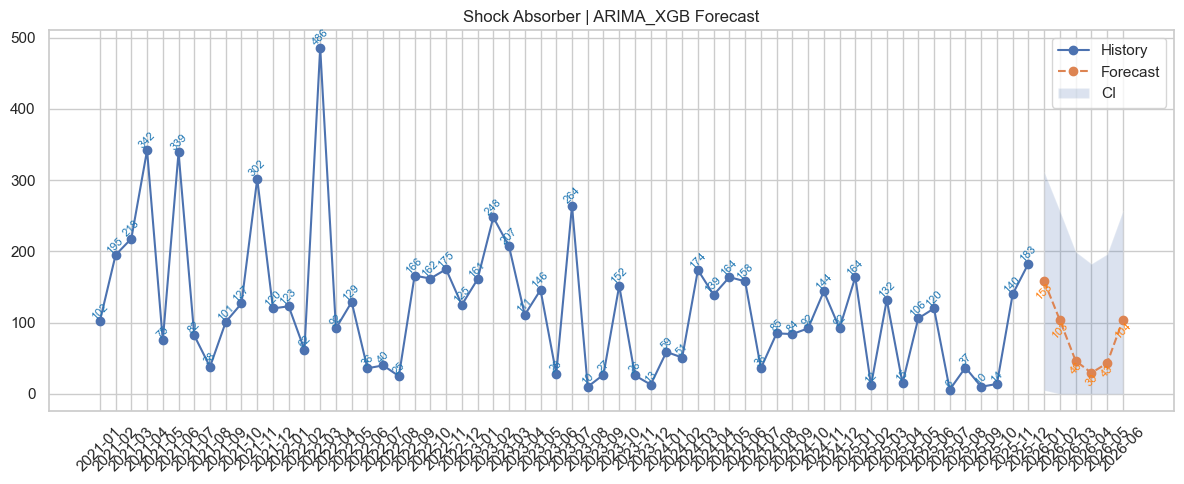

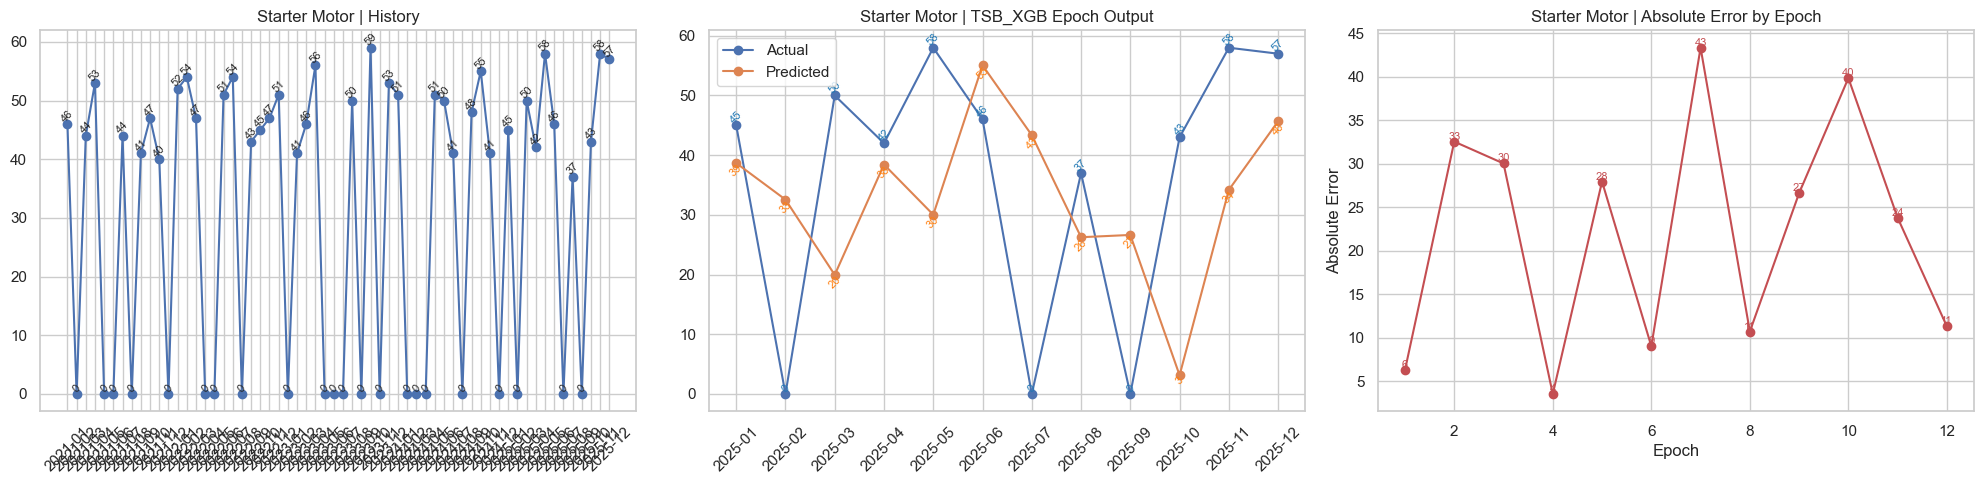

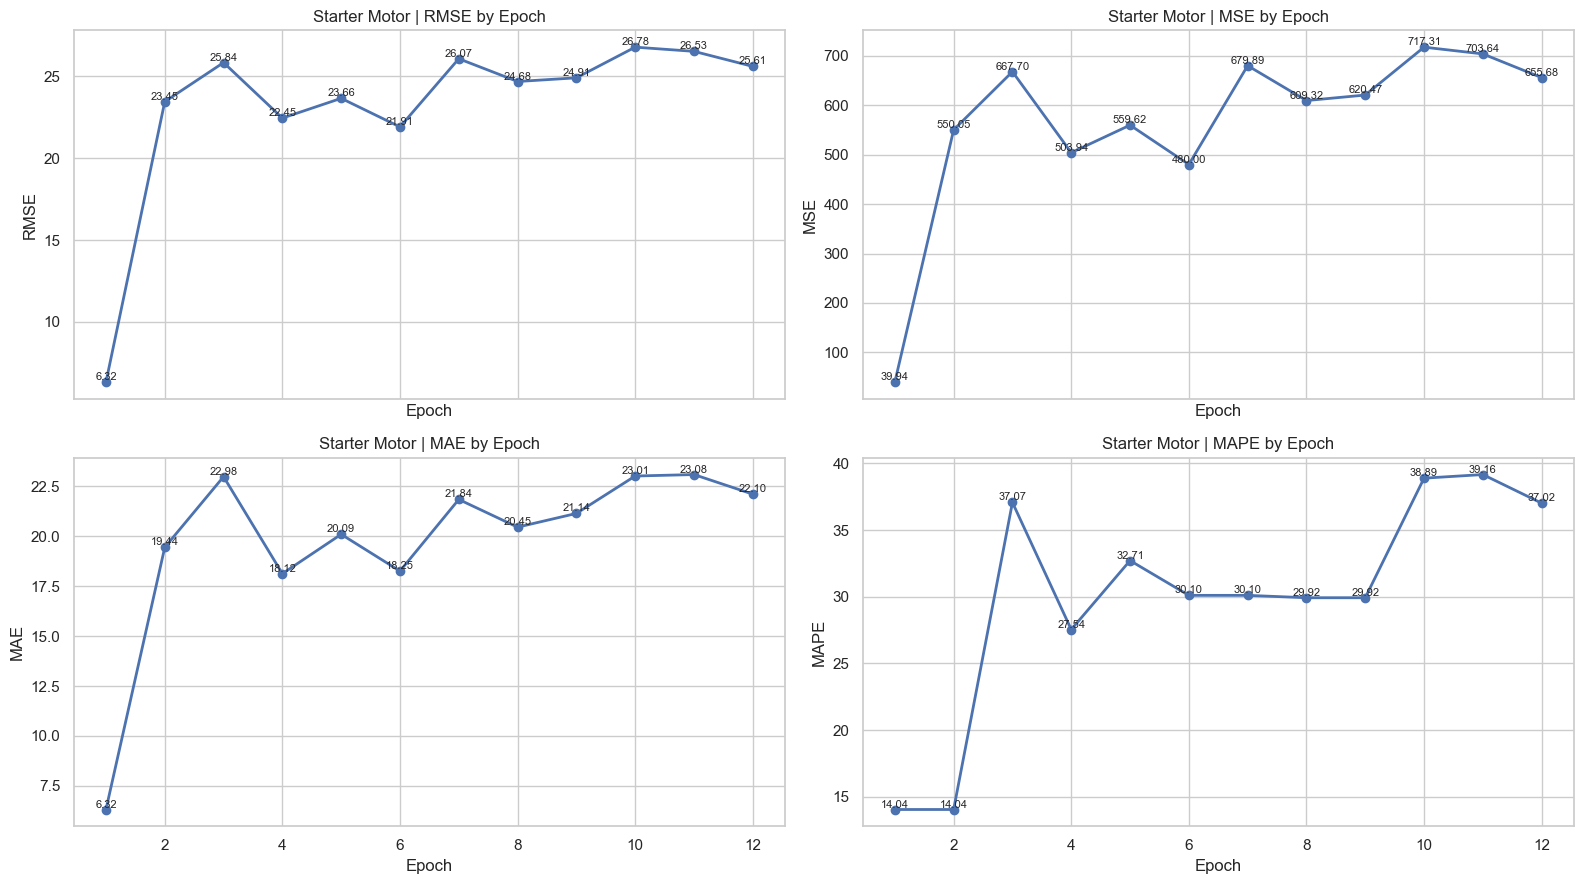

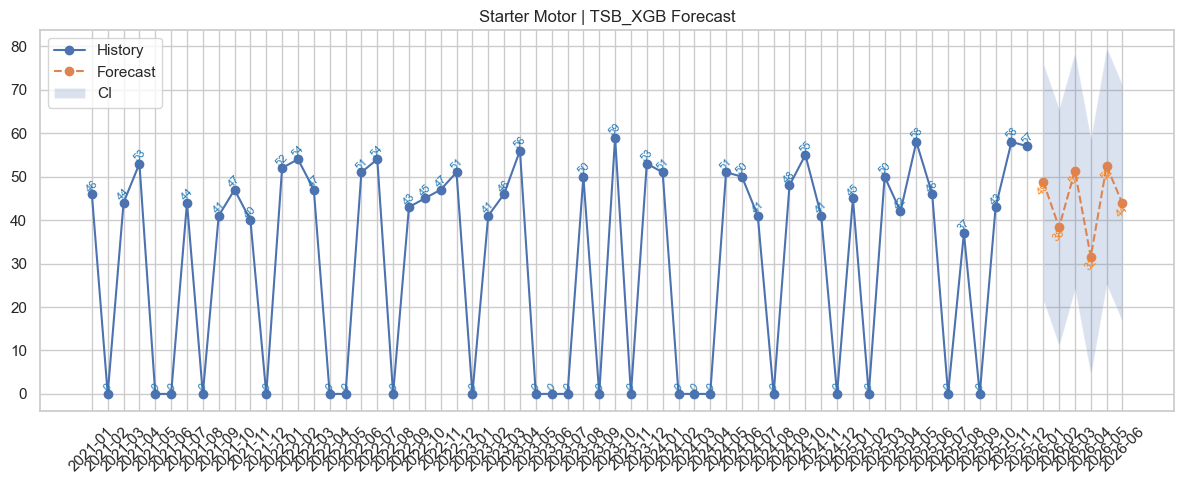

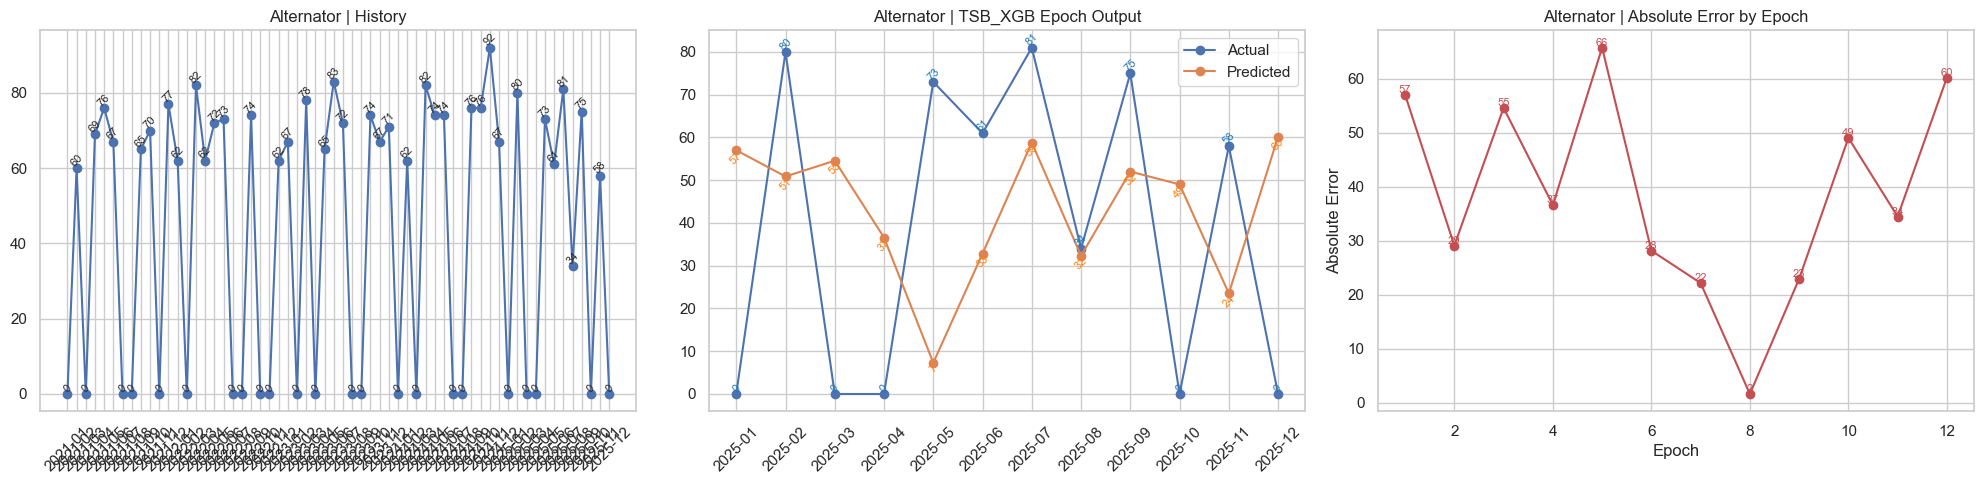

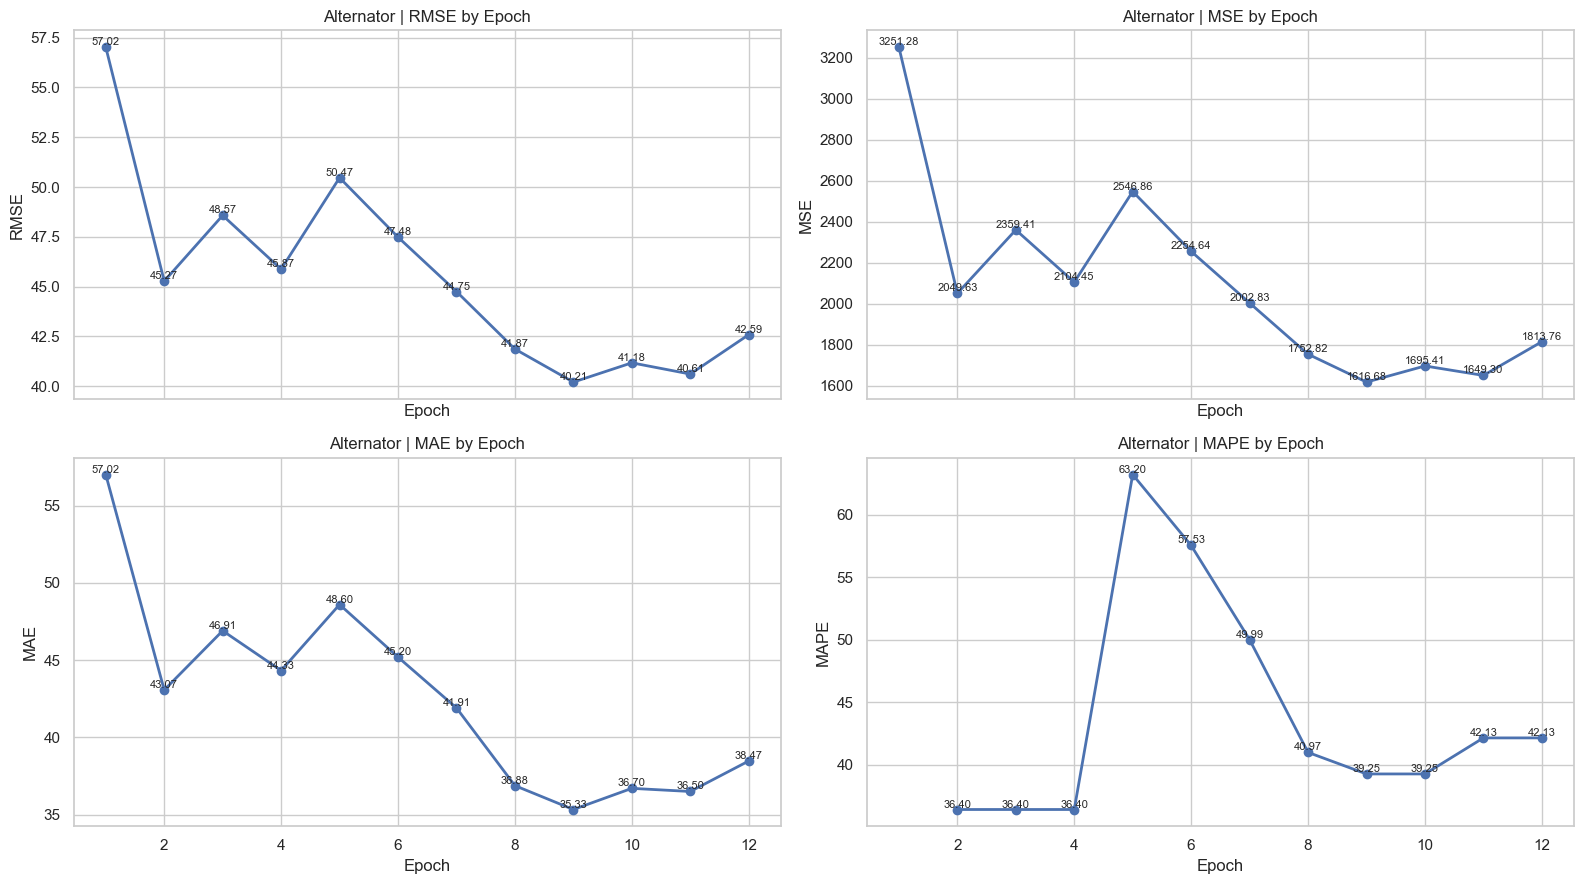

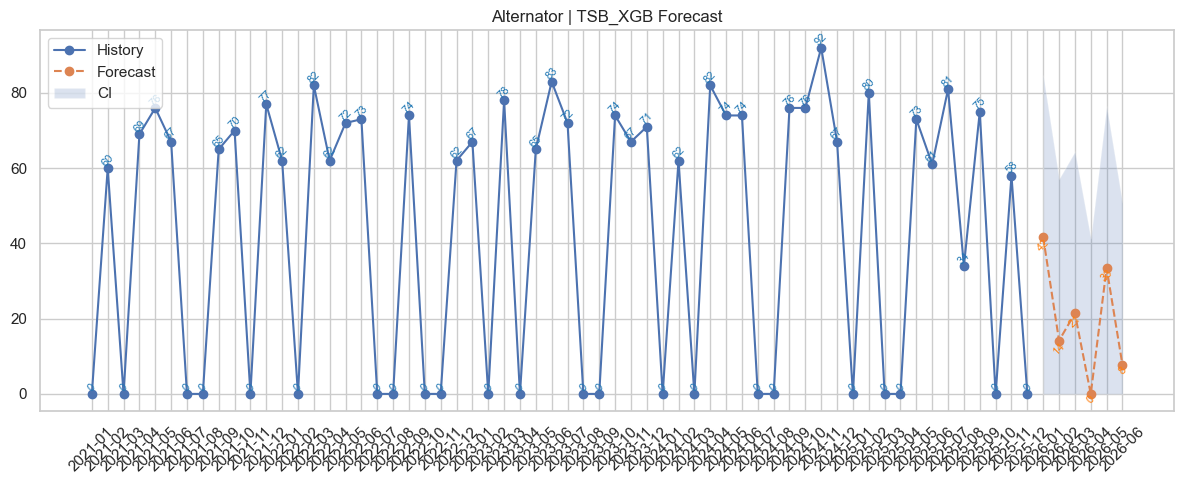

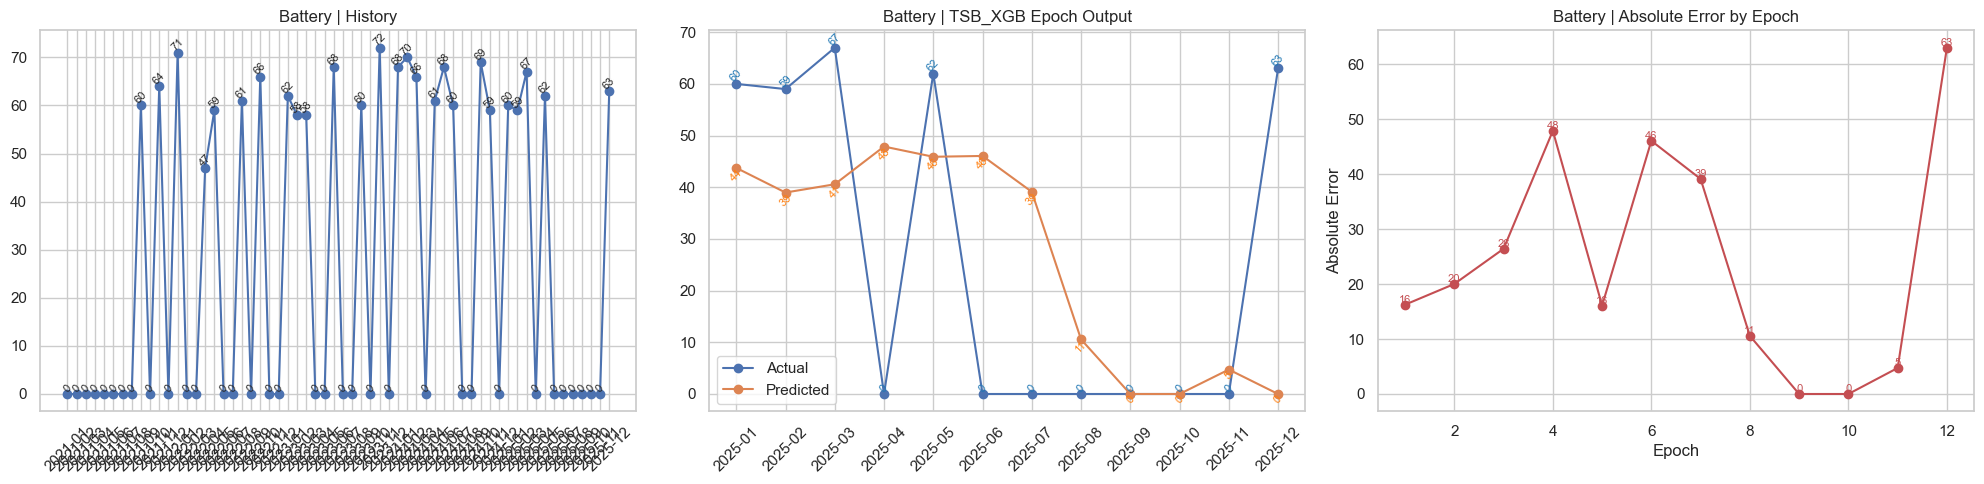

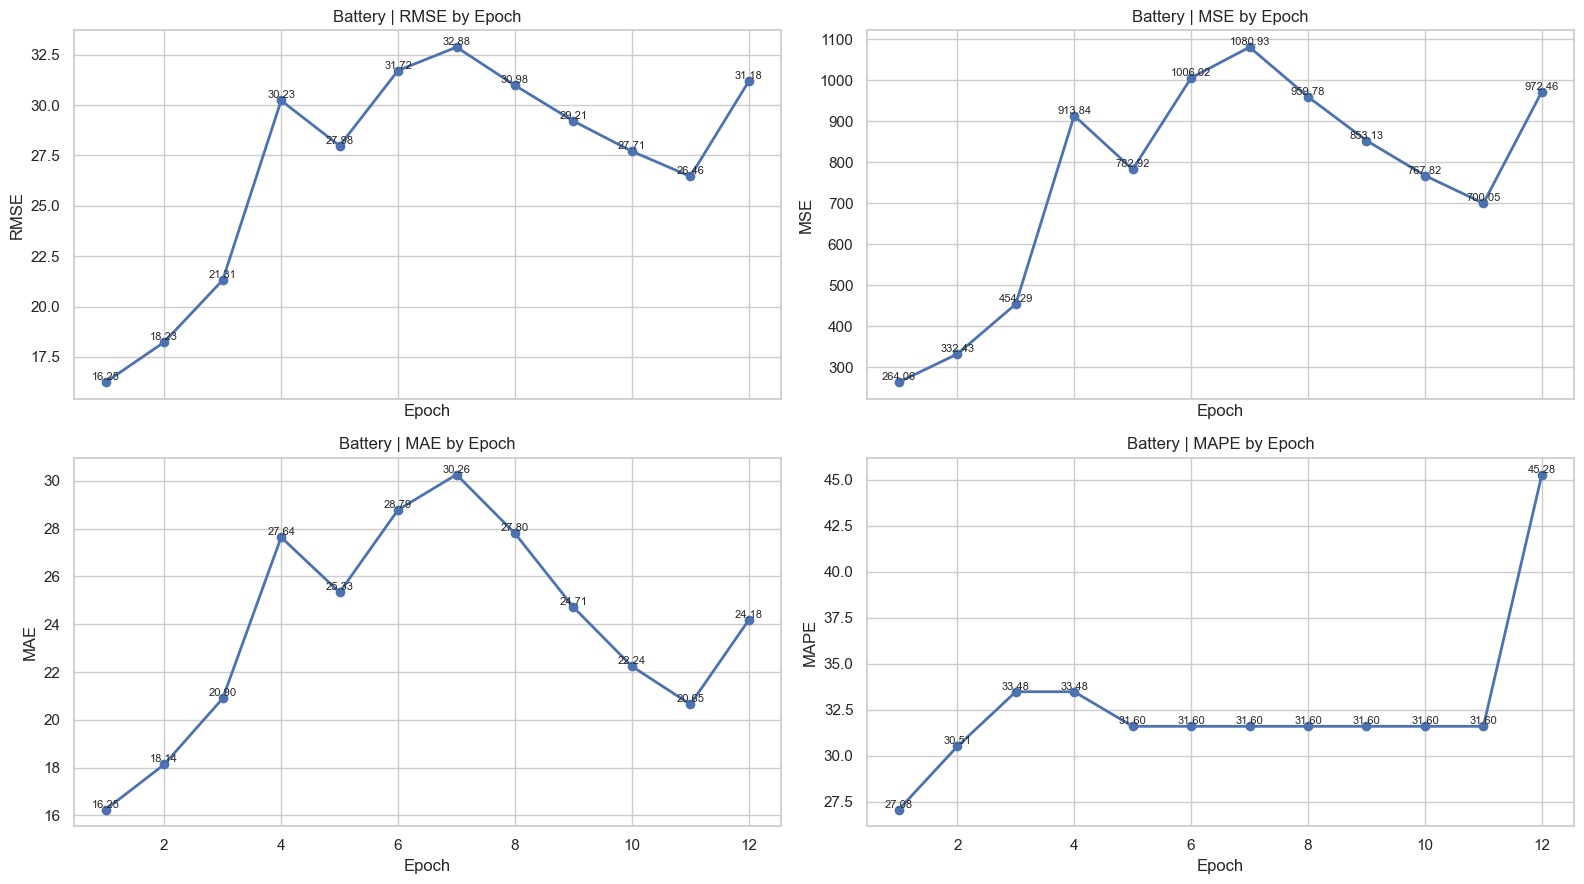

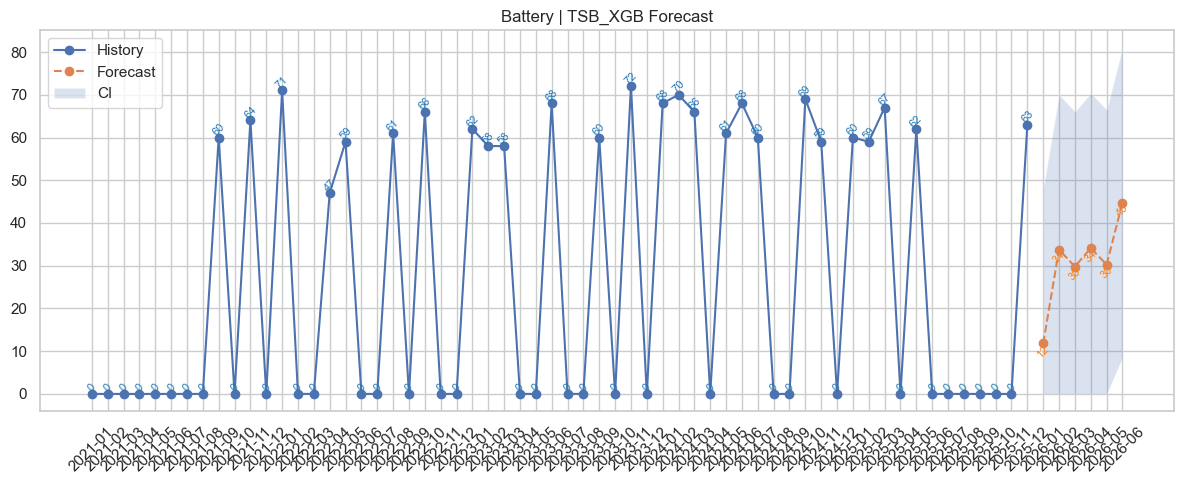

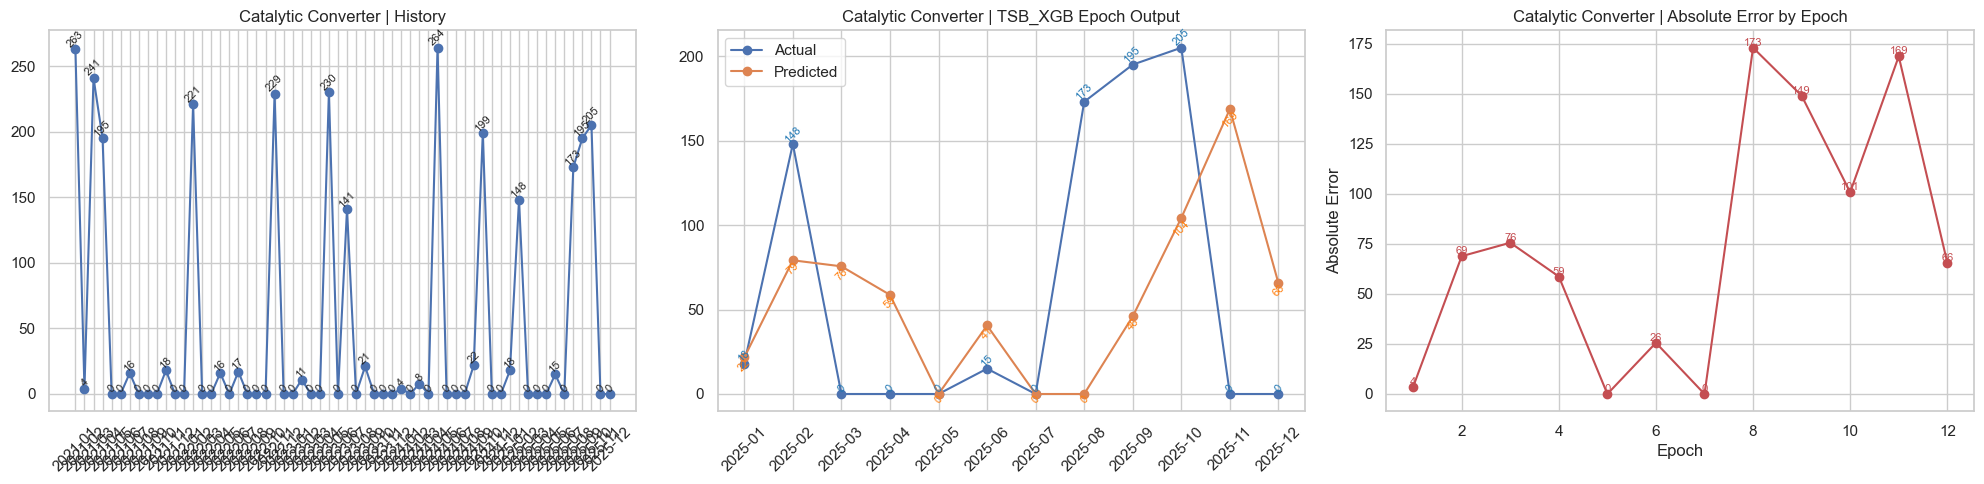

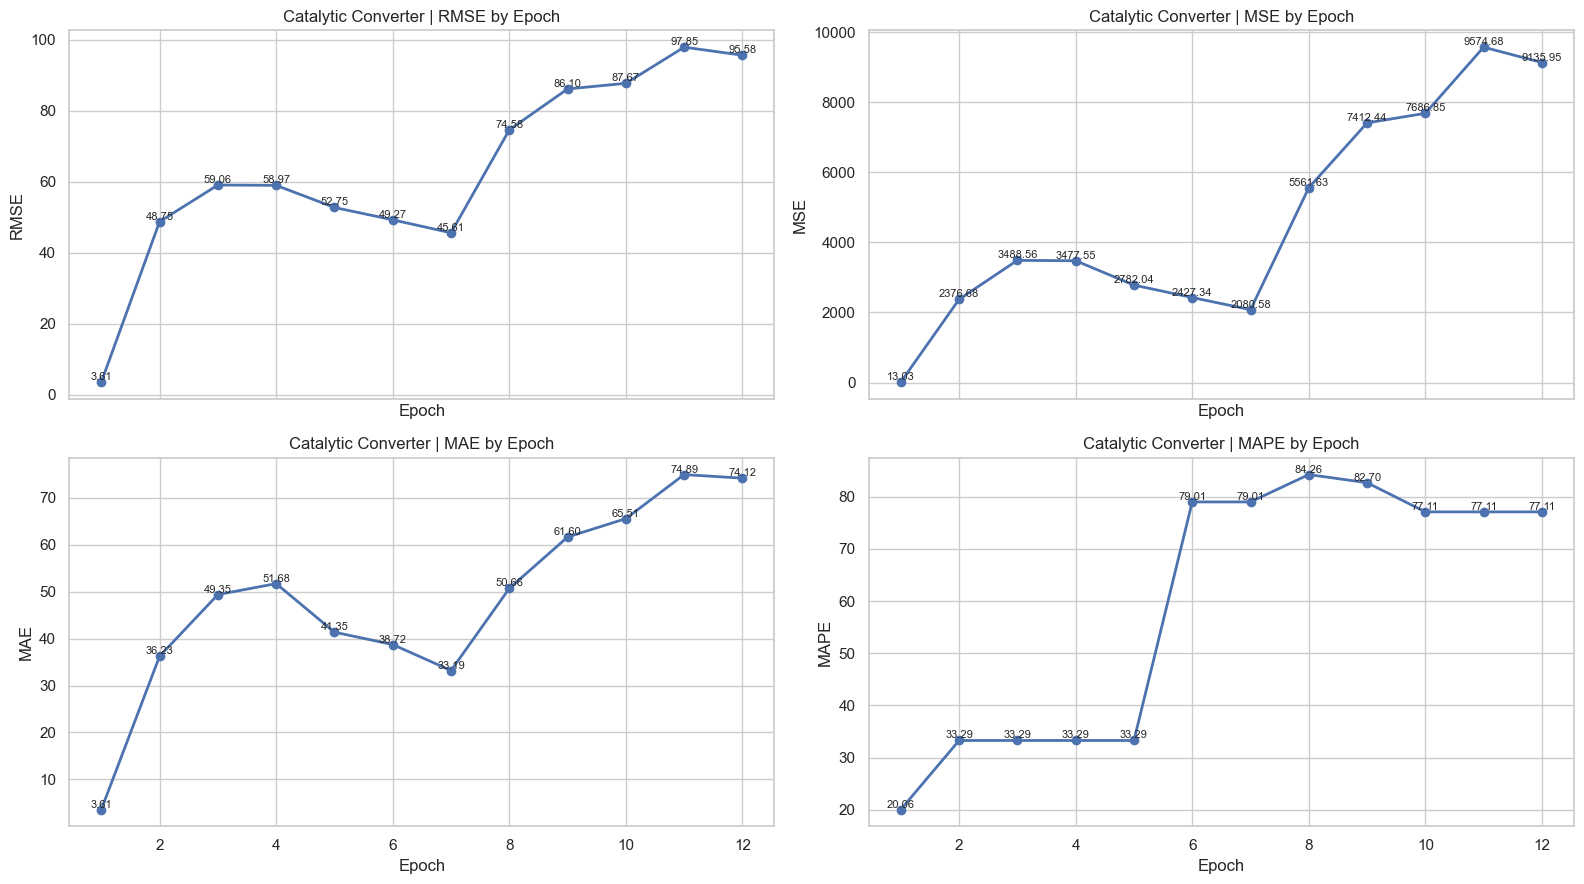

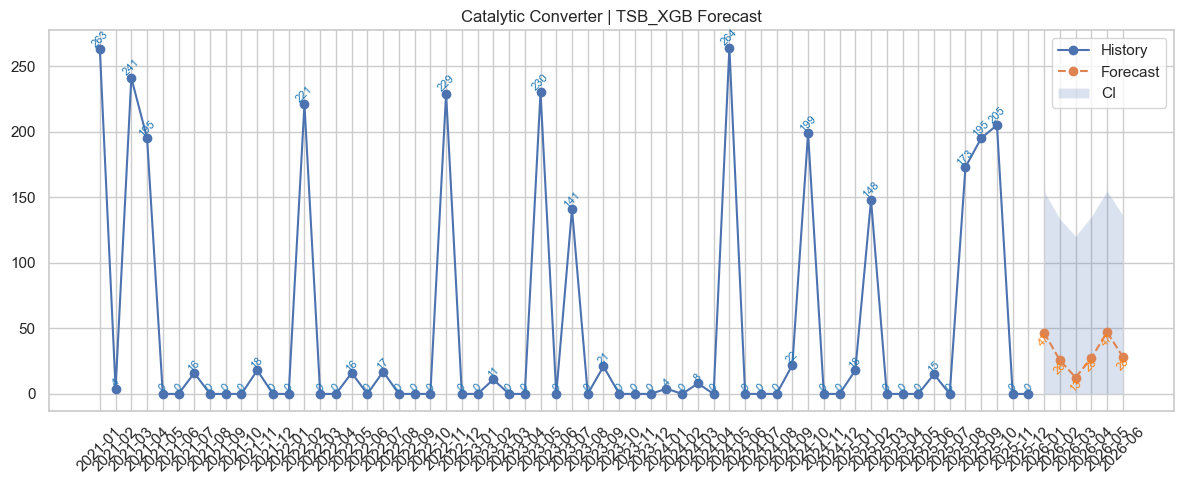

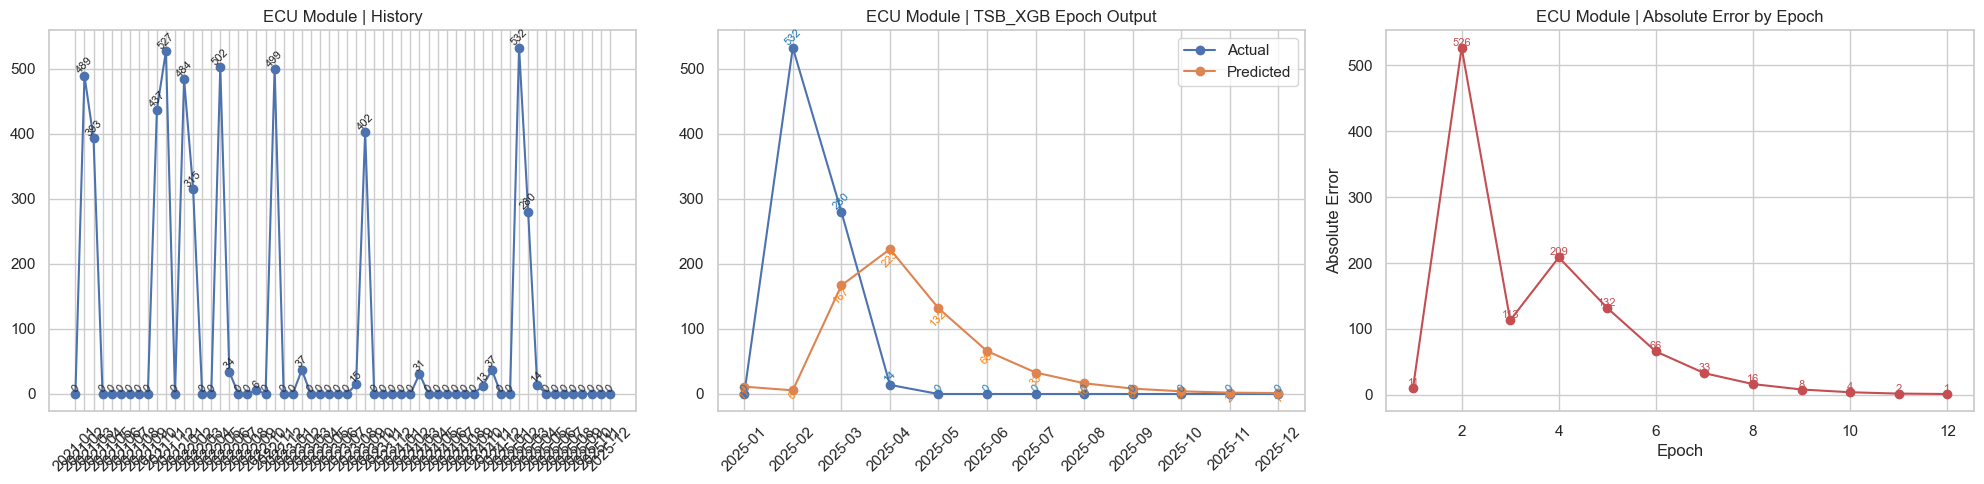

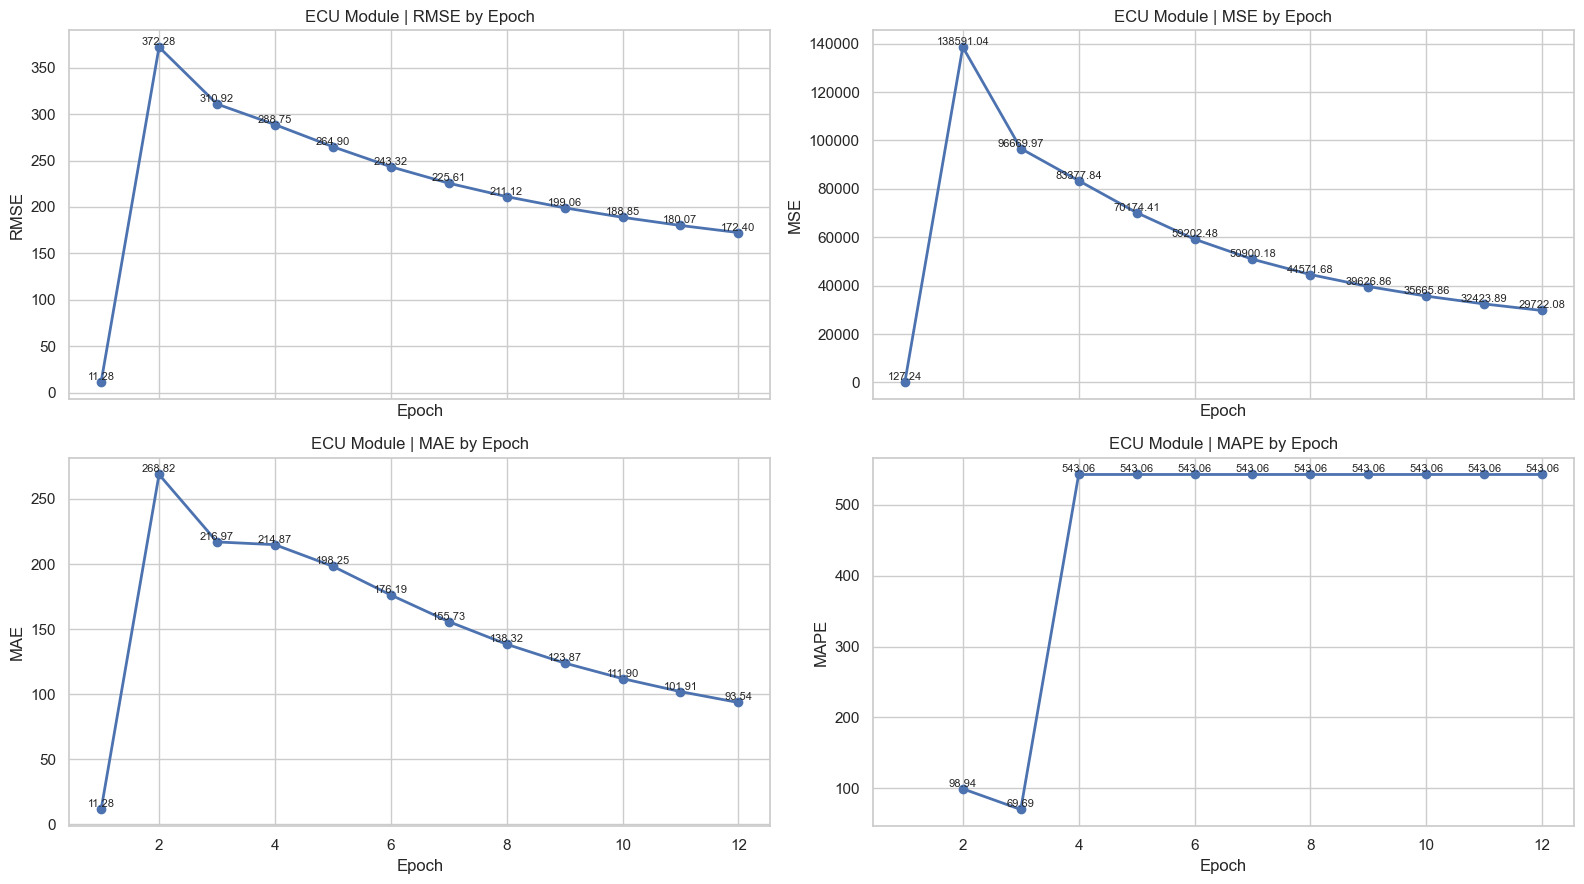

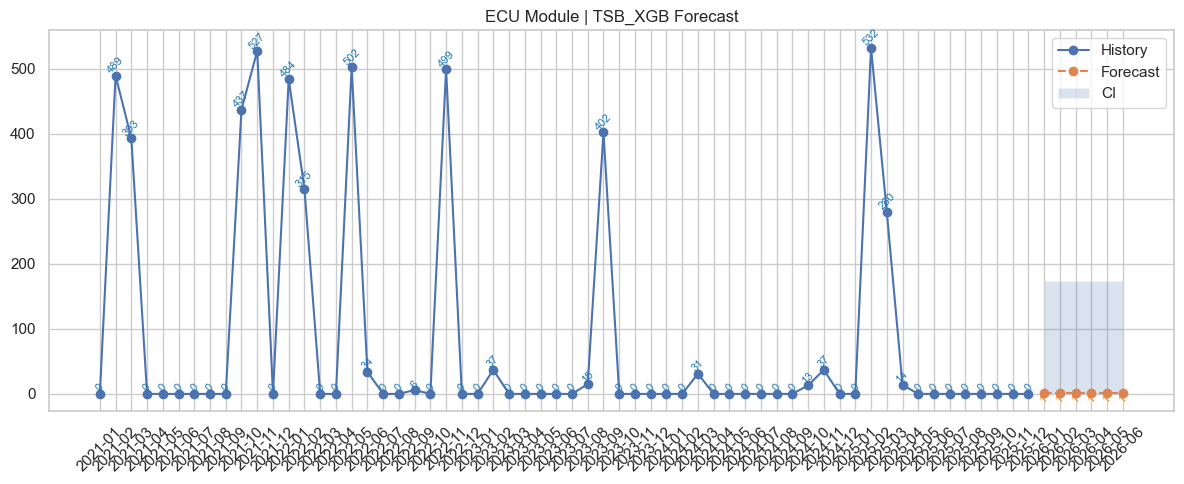

In [25]:
if training_summary_df.empty:
    raise ValueError("No products were trained. Check the dataset and minimum history settings.")

series_to_plot = training_summary_df["product_name"].drop_duplicates().tolist()

for product_name in series_to_plot:
    summary_row = training_summary_df.loc[training_summary_df["product_name"] == product_name].iloc[0]
    algorithm = summary_row["algorithm"]
    series_kind = summary_row.get("series_kind", "product")

    if series_kind == "business_revenue":
        product_history = business_revenue_series.sort_values("period").reset_index(drop=True)
    else:
        product_history = monthly_sales[monthly_sales[PRODUCT_COLUMN] == product_name].sort_values("period").reset_index(drop=True)

    plot_training(
        product_name=product_name,
        model_name=algorithm,
        product_history=product_history,
        epoch_frame=epoch_results[product_name],
        forecast_rows=forecast_results[product_name].to_dict(orient="records"),
    )


## Saved Pickle Artifacts

The generated pickle files are saved per product under:

- `python/trained_models/arima_xgb/`
- `python/trained_models/tsb_xgb/`

These artifacts can be reused by the existing artifact-based sales forecasting flow.